# ITT Avenida Ciudad de Cali - 5 dimensiones parciales

**Zona:** Corredor Avenida Ciudad de Cali  
**Cobertura espacial:** 8 tramos (`T1` a `T8`)  
**Periodo:** 2023 a 2026-Q1  

## Alcance de esta version

- Implementa las dimensiones con data disponible hoy por tramo:
  - Seguridad
  - Movilidad y Accesibilidad
  - Desarrollo Social (`VIF`, `Rinas`, `SPA`)
  - Entorno Urbano
  - Actividad Economica
- `Educacion` queda pendiente por falta de archivos por tramo en `data/itt_avenida_ciudad_de_cali/6_Educacion`.
- El `ITT` que sale en este notebook es **provisional**, usando las dimensiones disponibles y renormalizando pesos cuando falte una dimension en un tramo/anio.


In [1]:
import os
import re
import json
import unicodedata
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import rasterio

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette(['#0072B2', '#E69F00', '#009E73', '#D55E00', '#56B4E9', '#333333'])
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 220)

BG = '#F4F6F9'
OKI_AZUL = '#0072B2'
OKI_AZUL_C = '#56B4E9'
OKI_VERDE = '#009E73'
OKI_NARANJA = '#E69F00'
OKI_BERMELL = '#D55E00'
OKI_GRIS = '#333333'

CMAP_CALIDO = 'flare'
CMAP_FRIO = 'crest'
CMAP_NEUTRO = 'cividis'
CMAP_INTENSO = 'mako'

TRAMOS = [f'T{i}' for i in range(1, 9)]
ANIOS = [2023, 2024, 2025, 2026]
ANO_CORTE = 2026
TRIM_CIERRE = 1
PERIODOS_TRIM = [f'{a}-Q{t}' for a in [2023, 2024, 2025] for t in [1,2,3,4]] + ['2026-Q1']

PESOS = {
    'Seguridad': 0.27,
    'Movilidad': 0.22,
    'DesSocial': 0.19,
    'EntornoU':  0.17,
    'DesEco':    0.15,
}

if 'google.colab' in str(type(get_ipython())):
    REPO = Path('/content/itt_repos_cali')
else:
    REPO = Path.cwd()

DATA_DIR = REPO / 'data' / 'itt_avenida_ciudad_de_cali'
OUTPUT_DIR = REPO / 'outputs' / 'itt_avenida_ciudad_de_cali_5dim'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
SOC_DIR = next(DATA_DIR.glob('2_Dim*'))

print('REPO     :', REPO)
print('DATA_DIR :', DATA_DIR)
print('OUTPUT   :', OUTPUT_DIR)
print('TRAMOS   :', TRAMOS)
print('PERIODO  : 2023-2026 Q1')


REPO     : /content/itt_repos_cali
DATA_DIR : /content/itt_repos_cali/data/itt_avenida_ciudad_de_cali
OUTPUT   : /content/itt_repos_cali/outputs/itt_avenida_ciudad_de_cali_5dim
TRAMOS   : ['T1', 'T2', 'T3', 'T4', 'T5', 'T6', 'T7', 'T8']
PERIODO  : 2023-2026 Q1


In [2]:
def tramo_file_map(folder, stem_prefix, suffix='geojson'):
    out = {}
    for tramo in TRAMOS:
        path = DATA_DIR / folder / f'{stem_prefix}_{tramo}.{suffix}'
        out[tramo] = path
    return out

PATHS = {
    'seg_hom': tramo_file_map('1_Dimension_Seguridad', 'DATIC_homicidios_2023_2026T1_poligono_ciudad_de_cali'),
    'seg_hur': tramo_file_map('1_Dimension_Seguridad', 'DATIC_hurtos_2023_2026T1_poligono_ciudad_de_cali'),
    'seg_comp': tramo_file_map('1_Dimension_Seguridad', 'DATIC_comparendos_2023_2026T1_poligono_ciudad_de_cali'),
    'soc_vif': {tramo: SOC_DIR / f'DATIC_violencia_intrafamiliar_2023_2026T1_poligono_ciudad_de_cali_{tramo}.geojson' for tramo in TRAMOS},
    'mov_sin': tramo_file_map('3_Dimension_Movilidad', 'BD_SINIESTROS_2023_2026_COMUNA_BARRIO_84_poligono_ciudad_de_cali'),
    'de_rm': tramo_file_map('4_Desarrollo_Economico', 'registro_mercantil_2025_con_coordenadas_poligono_ciudad_de_cali'),
    'eu_arb': tramo_file_map('5_Entorno_Urbano', 'CENSO_ARBOREO_poligono_ciudad_de_cali'),
}

PATHS_NDVI = {
    tramo: {ano: DATA_DIR / '5_Entorno_Urbano' / 'NDVI_CiudadCali' / f'{tramo}_Ciudad_de_cali_ndvi_{ano}.tif'
            for ano in ANIOS}
    for tramo in TRAMOS
}

def path_exists(p):
    return Path(p).exists()

inv_rows = []
for tramo in TRAMOS:
    inv_rows.append({
        'tramo': tramo,
        'seg_hom': path_exists(PATHS['seg_hom'][tramo]),
        'seg_hur': path_exists(PATHS['seg_hur'][tramo]),
        'seg_comp': path_exists(PATHS['seg_comp'][tramo]),
        'soc_vif': path_exists(PATHS['soc_vif'][tramo]),
        'mov_sin': path_exists(PATHS['mov_sin'][tramo]),
        'de_rm': path_exists(PATHS['de_rm'][tramo]),
        'eu_arb': path_exists(PATHS['eu_arb'][tramo]),
        'ndvi_2023': path_exists(PATHS_NDVI[tramo][2023]),
        'ndvi_2024': path_exists(PATHS_NDVI[tramo][2024]),
        'ndvi_2025': path_exists(PATHS_NDVI[tramo][2025]),
        'ndvi_2026': path_exists(PATHS_NDVI[tramo][2026]),
    })

df_inventory = pd.DataFrame(inv_rows)
display(df_inventory)


,tramo,seg_hom,seg_hur,seg_comp,soc_vif,mov_sin,de_rm,eu_arb,ndvi_2023,ndvi_2024,ndvi_2025,ndvi_2026
0,T1,True,True,True,True,True,True,True,True,True,True,True
1,T2,True,True,True,True,True,True,True,True,True,True,True
2,T3,True,True,True,True,True,True,True,True,True,True,True
3,T4,True,True,True,True,True,True,True,True,True,True,True
4,T5,True,True,True,True,True,True,True,True,True,True,True
5,T6,True,True,True,True,True,True,True,True,True,True,True
6,T7,True,True,True,True,True,True,True,True,True,True,True
7,T8,True,True,True,True,False,True,True,True,True,True,True


In [3]:
def load_geojson_props(path):
    path = Path(path)
    if not path.exists():
        return pd.DataFrame()
    with path.open(encoding='utf-8') as f:
        gj = json.load(f)
    rows = [ft.get('properties', {}) for ft in gj.get('features', [])]
    return pd.DataFrame(rows)

def normalize_text(s):
    s = pd.Series(s, copy=False).astype(str)
    try:
        s = s.str.normalize('NFKD').str.encode('ascii', errors='ignore').str.decode('ascii')
    except Exception:
        pass
    return s.str.upper().str.strip()

def parse_dt(series):
    s = pd.Series(series, copy=False).astype(str).str.strip()
    out = pd.to_datetime(s, errors='coerce', dayfirst=True)
    mask = out.isna()
    if mask.any():
        out.loc[mask] = pd.to_datetime(s.loc[mask], errors='coerce', dayfirst=False)
    return out

def keep_period(dt):
    y = dt.dt.year
    q = dt.dt.quarter
    return ((y >= 2023) & (y <= 2025)) | ((y == 2026) & (q <= TRIM_CIERRE))

def add_period_cols(df, dt_col):
    dt = parse_dt(df[dt_col])
    out = df.copy()
    out['_dt'] = dt
    out = out.loc[out['_dt'].notna()].copy()
    out['anio'] = out['_dt'].dt.year.astype(int)
    out['trimestre'] = out['_dt'].dt.quarter.astype(int)
    out = out.loc[keep_period(out['_dt'])].copy()
    out['periodo'] = out['anio'].astype(str) + '-Q' + out['trimestre'].astype(str)
    return out

def complete_trim_panel(df, value_cols, available_tramos=None):
    idx = pd.MultiIndex.from_product([TRAMOS, PERIODOS_TRIM], names=['tramo', 'periodo'])
    base = pd.DataFrame(index=idx).reset_index()
    base[['anio', 'trimestre']] = base['periodo'].str.extract(r'(\d{4})-Q(\d)').astype(int)

    if 'anio' not in df.columns:
        if 'ano' in df.columns:
            df = df.rename(columns={'ano': 'anio'})
        elif 'año' in df.columns:
            df = df.rename(columns={'año': 'anio'})
        else:
            raise KeyError('No encontre columna anio en complete_trim_panel')

    out = base.merge(df, on=['tramo', 'periodo', 'anio', 'trimestre'], how='left')
    for col in value_cols:
        if col not in out.columns:
            out[col] = np.nan
    if available_tramos is not None:
        mask = out['tramo'].isin(list(available_tramos))
        out.loc[mask, value_cols] = out.loc[mask, value_cols].fillna(0)
    return out

def annualize(df_trim, value_cols):
    return (df_trim.groupby(['tramo', 'anio'], dropna=False)[value_cols]
            .sum(min_count=1)
            .reset_index())

def corridor_trim(df_trim, value_cols):
    return (df_trim.groupby(['anio', 'trimestre', 'periodo'], dropna=False)[value_cols]
            .sum(min_count=1)
            .reset_index())

def corridor_annual_sum(df_ann, value_cols):
    return df_ann.groupby('anio', dropna=False)[value_cols].sum(min_count=1).reset_index()

def score_ref(valor, ref_min, ref_max, inverso=False):
    if pd.isna(valor):
        return np.nan
    if ref_max == ref_min:
        return 100.0
    raw = np.clip((valor - ref_min) / (ref_max - ref_min) * 100, 0, 100)
    return 100 - raw if inverso else raw

def score_mean(row, cols):
    vals = [row[c] for c in cols if c in row.index and pd.notna(row[c])]
    return float(np.mean(vals)) if vals else np.nan

def itt_weighted(row, mapping):
    vals = []
    weights = []
    for dim, col in mapping.items():
        if col in row.index and pd.notna(row[col]):
            vals.append(row[col] * PESOS[dim])
            weights.append(PESOS[dim])
    if not weights:
        return np.nan
    return sum(vals) / sum(weights)

def classify_itt(v):
    if pd.isna(v):
        return 'Sin dato'
    if v < 40:
        return 'Emergencia'
    if v < 60:
        return 'Consolidacion'
    if v < 80:
        return 'Avance'
    return 'Transformacion'

def fmt_m(v):
    if pd.isna(v):
        return '-'
    return f'${v/1e6:,.0f}M'

def fmt_compacto(v, mode='int'):
    if pd.isna(v):
        return ''
    if mode == 'float2':
        return f'{float(v):.2f}'
    if mode == 'money':
        v = float(v)
        if abs(v) >= 1e9:
            return f'${v/1e9:.1f}B'
        if abs(v) >= 1e6:
            return f'${v/1e6:.0f}M'
        if abs(v) >= 1e3:
            return f'${v/1e3:.0f}k'
        return f'${v:.0f}'
    return f'{int(round(float(v)))}'

def heatmap_annot_df(pivot, mode='int'):
    return pivot.applymap(lambda v: fmt_compacto(v, mode))

def savefig(name):
    plt.savefig(OUTPUT_DIR / name, dpi=150, bbox_inches='tight', facecolor=BG)


## Construccion de tablas maestras por tramo


In [4]:
def build_count_trim(tramo_paths, date_col, out_col, filter_fn=None):
    rows = []
    for tramo, path in tramo_paths.items():
        df = load_geojson_props(path)
        if df.empty:
            continue
        if filter_fn is not None:
            df = filter_fn(df)
        if df.empty or date_col not in df.columns:
            continue
        df = add_period_cols(df, date_col)
        if df.empty:
            continue

        if 'anio' not in df.columns:
            if 'ano' in df.columns:
                df = df.rename(columns={'ano': 'anio'})
            elif 'año' in df.columns:
                df = df.rename(columns={'año': 'anio'})
            else:
                raise KeyError(f'No encontre columna anio despues de add_period_cols para {tramo}')

        g = (df.groupby(['anio', 'trimestre', 'periodo']).size()
               .reset_index(name=out_col))
        g['tramo'] = tramo
        rows.append(g[['tramo', 'anio', 'trimestre', 'periodo', out_col]])
    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame(columns=['tramo','anio','trimestre','periodo',out_col])

def filter_group_value(df, target):
    if 'agrupado' in df.columns:
        s = normalize_text(df['agrupado'])
        return df.loc[s == target].copy()
    return df.iloc[0:0].copy()

def filter_tipo_conf(df, target):
    if 'Tipo_Confi' in df.columns:
        s = normalize_text(df['Tipo_Confi'])
        return df.loc[s.str.contains(target, na=False)].copy()
    return df.iloc[0:0].copy()

df_hom_trim = build_count_trim(PATHS['seg_hom'], 'fechah', 'homicidios')
df_hur_trim = build_count_trim(PATHS['seg_hur'], 'fecha_hech', 'hurtos')
df_seg_trim = complete_trim_panel(
    df_hom_trim.merge(df_hur_trim, on=['tramo','anio','trimestre','periodo'], how='outer'),
    ['homicidios', 'hurtos'],
    available_tramos=PATHS['seg_hom'].keys()
)

df_vif_trim = build_count_trim(PATHS['soc_vif'], 'fecha_hech', 'vif')
df_rinas_trim = build_count_trim(PATHS['seg_comp'], 'fecha_hech', 'rinas',
                                 filter_fn=lambda d: filter_group_value(d, 'RINAS'))
df_spa_trim = build_count_trim(PATHS['seg_comp'], 'fecha_hech', 'spa',
                               filter_fn=lambda d: filter_group_value(d, 'SUSTANCIAS PSICOACTIVAS'))

df_social_trim = complete_trim_panel(
    df_vif_trim.merge(df_rinas_trim, on=['tramo','anio','trimestre','periodo'], how='outer')
               .merge(df_spa_trim, on=['tramo','anio','trimestre','periodo'], how='outer'),
    ['vif', 'rinas', 'spa'],
    available_tramos=PATHS['soc_vif'].keys()
)

df_sin_trim = build_count_trim(PATHS['mov_sin'], 'Fecha', 'siniestralidad')
df_les_trim = build_count_trim(PATHS['mov_sin'], 'Fecha', 'lesionados',
                               filter_fn=lambda d: filter_tipo_conf(d, 'LESION'))
df_mor_trim = build_count_trim(PATHS['mov_sin'], 'Fecha', 'mortales',
                               filter_fn=lambda d: filter_tipo_conf(d, 'MORTAL'))

df_mov_trim = complete_trim_panel(
    df_sin_trim.merge(df_les_trim, on=['tramo','anio','trimestre','periodo'], how='outer')
               .merge(df_mor_trim, on=['tramo','anio','trimestre','periodo'], how='outer'),
    ['siniestralidad', 'lesionados', 'mortales'],
    available_tramos=PATHS['mov_sin'].keys()
)

display(df_seg_trim.head())
display(df_social_trim.head())
display(df_mov_trim.head())


/tmp/ipykernel_33488/1596642247.py:20: UserWarning: Parsing dates in %m/%d/%Y format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  out = pd.to_datetime(s, errors='coerce', dayfirst=True)
/tmp/ipykernel_33488/1596642247.py:20: UserWarning: Parsing dates in %m/%d/%Y format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  out = pd.to_datetime(s, errors='coerce', dayfirst=True)
/tmp/ipykernel_33488/1596642247.py:20: UserWarning: Parsing dates in %Y-%m-%d %H:%M:%S format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  out = pd.to_datetime(s, errors='coerce', dayfirst=True)
/tmp/ipykernel_33488/1596642247.py:20: UserWarning: Parsing dates in %Y-%m-%d %H:%M:%S format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  out = pd.to_datetime(s, errors='coerce', dayfirst=True)
/tmp/i

,tramo,periodo,anio,trimestre,homicidios,hurtos
0,T1,2023-Q1,2023,1,0.0,20.0
1,T1,2023-Q2,2023,2,0.0,25.0
2,T1,2023-Q3,2023,3,1.0,22.0
3,T1,2023-Q4,2023,4,0.0,15.0
4,T1,2024-Q1,2024,1,0.0,12.0


,tramo,periodo,anio,trimestre,vif,rinas,spa
0,T1,2023-Q1,2023,1,2.0,2.0,14.0
1,T1,2023-Q2,2023,2,7.0,3.0,6.0
2,T1,2023-Q3,2023,3,3.0,2.0,2.0
3,T1,2023-Q4,2023,4,3.0,0.0,0.0
4,T1,2024-Q1,2024,1,6.0,0.0,2.0


,tramo,periodo,anio,trimestre,siniestralidad,lesionados,mortales
0,T1,2023-Q1,2023,1,5.0,2.0,1.0
1,T1,2023-Q2,2023,2,7.0,5.0,0.0
2,T1,2023-Q3,2023,3,6.0,6.0,0.0
3,T1,2023-Q4,2023,4,5.0,5.0,0.0
4,T1,2024-Q1,2024,1,2.0,1.0,0.0


In [5]:
def parse_fecha_es(txt):
    if pd.isna(txt):
        return pd.NaT
    s = str(txt).strip().lower()
    s = unicodedata.normalize('NFKD', s).encode('ascii', 'ignore').decode('ascii')
    m = re.search(r'(\d{1,2}) de ([a-z]+) de (\d{4})', s)
    if not m:
        return pd.NaT
    meses = {
        'enero':1,'febrero':2,'marzo':3,'abril':4,'mayo':5,'junio':6,
        'julio':7,'agosto':8,'septiembre':9,'setiembre':9,
        'octubre':10,'noviembre':11,'diciembre':12
    }
    mes_txt = m.group(2)
    mes = meses.get(mes_txt)
    if not mes:
        return pd.NaT
    return pd.Timestamp(year=int(m.group(3)), month=mes, day=int(m.group(1)))

rows_de_flow = []
rows_de_stock = []

for tramo, path in PATHS['de_rm'].items():
    df = load_geojson_props(path)
    if df.empty:
        continue
    df['fecha_mat'] = df['Mes_Dia_An'].apply(parse_fecha_es) if 'Mes_Dia_An' in df.columns else pd.NaT
    df['anio_mat'] = df['fecha_mat'].dt.year
    df['trim_mat'] = df['fecha_mat'].dt.quarter
    df['personal_limpio'] = pd.to_numeric(df.get('PERSONAL_O'), errors='coerce').fillna(0)
    df.loc[df['personal_limpio'] < 0, 'personal_limpio'] = 0
    df['ingresos_limpio'] = pd.to_numeric(df.get('INGRESOS_A'), errors='coerce')
    df.loc[df['ingresos_limpio'] <= 0, 'ingresos_limpio'] = np.nan

    for ano in [2023, 2024, 2025]:
        for trim in [1, 2, 3, 4]:
            sub = df[(df['anio_mat'] == ano) & (df['trim_mat'] == trim)].copy()
            rows_de_flow.append({
                'tramo': tramo,
                'anio': ano,
                'trimestre': trim,
                'periodo': f'{ano}-Q{trim}',
                'negocios_nuevos': float(len(sub)),
                'personal_nuevos': float(sub['personal_limpio'].sum(skipna=True)),
                'ingresos_nuevos': float(sub['ingresos_limpio'].sum(skipna=True)),
            })

    for ano in ANIOS:
        if ano <= 2025:
            sub_stock = df[df['anio_mat'] <= ano].copy()
            tipo = 'Real' if ano == 2025 else 'Proxy retrospectivo'
        else:
            sub_stock = df[df['anio_mat'] <= 2025].copy()
            tipo = 'Proxy referencial = 2025'

        est = float(len(sub_stock))
        pers = float(sub_stock['personal_limpio'].sum(skipna=True)) if len(sub_stock) else np.nan
        ing = float(sub_stock['ingresos_limpio'].sum(skipna=True)) if len(sub_stock) else np.nan
        n_ing = int(sub_stock['ingresos_limpio'].notna().sum()) if len(sub_stock) else 0

        rows_de_stock.append({
            'tramo': tramo,
            'anio': ano,
            'tipo_dato': tipo,
            'establecimientos_activos': est,
            'empleabilidad_total': pers,
            'ingresos_operacionales': ing,
            'negocios_con_ingreso': n_ing,
            'ingresos_log1p': float(np.log1p(ing)) if pd.notna(ing) and ing > 0 else 0.0,
        })

df_de_flow_trim = complete_trim_panel(
    pd.DataFrame(rows_de_flow),
    ['negocios_nuevos', 'personal_nuevos', 'ingresos_nuevos'],
    available_tramos=PATHS['de_rm'].keys()
)
df_de_stock_ann = pd.DataFrame(rows_de_stock)

rows_entorno = []
for tramo in TRAMOS:
    arb = load_geojson_props(PATHS['eu_arb'][tramo])
    arbolado_total = float(len(arb)) if not arb.empty else np.nan
    for ano in ANIOS:
        ndvi_path = PATHS_NDVI[tramo][ano]
        ndvi_mean = np.nan
        if ndvi_path.exists():
            with rasterio.open(ndvi_path) as src:
                arr = src.read(1).astype('float64')
                if src.nodata is not None:
                    arr[arr == src.nodata] = np.nan
                arr[arr <= -9999] = np.nan
                ndvi_mean = float(np.nanmean(arr))
        rows_entorno.append({
            'tramo': tramo,
            'anio': ano,
            'ndvi': ndvi_mean,
            'arbolado_total': arbolado_total,
            'tipo_arbolado': 'Inventario disponible / proxy estructural',
        })

df_entorno_ann = pd.DataFrame(rows_entorno)

display(df_de_flow_trim.head())
display(df_de_stock_ann.head())
display(df_entorno_ann.head())


,tramo,periodo,anio,trimestre,negocios_nuevos,personal_nuevos,ingresos_nuevos
0,T1,2023-Q1,2023,1,3.0,5.0,0.0
1,T1,2023-Q2,2023,2,4.0,0.0,0.0
2,T1,2023-Q3,2023,3,1.0,0.0,500000.0
3,T1,2023-Q4,2023,4,0.0,0.0,0.0
4,T1,2024-Q1,2024,1,5.0,3.0,14321170.0


,tramo,anio,tipo_dato,establecimientos_activos,empleabilidad_total,ingresos_operacionales,negocios_con_ingreso,ingresos_log1p
0,T1,2023,Proxy retrospectivo,40.0,55.0,2.889532e+09,8,21.784360
1,T1,2024,Proxy retrospectivo,59.0,67.0,2.903853e+09,9,21.789304
2,T1,2025,Real,79.0,74.0,2.964273e+09,11,21.809898
3,T1,2026,Proxy referencial = 2025,79.0,74.0,2.964273e+09,11,21.809898
4,T2,2023,Proxy retrospectivo,205.0,344.0,2.229239e+10,66,23.827511


,tramo,anio,ndvi,arbolado_total,tipo_arbolado
0,T1,2023,0.202401,2325.0,Inventario disponible / proxy estructural
1,T1,2024,0.207596,2325.0,Inventario disponible / proxy estructural
2,T1,2025,0.197621,2325.0,Inventario disponible / proxy estructural
3,T1,2026,0.211647,2325.0,Inventario disponible / proxy estructural
4,T2,2023,0.192815,3485.0,Inventario disponible / proxy estructural


## Bases anuales, scores e ITT provisional por tramo


In [6]:
df_seg_ann = annualize(df_seg_trim, ['homicidios', 'hurtos'])
df_social_ann = annualize(df_social_trim, ['vif', 'rinas', 'spa'])
df_mov_ann = annualize(df_mov_trim, ['siniestralidad', 'lesionados', 'mortales'])

base_tramos = (
    pd.DataFrame([(t, a) for t in TRAMOS for a in ANIOS], columns=['tramo', 'anio'])
      .merge(df_seg_ann, on=['tramo', 'anio'], how='left')
      .merge(df_mov_ann, on=['tramo', 'anio'], how='left')
      .merge(df_social_ann, on=['tramo', 'anio'], how='left')
      .merge(df_entorno_ann, on=['tramo', 'anio'], how='left')
      .merge(df_de_stock_ann, on=['tramo', 'anio'], how='left')
)

refs = {
    'homicidios':      (0, max(1.0, base_tramos['homicidios'].max(skipna=True)), True),
    'hurtos':          (0, max(1.0, base_tramos['hurtos'].max(skipna=True)), True),
    'siniestralidad':  (0, max(1.0, base_tramos['siniestralidad'].max(skipna=True)), True),
    'lesionados':      (0, max(1.0, base_tramos['lesionados'].max(skipna=True)), True),
    'mortales':        (0, max(1.0, base_tramos['mortales'].max(skipna=True)), True),
    'vif':             (0, max(1.0, base_tramos['vif'].max(skipna=True)), True),
    'rinas':           (0, max(1.0, base_tramos['rinas'].max(skipna=True)), True),
    'spa':             (0, max(1.0, base_tramos['spa'].max(skipna=True)), True),
    'ndvi':            (float(base_tramos['ndvi'].min(skipna=True)), float(base_tramos['ndvi'].max(skipna=True)), False),
    'arbolado_total':  (0, max(1.0, base_tramos['arbolado_total'].max(skipna=True)), False),
    'establecimientos_activos': (0, max(1.0, base_tramos['establecimientos_activos'].max(skipna=True)), False),
    'empleabilidad_total':      (0, max(1.0, base_tramos['empleabilidad_total'].max(skipna=True)), False),
    'ingresos_log1p':           (0, max(1.0, base_tramos['ingresos_log1p'].max(skipna=True)), False),
}

for ind, (rmin, rmax, inv) in refs.items():
    base_tramos[f'score_{ind}'] = base_tramos[ind].apply(lambda v: score_ref(v, rmin, rmax, inv))

base_tramos['score_seguridad'] = base_tramos.apply(lambda r: score_mean(r, ['score_homicidios', 'score_hurtos']), axis=1)
base_tramos['score_movilidad'] = base_tramos.apply(lambda r: score_mean(r, ['score_siniestralidad', 'score_lesionados', 'score_mortales']), axis=1)
base_tramos['score_des_social'] = base_tramos.apply(lambda r: score_mean(r, ['score_vif', 'score_rinas', 'score_spa']), axis=1)
base_tramos['score_entorno_u'] = base_tramos.apply(lambda r: score_mean(r, ['score_ndvi', 'score_arbolado_total']), axis=1)
base_tramos['score_des_eco'] = base_tramos.apply(lambda r: score_mean(r, ['score_establecimientos_activos', 'score_empleabilidad_total', 'score_ingresos_log1p']), axis=1)

base_tramos['ITT'] = base_tramos.apply(
    lambda r: itt_weighted(r, {
        'Seguridad': 'score_seguridad',
        'Movilidad': 'score_movilidad',
        'DesSocial': 'score_des_social',
        'EntornoU': 'score_entorno_u',
        'DesEco': 'score_des_eco',
    }),
    axis=1
)
base_tramos['nivel'] = base_tramos['ITT'].apply(classify_itt)
base_tramos['nota'] = np.where(
    base_tramos['anio'] == 2026,
    'T1 parcial; Educacion pendiente; renormaliza dimensiones disponibles',
    'Educacion pendiente; ITT provisional por tramo'
)

display(base_tramos[['tramo','anio','score_seguridad','score_movilidad','score_des_social','score_entorno_u','score_des_eco','ITT','nivel','nota']].head(20))


,tramo,anio,score_seguridad,score_movilidad,score_des_social,score_entorno_u,score_des_eco,ITT,nivel,nota
0,T1,2023,81.648841,74.122513,90.536256,28.528126,31.035373,65.059116,Avance,Educacion pendiente; ITT provisional por tramo
1,T1,2024,89.215686,81.052985,90.590949,29.291615,32.027209,68.915828,Avance,Educacion pendiente; ITT provisional por tramo
2,T1,2025,85.846702,84.987704,85.096424,27.825664,32.926135,67.713508,Avance,Educacion pendiente; ITT provisional por tramo
3,T1,2026,95.962567,99.001416,95.520531,29.887081,32.926135,75.858829,Avance,T1 parcial; Educacion pendiente; renormaliza d...
4,T2,2023,72.513369,72.218496,85.150793,36.872022,47.640548,65.059656,Avance,Educacion pendiente; ITT provisional por tramo
5,T2,2024,74.750446,54.493628,83.834557,39.712056,49.566187,62.285762,Avance,Educacion pendiente; ITT provisional por tramo
6,T2,2025,82.433155,78.560250,77.691825,39.456024,51.453898,68.727262,Avance,Educacion pendiente; ITT provisional por tramo
7,T2,2026,88.948307,99.001416,93.193401,39.669788,51.453898,77.965049,Avance,T1 parcial; Educacion pendiente; renormaliza d...
8,T3,2023,36.131907,27.777778,50.877997,33.977615,76.949592,42.852179,Consolidacion,Educacion pendiente; ITT provisional por tramo
9,T3,2024,38.565062,5.581638,55.904182,34.615784,79.750743,40.109617,Consolidacion,Educacion pendiente; ITT provisional por tramo


In [7]:
base_corr = (
    corridor_annual_sum(df_seg_ann, ['homicidios', 'hurtos'])
      .merge(corridor_annual_sum(df_mov_ann, ['siniestralidad', 'lesionados', 'mortales']), on='anio', how='outer')
      .merge(corridor_annual_sum(df_social_ann, ['vif', 'rinas', 'spa']), on='anio', how='outer')
      .merge(df_entorno_ann.groupby('anio', dropna=False).agg({'ndvi':'mean','arbolado_total':'sum'}).reset_index(), on='anio', how='outer')
      .merge(df_de_stock_ann.groupby('anio', dropna=False).agg({
          'establecimientos_activos':'sum',
          'empleabilidad_total':'sum',
          'ingresos_operacionales':'sum',
          'ingresos_log1p':'sum',
      }).reset_index(), on='anio', how='outer')
)

for ind, (rmin, rmax, inv) in refs.items():
    if ind in base_corr.columns:
        base_corr[f'score_{ind}'] = base_corr[ind].apply(lambda v: score_ref(v, rmin, rmax, inv))

base_corr['score_seguridad'] = base_corr.apply(lambda r: score_mean(r, ['score_homicidios', 'score_hurtos']), axis=1)
base_corr['score_movilidad'] = base_corr.apply(lambda r: score_mean(r, ['score_siniestralidad', 'score_lesionados', 'score_mortales']), axis=1)
base_corr['score_des_social'] = base_corr.apply(lambda r: score_mean(r, ['score_vif', 'score_rinas', 'score_spa']), axis=1)
base_corr['score_entorno_u'] = base_corr.apply(lambda r: score_mean(r, ['score_ndvi', 'score_arbolado_total']), axis=1)
base_corr['score_des_eco'] = base_corr.apply(lambda r: score_mean(r, ['score_establecimientos_activos', 'score_empleabilidad_total', 'score_ingresos_log1p']), axis=1)
base_corr['ITT'] = base_corr.apply(
    lambda r: itt_weighted(r, {
        'Seguridad': 'score_seguridad',
        'Movilidad': 'score_movilidad',
        'DesSocial': 'score_des_social',
        'EntornoU': 'score_entorno_u',
        'DesEco': 'score_des_eco',
    }),
    axis=1
)
base_corr['nivel'] = base_corr['ITT'].apply(classify_itt)
display(base_corr)


,anio,homicidios,hurtos,siniestralidad,lesionados,mortales,vif,rinas,spa,ndvi,arbolado_total,establecimientos_activos,empleabilidad_total,ingresos_operacionales,ingresos_log1p,score_homicidios,score_hurtos,score_siniestralidad,score_lesionados,score_mortales,score_vif,score_rinas,score_spa,score_ndvi,score_arbolado_total,score_establecimientos_activos,score_empleabilidad_total,score_ingresos_log1p,score_seguridad,score_movilidad,score_des_social,score_entorno_u,score_des_eco,ITT,nivel
0,2023,61.0,1246.0,294.0,250.0,5.0,263.0,203.0,938.0,0.223886,23349.0,1859.0,3495.0,3.573863e+11,190.286140,0.000000,0.000000,0.000000,0.000000,16.666667,0.000000,0.000000,0.00000,24.276120,100.0,100.0,100.0,100.0,0.000000,5.555556,0.000000,62.138060,100.0,26.785692,Emergencia
1,2024,47.0,1123.0,242.0,215.0,14.0,287.0,303.0,828.0,0.229893,23349.0,2326.0,3792.0,3.877231e+11,190.919113,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,26.041904,100.0,100.0,100.0,100.0,0.000000,0.000000,0.000000,63.020952,100.0,25.713562,Emergencia
2,2025,58.0,1111.0,247.0,215.0,16.0,302.0,422.0,1237.0,0.239211,23349.0,2810.0,4080.0,4.002533e+11,191.067928,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,28.780846,100.0,100.0,100.0,100.0,0.000000,0.000000,0.000000,64.390423,100.0,25.946372,Emergencia
3,2026,15.0,155.0,31.0,26.0,2.0,62.0,70.0,127.0,0.230900,23349.0,2810.0,4080.0,4.002533e+11,191.067928,31.818182,39.215686,56.338028,58.730159,66.666667,19.480519,55.974843,73.97541,26.338037,100.0,100.0,100.0,100.0,35.516934,60.578285,49.810257,63.169019,100.0,58.119477,Consolidacion


In [8]:
def plot_general_trim(df_trim, metrics, title, output_name):
    df = corridor_trim(df_trim, [m[0] for m in metrics]).copy()
    x = np.arange(len(df))
    fig, axes = plt.subplots(1, len(metrics), figsize=(6 * len(metrics), 4.8), facecolor=BG)
    if len(metrics) == 1:
        axes = [axes]
    fig.suptitle(title, fontsize=13, fontweight='bold', color='#1B2631')
    for ax, (col, label, color) in zip(axes, metrics):
        vals = df[col].to_numpy(dtype=float)
        ax.fill_between(x, vals, alpha=0.20, color=color)
        ax.plot(x, vals, color=color, linewidth=2.4, marker='o', markersize=4)
        for i, v in enumerate(vals):
            if pd.notna(v):
                ax.annotate(f'{int(v)}', (i, v), textcoords='offset points', xytext=(0, 6),
                            ha='center', fontsize=8, fontweight='bold', color=color)
        ax.set_xticks(x)
        ax.set_xticklabels(df['periodo'], rotation=45, ha='right', fontsize=8)
        ax.set_title(label, fontweight='bold', pad=8)
        ax.set_facecolor(BG)
        ax.grid(axis='y', linestyle='--', alpha=0.25)
    plt.tight_layout(rect=[0, 0.04, 1, 0.92])
    savefig(output_name)
    plt.show()

def plot_heatmaps_tramo_period(df_trim, metric_defs, title, output_name):
    fig, axes = plt.subplots(1, len(metric_defs), figsize=(6 * len(metric_defs), 5.4), facecolor=BG)
    if len(metric_defs) == 1:
        axes = [axes]
    fig.suptitle(title, fontsize=13, fontweight='bold', color='#1B2631')
    for ax, (col, label, cmap, mode) in zip(axes, metric_defs):
        pivot = (df_trim.pivot(index='tramo', columns='periodo', values=col)
                       .reindex(index=TRAMOS, columns=PERIODOS_TRIM))
        annot = heatmap_annot_df(pivot, mode)
        sns.heatmap(pivot, annot=annot, fmt='', cmap=cmap, linewidths=0.5, linecolor='#DEE2E6',
                    ax=ax, cbar_kws={'shrink':0.8}, annot_kws={'size':8})
        ax.set_title(label, fontweight='bold', pad=8)
        ax.set_ylabel('Tramo')
        ax.set_xlabel('Periodo')
    plt.tight_layout(rect=[0, 0.04, 1, 0.92])
    savefig(output_name)
    plt.show()

def plot_per_tramo_trim(df_trim, tramo, metric_defs, title_prefix, output_name):
    sub = (df_trim[df_trim['tramo'] == tramo]
             .set_index('periodo')
             .reindex(PERIODOS_TRIM)
             .reset_index())
    x = np.arange(len(sub))
    fig, axes = plt.subplots(1, len(metric_defs), figsize=(6 * len(metric_defs), 4.5), facecolor=BG)
    if len(metric_defs) == 1:
        axes = [axes]
    fig.suptitle(f'{title_prefix} | {tramo}', fontsize=12.5, fontweight='bold', color='#1B2631')
    for ax, (col, label, color) in zip(axes, metric_defs):
        vals = sub[col].to_numpy(dtype=float)
        ax.fill_between(x, vals, alpha=0.20, color=color)
        ax.plot(x, vals, color=color, linewidth=2.2, marker='o', markersize=4)
        for i, v in enumerate(vals):
            if pd.notna(v):
                ax.annotate(f'{int(v)}', (i, v), textcoords='offset points', xytext=(0, 6),
                            ha='center', fontsize=8, fontweight='bold', color=color)
        ax.set_xticks(x)
        ax.set_xticklabels(sub['periodo'], rotation=45, ha='right', fontsize=8)
        ax.set_title(label, fontweight='bold', pad=8)
        ax.set_facecolor(BG)
        ax.grid(axis='y', linestyle='--', alpha=0.25)
    plt.tight_layout(rect=[0, 0.04, 1, 0.92])
    savefig(output_name)
    plt.show()

def plot_per_tramo_trim_heatmap(df_trim, tramo, rows_cfg, title, output_name):
    sub = (df_trim[df_trim['tramo'] == tramo]
             .set_index('periodo')
             .reindex(PERIODOS_TRIM)
             .reset_index())
    heat = pd.DataFrame({'periodo': PERIODOS_TRIM}).set_index('periodo')
    modes = {}
    for item in rows_cfg:
        if len(item) == 3:
            col, label, mode = item
        else:
            col, label = item
            mode = 'int'
        heat[label] = sub[col].to_numpy(dtype=float)
        modes[label] = mode
    heat = heat.T
    annot = heat.copy()
    for label in heat.index:
        annot.loc[label] = heat.loc[label].apply(lambda v: fmt_compacto(v, modes.get(label, 'int')))
    fig, ax = plt.subplots(figsize=(12, 2.8 + 0.35 * len(rows_cfg)), facecolor=BG)
    sns.heatmap(heat, annot=annot, fmt='', cmap=CMAP_FRIO, linewidths=0.5, linecolor='#DEE2E6',
                ax=ax, cbar_kws={'shrink':0.8}, annot_kws={'size':8})
    ax.set_title(f'{title} | {tramo}', fontweight='bold', pad=8)
    ax.set_ylabel('Indicador')
    ax.set_xlabel('Periodo')
    plt.tight_layout()
    savefig(output_name)
    plt.show()

def plot_general_annual(df_ann, metrics, title, output_name):
    df = df_ann.copy().sort_values('anio')
    x = np.arange(len(df))
    fig, axes = plt.subplots(1, len(metrics), figsize=(6 * len(metrics), 4.6), facecolor=BG)
    if len(metrics) == 1:
        axes = [axes]
    fig.suptitle(title, fontsize=13, fontweight='bold', color='#1B2631')
    for ax, (col, label, color, divisor) in zip(axes, metrics):
        vals = df[col].to_numpy(dtype=float)
        show = vals / divisor if divisor else vals
        ax.bar(x, np.nan_to_num(show, nan=0.0), color=color, alpha=0.82, edgecolor='white', width=0.58)
        ax.plot(x, show, color=color, linewidth=2.0, marker='o', markersize=4)
        for i, v in enumerate(show):
            if pd.notna(v):
                txt = f'{v:,.2f}' if divisor is None and not float(v).is_integer() else (f'{int(v)}' if divisor is None else f'${v:,.0f}M')
                ax.annotate(txt, (i, v), textcoords='offset points', xytext=(0, 6),
                            ha='center', fontsize=8, fontweight='bold', color=color)
        ax.set_xticks(x)
        ax.set_xticklabels(df['anio'], fontsize=9, fontweight='bold')
        ax.set_title(label, fontweight='bold', pad=8)
        ax.set_facecolor(BG)
        ax.grid(axis='y', linestyle='--', alpha=0.25)
    plt.tight_layout(rect=[0, 0.04, 1, 0.92])
    savefig(output_name)
    plt.show()

def plot_heatmaps_tramo_year(df_ann, metric_defs, title, output_name):
    fig, axes = plt.subplots(1, len(metric_defs), figsize=(6 * len(metric_defs), 5.1), facecolor=BG)
    if len(metric_defs) == 1:
        axes = [axes]
    fig.suptitle(title, fontsize=13, fontweight='bold', color='#1B2631')
    for ax, (col, label, cmap, mode) in zip(axes, metric_defs):
        pivot = (df_ann.pivot(index='tramo', columns='anio', values=col)
                    .reindex(index=TRAMOS, columns=ANIOS))
        annot = heatmap_annot_df(pivot, mode)
        sns.heatmap(pivot, annot=annot, fmt='', cmap=cmap,
                    linewidths=0.5, linecolor='#DEE2E6', ax=ax, cbar_kws={'shrink':0.8},
                    annot_kws={'size':8})
        ax.set_title(label, fontweight='bold', pad=8)
        ax.set_ylabel('Tramo')
        ax.set_xlabel('Anio')
    plt.tight_layout(rect=[0, 0.04, 1, 0.92])
    savefig(output_name)
    plt.show()

def plot_per_tramo_annual(df_ann, tramo, metric_defs, title_prefix, output_name):
    sub = (df_ann[df_ann['tramo'] == tramo]
             .set_index('anio')
             .reindex(ANIOS)
             .reset_index())
    x = np.arange(len(sub))
    fig, axes = plt.subplots(1, len(metric_defs), figsize=(6 * len(metric_defs), 4.5), facecolor=BG)
    if len(metric_defs) == 1:
        axes = [axes]
    fig.suptitle(f'{title_prefix} | {tramo}', fontsize=12.5, fontweight='bold', color='#1B2631')
    for ax, (col, label, color, divisor) in zip(axes, metric_defs):
        vals = sub[col].to_numpy(dtype=float)
        show = vals / divisor if divisor else vals
        ax.bar(x, np.nan_to_num(show, nan=0.0), color=color, alpha=0.82, edgecolor='white', width=0.58)
        ax.plot(x, show, color=color, linewidth=2.0, marker='o', markersize=4)
        for i, v in enumerate(show):
            if pd.notna(v):
                txt = f'{v:,.2f}' if divisor is None and not float(v).is_integer() else (f'{int(v)}' if divisor is None else f'${v:,.0f}M')
                ax.annotate(txt, (i, v), textcoords='offset points', xytext=(0, 6),
                            ha='center', fontsize=8, fontweight='bold', color=color)
        ax.set_xticks(x)
        ax.set_xticklabels(sub['anio'], fontsize=9, fontweight='bold')
        ax.set_title(label, fontweight='bold', pad=8)
        ax.set_facecolor(BG)
        ax.grid(axis='y', linestyle='--', alpha=0.25)
    plt.tight_layout(rect=[0, 0.04, 1, 0.92])
    savefig(output_name)
    plt.show()


## Seguridad


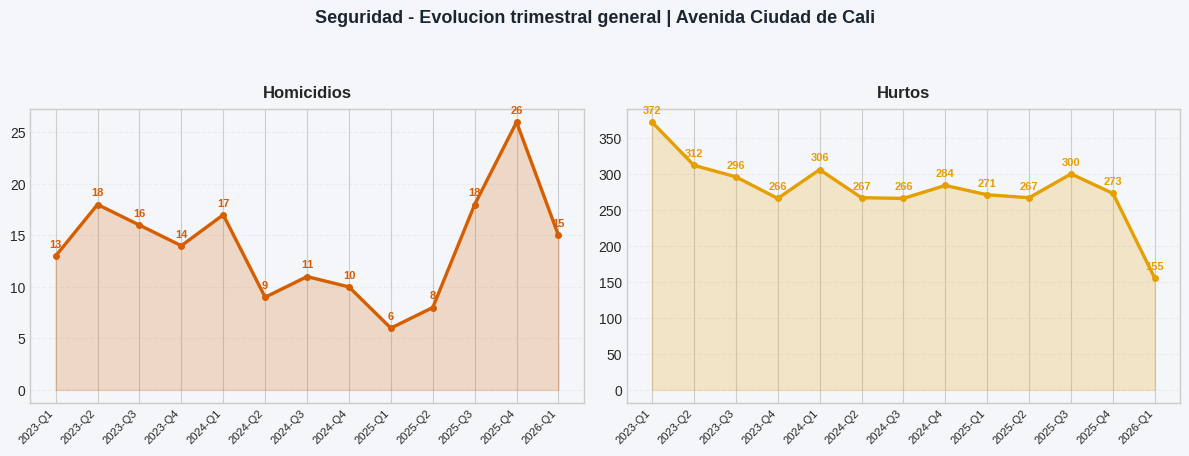

/tmp/ipykernel_33488/1596642247.py:133: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return pivot.applymap(lambda v: fmt_compacto(v, mode))
/tmp/ipykernel_33488/1596642247.py:133: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return pivot.applymap(lambda v: fmt_compacto(v, mode))


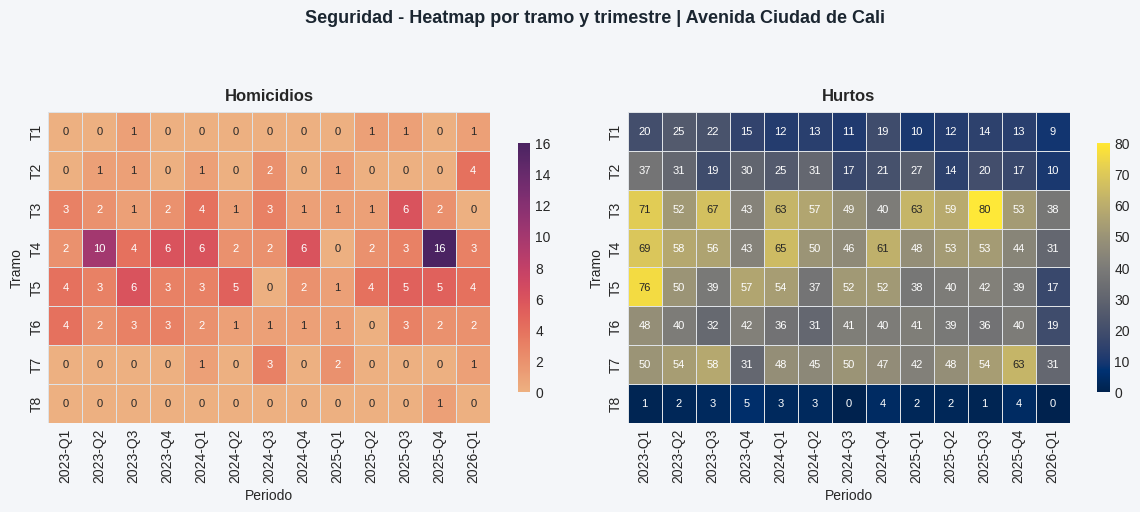

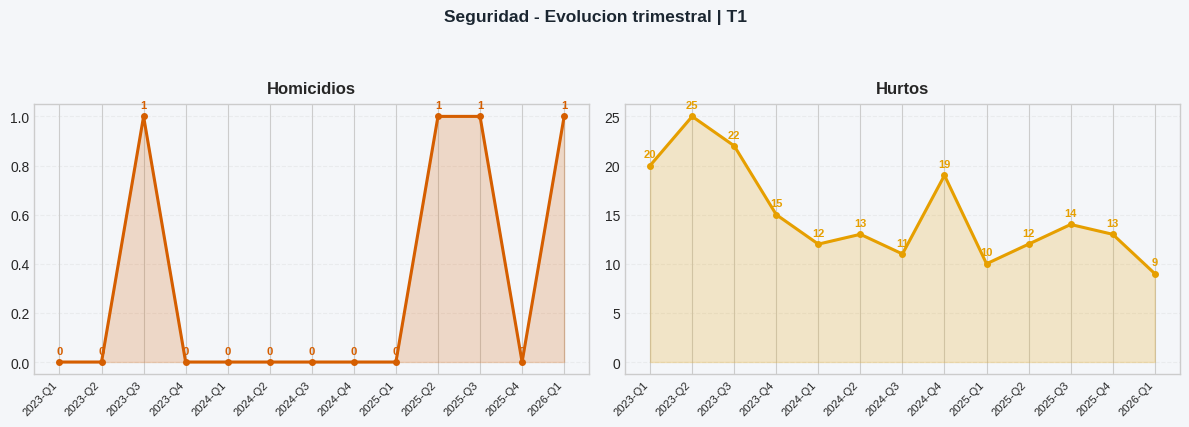

/tmp/ipykernel_33488/1599129436.py:88: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  annot.loc[label] = heat.loc[label].apply(lambda v: fmt_compacto(v, modes.get(label, 'int')))
/tmp/ipykernel_33488/1599129436.py:88: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  annot.loc[label] = heat.loc[label].apply(lambda v: fmt_compacto(v, modes.get(label, 'int')))
/tmp/ipykernel_33488/1599129436.py:88: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  annot.loc[label] = heat.loc[

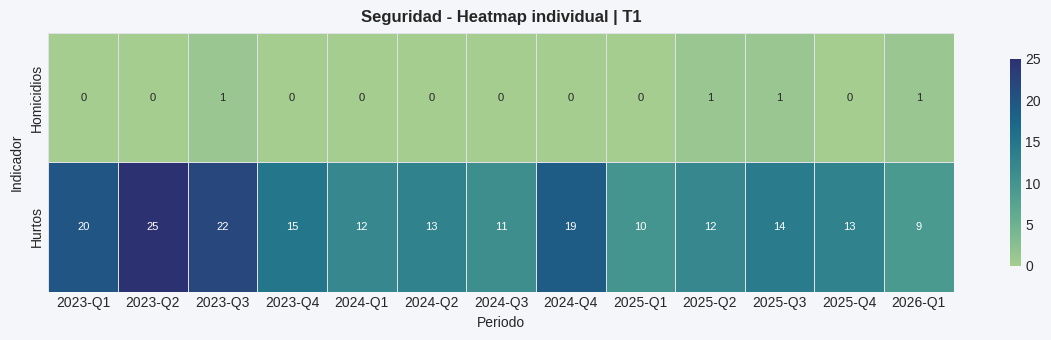

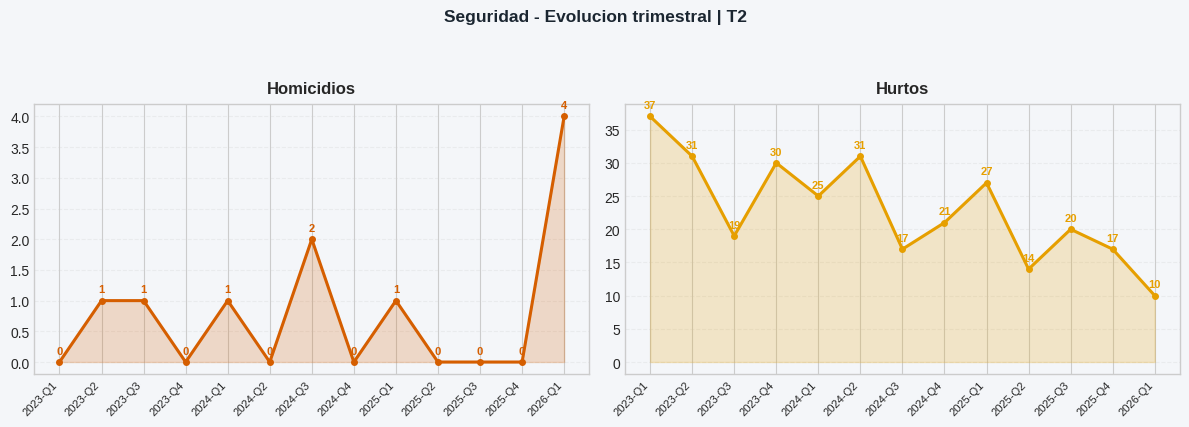

/tmp/ipykernel_33488/1599129436.py:88: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  annot.loc[label] = heat.loc[label].apply(lambda v: fmt_compacto(v, modes.get(label, 'int')))
/tmp/ipykernel_33488/1599129436.py:88: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  annot.loc[label] = heat.loc[label].apply(lambda v: fmt_compacto(v, modes.get(label, 'int')))
/tmp/ipykernel_33488/1599129436.py:88: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  annot.loc[label] = heat.loc[

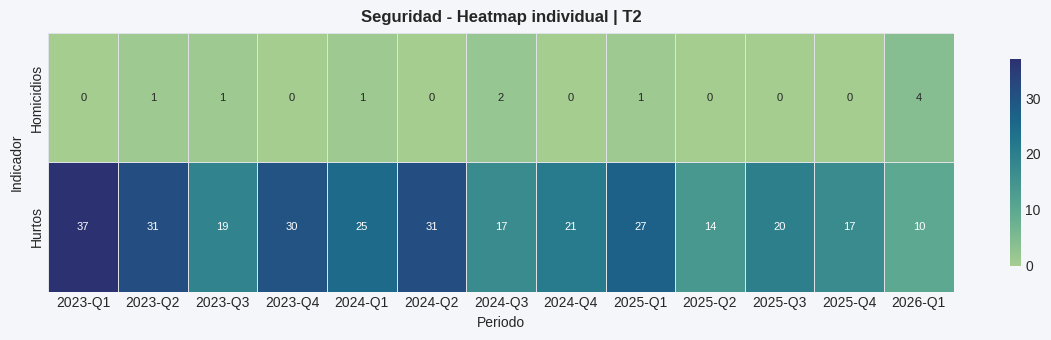

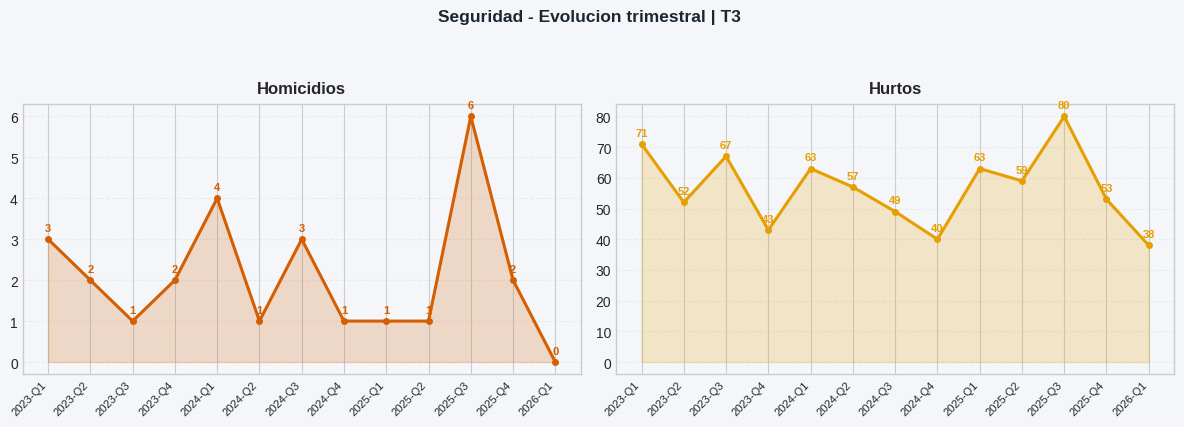

/tmp/ipykernel_33488/1599129436.py:88: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '3' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  annot.loc[label] = heat.loc[label].apply(lambda v: fmt_compacto(v, modes.get(label, 'int')))
/tmp/ipykernel_33488/1599129436.py:88: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '2' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  annot.loc[label] = heat.loc[label].apply(lambda v: fmt_compacto(v, modes.get(label, 'int')))
/tmp/ipykernel_33488/1599129436.py:88: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  annot.loc[label] = heat.loc[

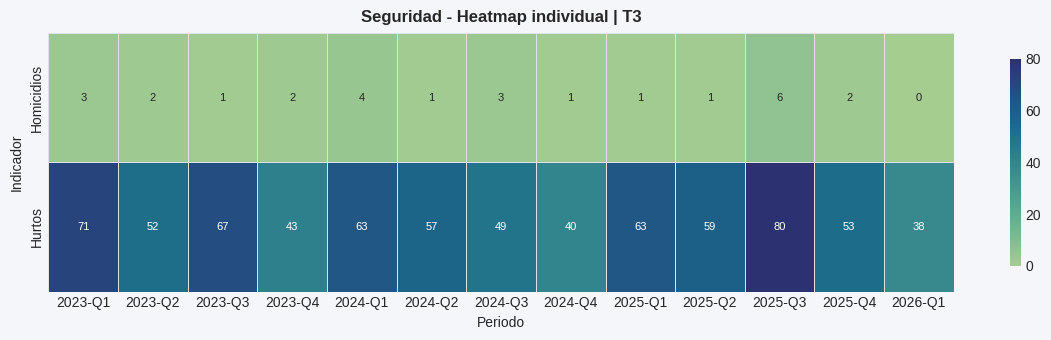

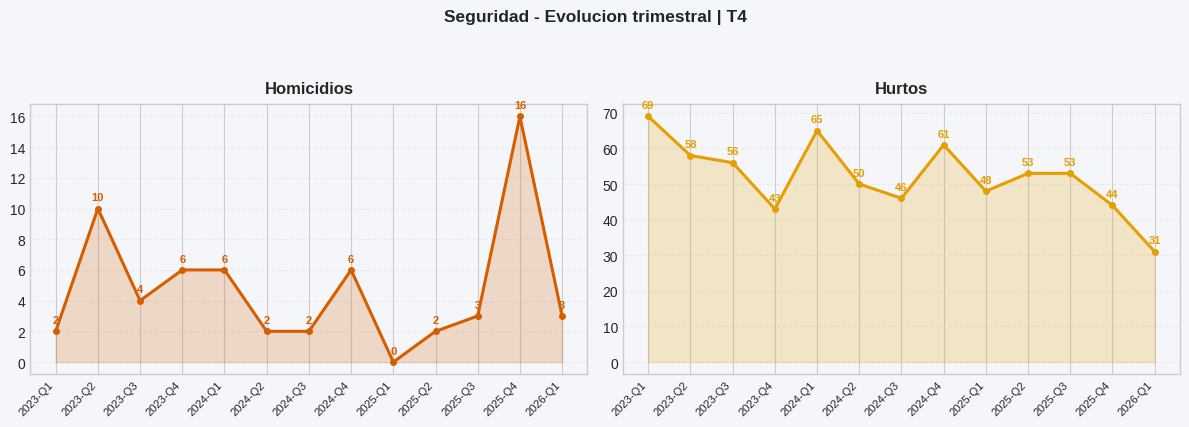

/tmp/ipykernel_33488/1599129436.py:88: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '2' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  annot.loc[label] = heat.loc[label].apply(lambda v: fmt_compacto(v, modes.get(label, 'int')))
/tmp/ipykernel_33488/1599129436.py:88: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '10' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  annot.loc[label] = heat.loc[label].apply(lambda v: fmt_compacto(v, modes.get(label, 'int')))
/tmp/ipykernel_33488/1599129436.py:88: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '4' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  annot.loc[label] = heat.loc

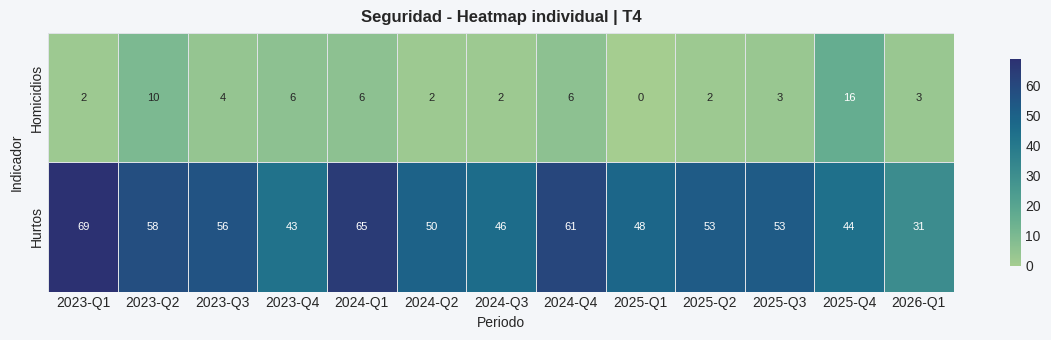

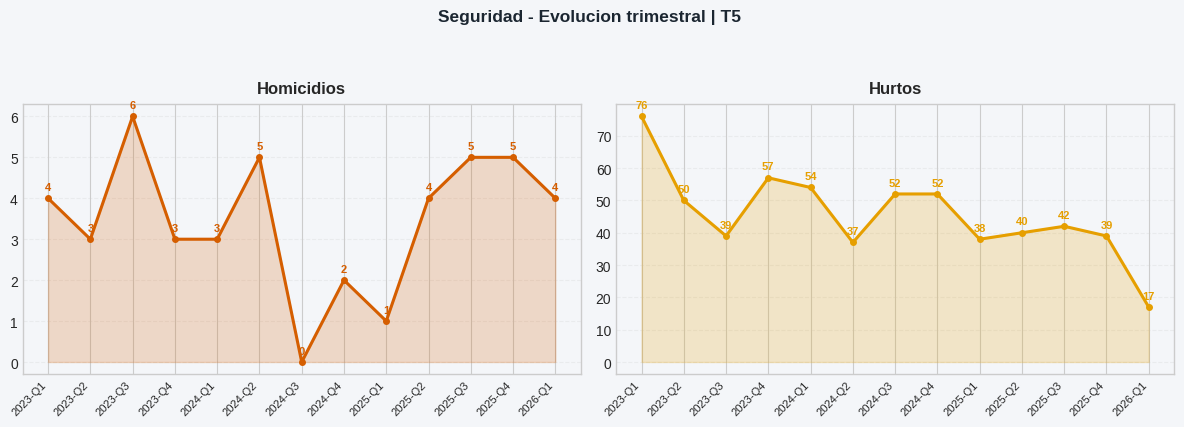

/tmp/ipykernel_33488/1599129436.py:88: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '4' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  annot.loc[label] = heat.loc[label].apply(lambda v: fmt_compacto(v, modes.get(label, 'int')))
/tmp/ipykernel_33488/1599129436.py:88: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '3' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  annot.loc[label] = heat.loc[label].apply(lambda v: fmt_compacto(v, modes.get(label, 'int')))
/tmp/ipykernel_33488/1599129436.py:88: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '6' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  annot.loc[label] = heat.loc[

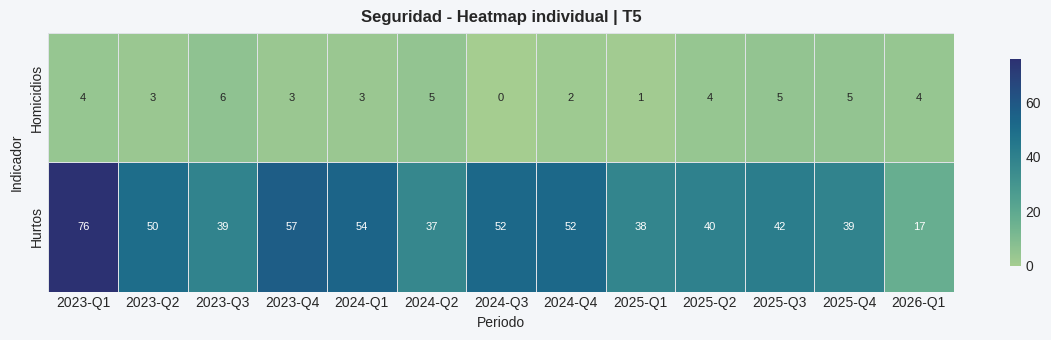

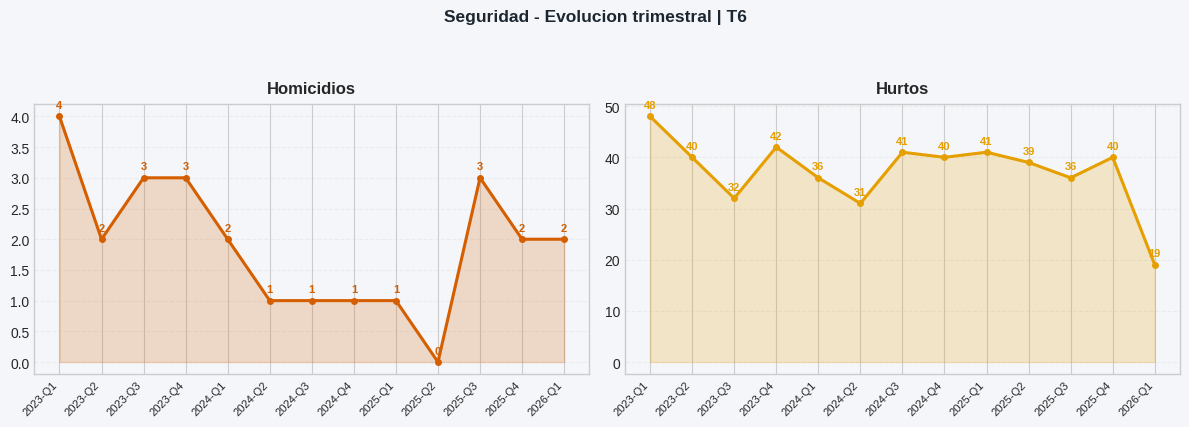

/tmp/ipykernel_33488/1599129436.py:88: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '4' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  annot.loc[label] = heat.loc[label].apply(lambda v: fmt_compacto(v, modes.get(label, 'int')))
/tmp/ipykernel_33488/1599129436.py:88: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '2' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  annot.loc[label] = heat.loc[label].apply(lambda v: fmt_compacto(v, modes.get(label, 'int')))
/tmp/ipykernel_33488/1599129436.py:88: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '3' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  annot.loc[label] = heat.loc[

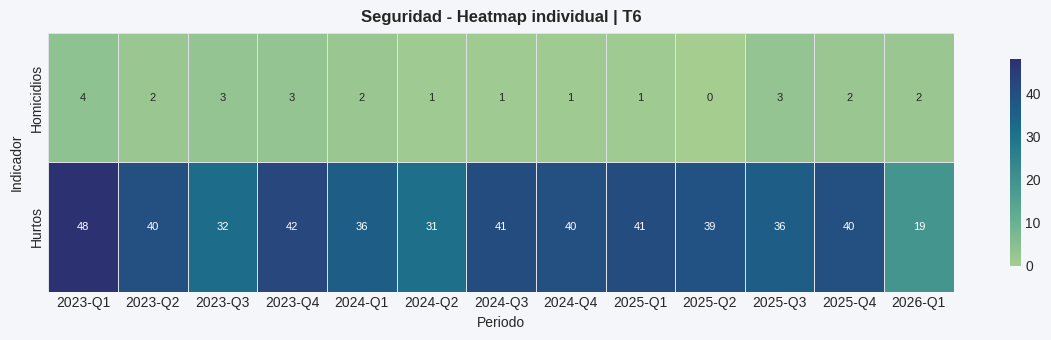

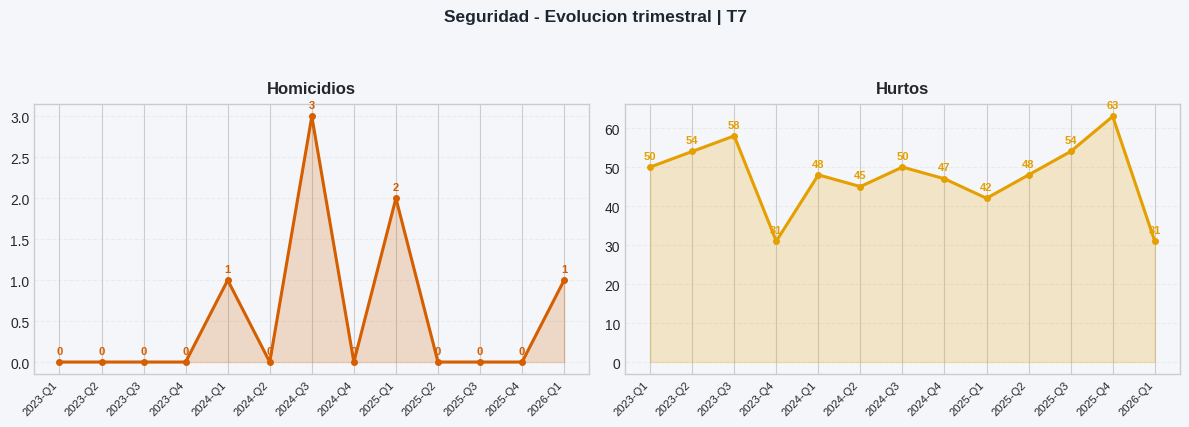

/tmp/ipykernel_33488/1599129436.py:88: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  annot.loc[label] = heat.loc[label].apply(lambda v: fmt_compacto(v, modes.get(label, 'int')))
/tmp/ipykernel_33488/1599129436.py:88: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  annot.loc[label] = heat.loc[label].apply(lambda v: fmt_compacto(v, modes.get(label, 'int')))
/tmp/ipykernel_33488/1599129436.py:88: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  annot.loc[label] = heat.loc[

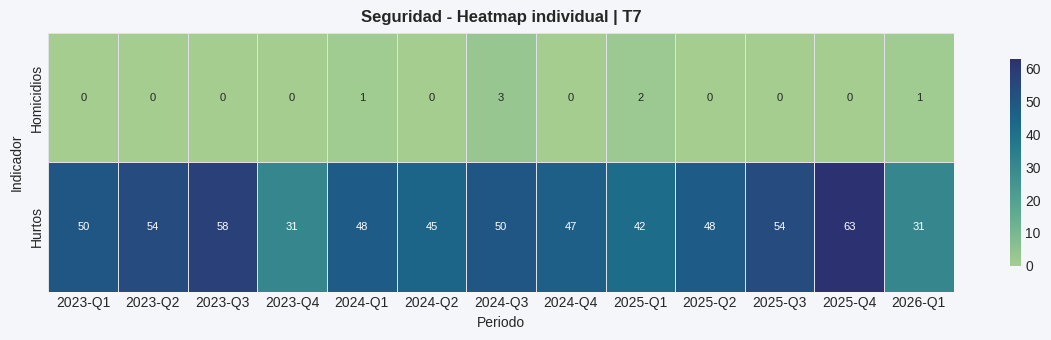

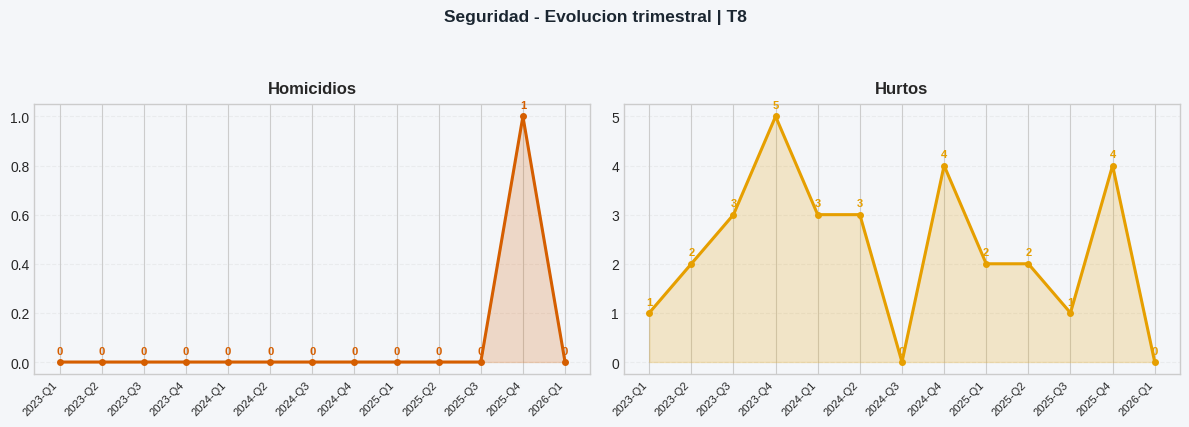

/tmp/ipykernel_33488/1599129436.py:88: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  annot.loc[label] = heat.loc[label].apply(lambda v: fmt_compacto(v, modes.get(label, 'int')))
/tmp/ipykernel_33488/1599129436.py:88: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  annot.loc[label] = heat.loc[label].apply(lambda v: fmt_compacto(v, modes.get(label, 'int')))
/tmp/ipykernel_33488/1599129436.py:88: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  annot.loc[label] = heat.loc[

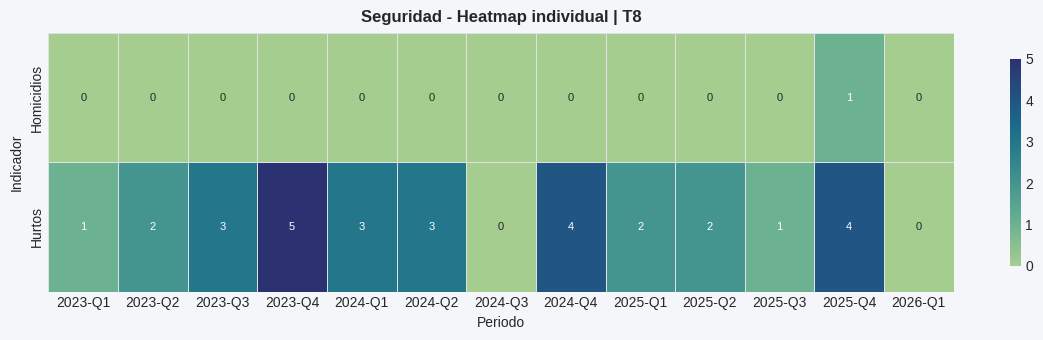

In [9]:
plot_general_trim(
    df_seg_trim,
    [('homicidios', 'Homicidios', OKI_BERMELL),
     ('hurtos', 'Hurtos', OKI_NARANJA)],
    'Seguridad - Evolucion trimestral general | Avenida Ciudad de Cali',
    'acc_seg_general_trim.png'
)

plot_heatmaps_tramo_period(
    df_seg_trim,
    [('homicidios', 'Homicidios', CMAP_CALIDO, 'int'),
     ('hurtos', 'Hurtos', CMAP_NEUTRO, 'int')],
    'Seguridad - Heatmap por tramo y trimestre | Avenida Ciudad de Cali',
    'acc_seg_heatmap_tramo_periodo.png'
)

for tramo in TRAMOS:
    plot_per_tramo_trim(
        df_seg_trim, tramo,
        [('homicidios', 'Homicidios', OKI_BERMELL),
         ('hurtos', 'Hurtos', OKI_NARANJA)],
        'Seguridad - Evolucion trimestral',
        f'acc_seg_trim_{tramo}.png'
    )
    plot_per_tramo_trim_heatmap(
        df_seg_trim, tramo,
        [('homicidios', 'Homicidios', 'int'),
         ('hurtos', 'Hurtos', 'int')],
        'Seguridad - Heatmap individual',
        f'acc_seg_heatmap_{tramo}.png'
    )


## Movilidad y Accesibilidad


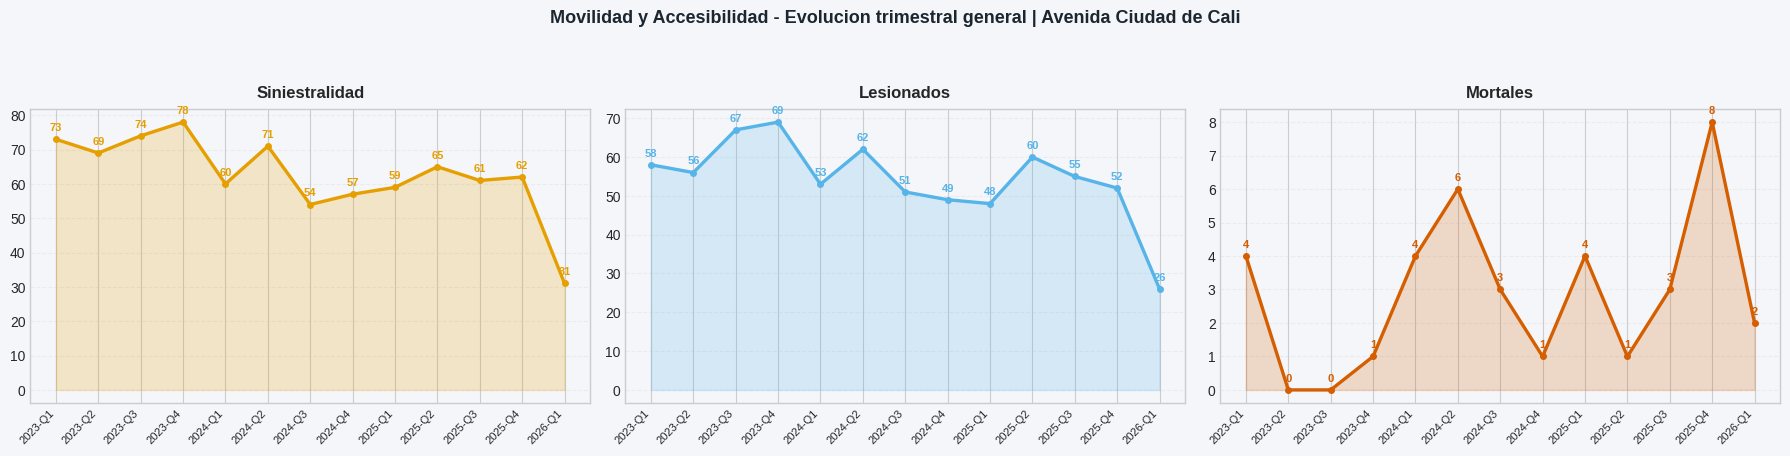

/tmp/ipykernel_33488/1596642247.py:133: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return pivot.applymap(lambda v: fmt_compacto(v, mode))
/tmp/ipykernel_33488/1596642247.py:133: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return pivot.applymap(lambda v: fmt_compacto(v, mode))
/tmp/ipykernel_33488/1596642247.py:133: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return pivot.applymap(lambda v: fmt_compacto(v, mode))


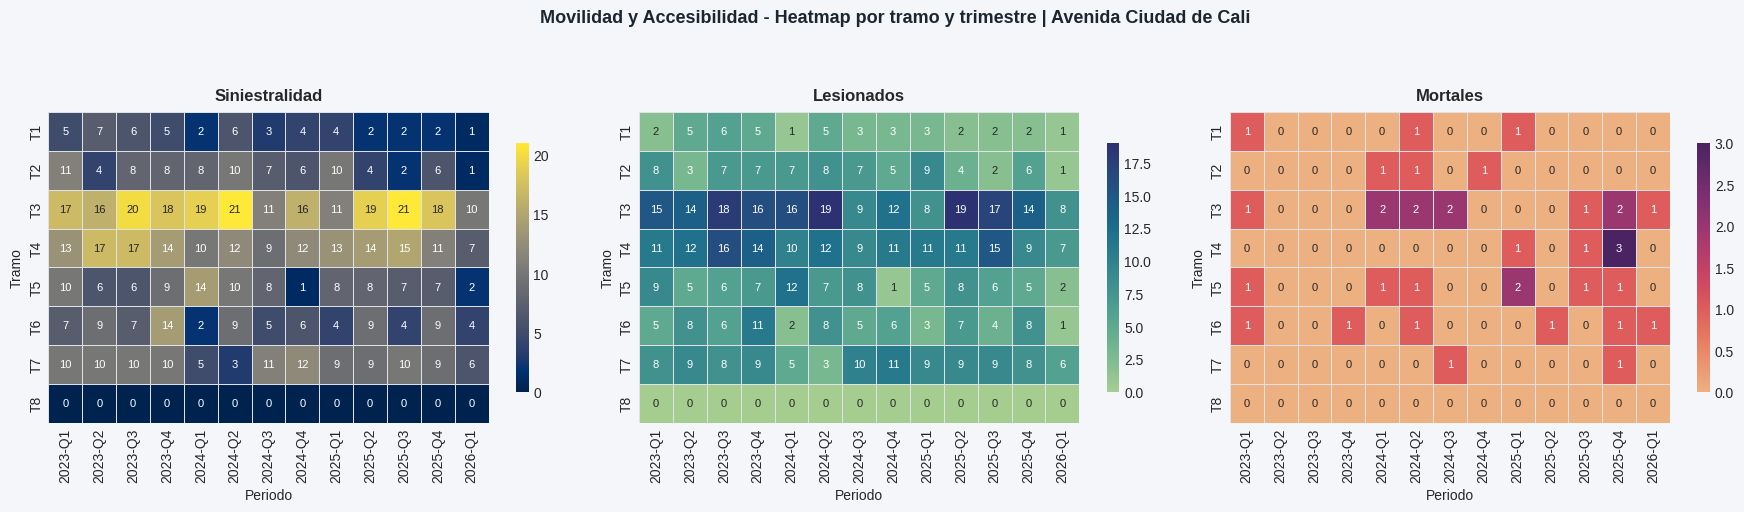

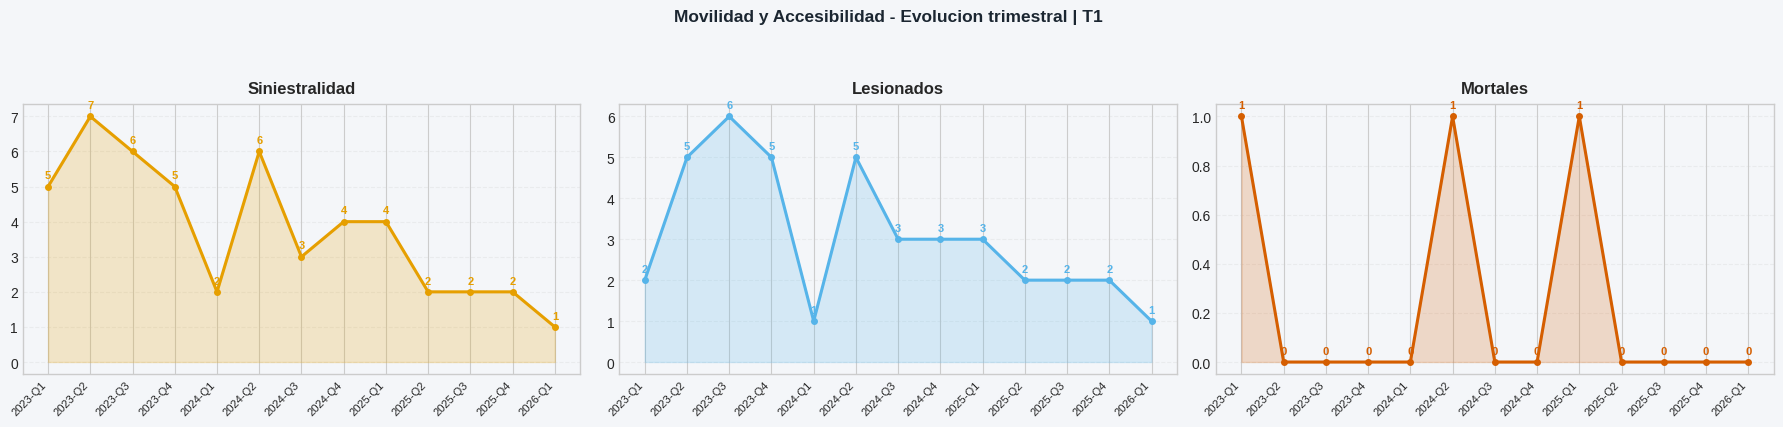

/tmp/ipykernel_33488/1599129436.py:88: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '5' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  annot.loc[label] = heat.loc[label].apply(lambda v: fmt_compacto(v, modes.get(label, 'int')))
/tmp/ipykernel_33488/1599129436.py:88: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '7' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  annot.loc[label] = heat.loc[label].apply(lambda v: fmt_compacto(v, modes.get(label, 'int')))
/tmp/ipykernel_33488/1599129436.py:88: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '6' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  annot.loc[label] = heat.loc[

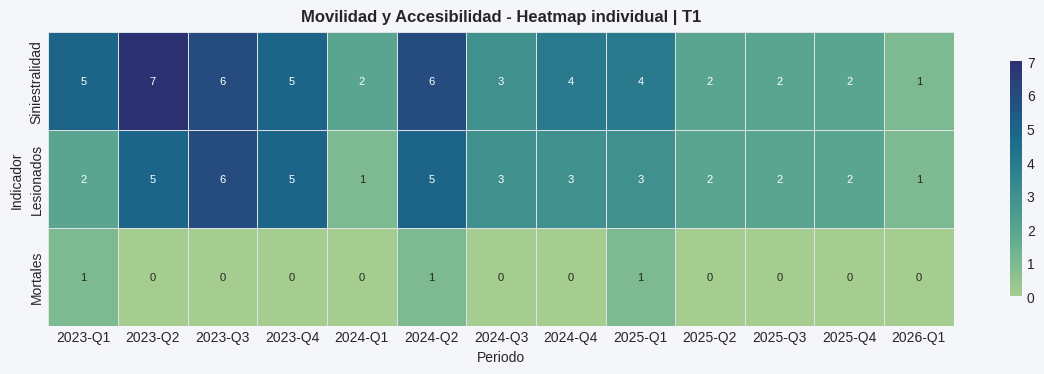

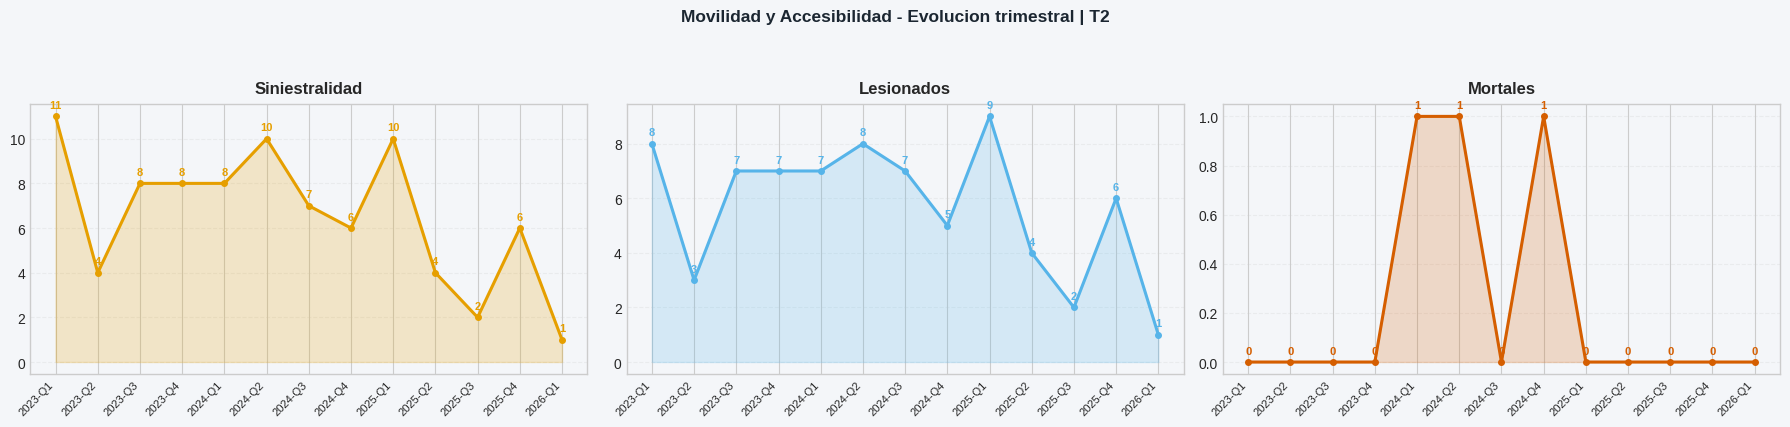

/tmp/ipykernel_33488/1599129436.py:88: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '11' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  annot.loc[label] = heat.loc[label].apply(lambda v: fmt_compacto(v, modes.get(label, 'int')))
/tmp/ipykernel_33488/1599129436.py:88: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '4' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  annot.loc[label] = heat.loc[label].apply(lambda v: fmt_compacto(v, modes.get(label, 'int')))
/tmp/ipykernel_33488/1599129436.py:88: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '8' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  annot.loc[label] = heat.loc

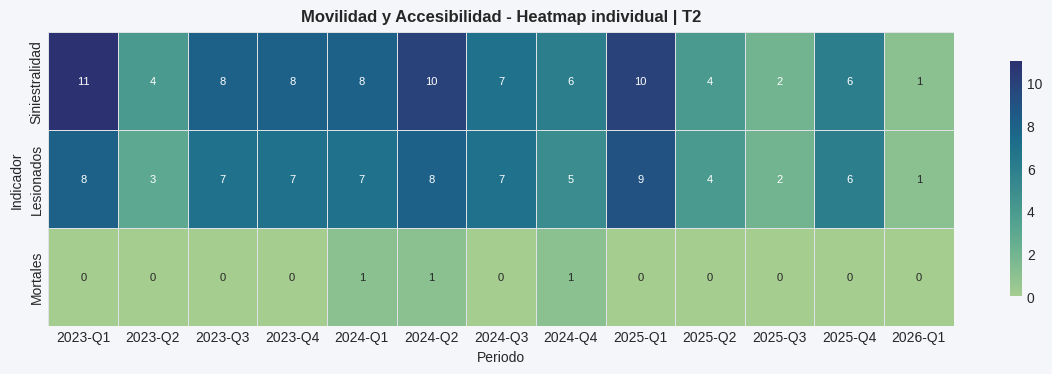

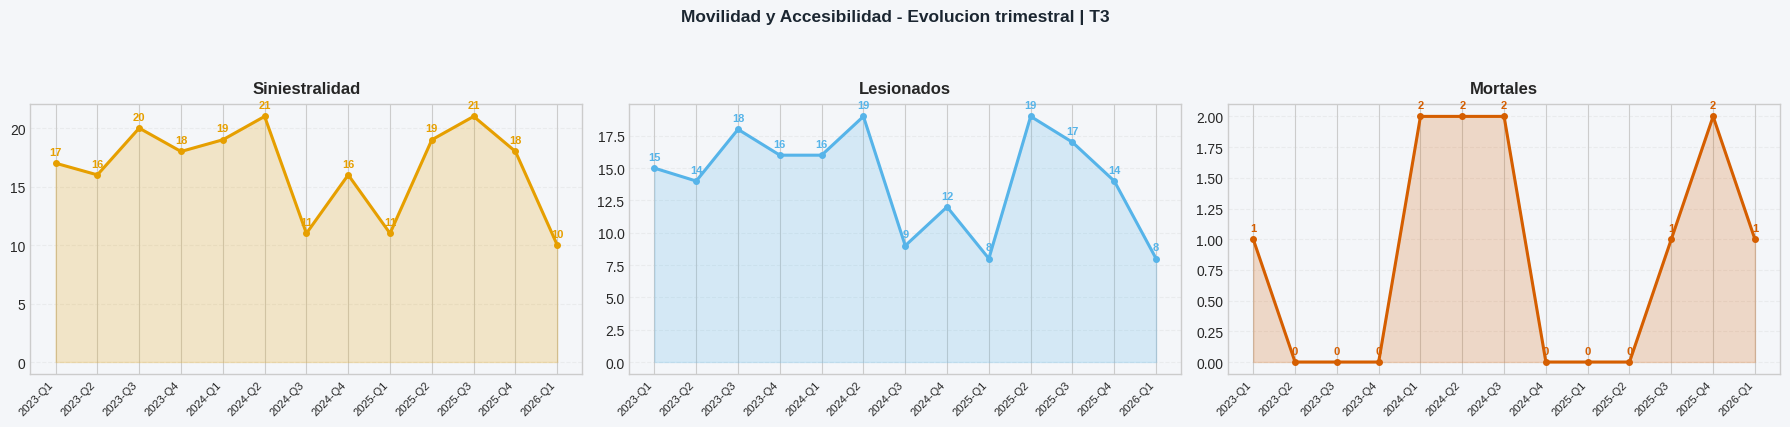

/tmp/ipykernel_33488/1599129436.py:88: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '17' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  annot.loc[label] = heat.loc[label].apply(lambda v: fmt_compacto(v, modes.get(label, 'int')))
/tmp/ipykernel_33488/1599129436.py:88: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '16' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  annot.loc[label] = heat.loc[label].apply(lambda v: fmt_compacto(v, modes.get(label, 'int')))
/tmp/ipykernel_33488/1599129436.py:88: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '20' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  annot.loc[label] = heat.l

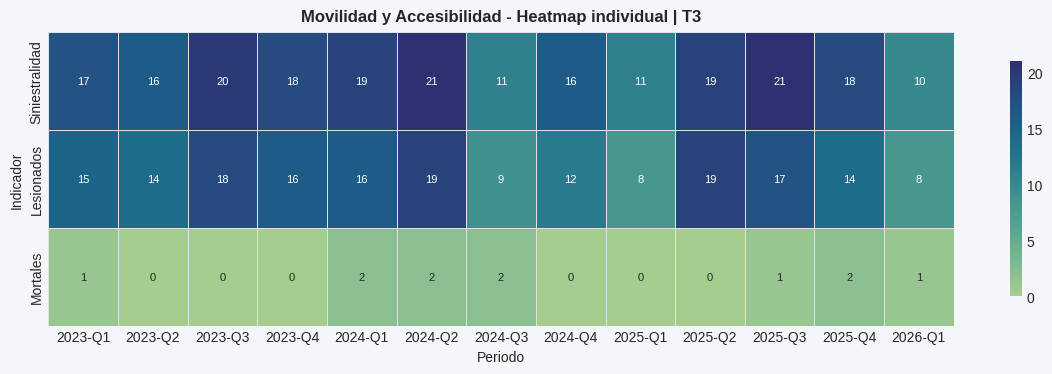

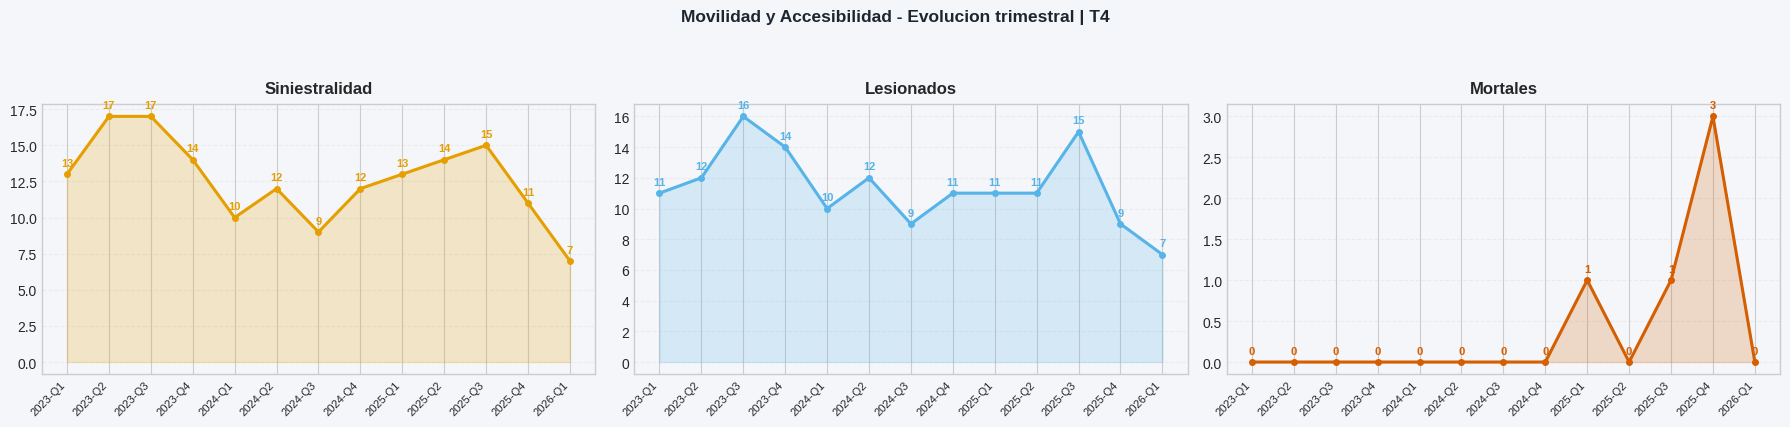

/tmp/ipykernel_33488/1599129436.py:88: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '13' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  annot.loc[label] = heat.loc[label].apply(lambda v: fmt_compacto(v, modes.get(label, 'int')))
/tmp/ipykernel_33488/1599129436.py:88: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '17' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  annot.loc[label] = heat.loc[label].apply(lambda v: fmt_compacto(v, modes.get(label, 'int')))
/tmp/ipykernel_33488/1599129436.py:88: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '17' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  annot.loc[label] = heat.l

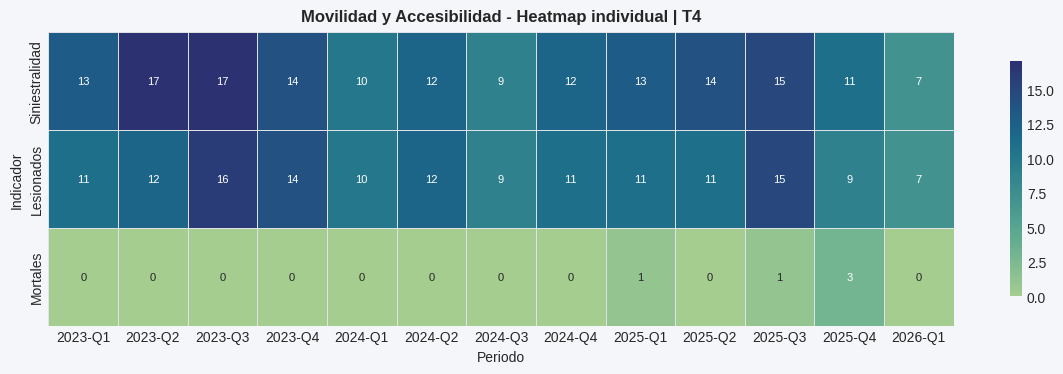

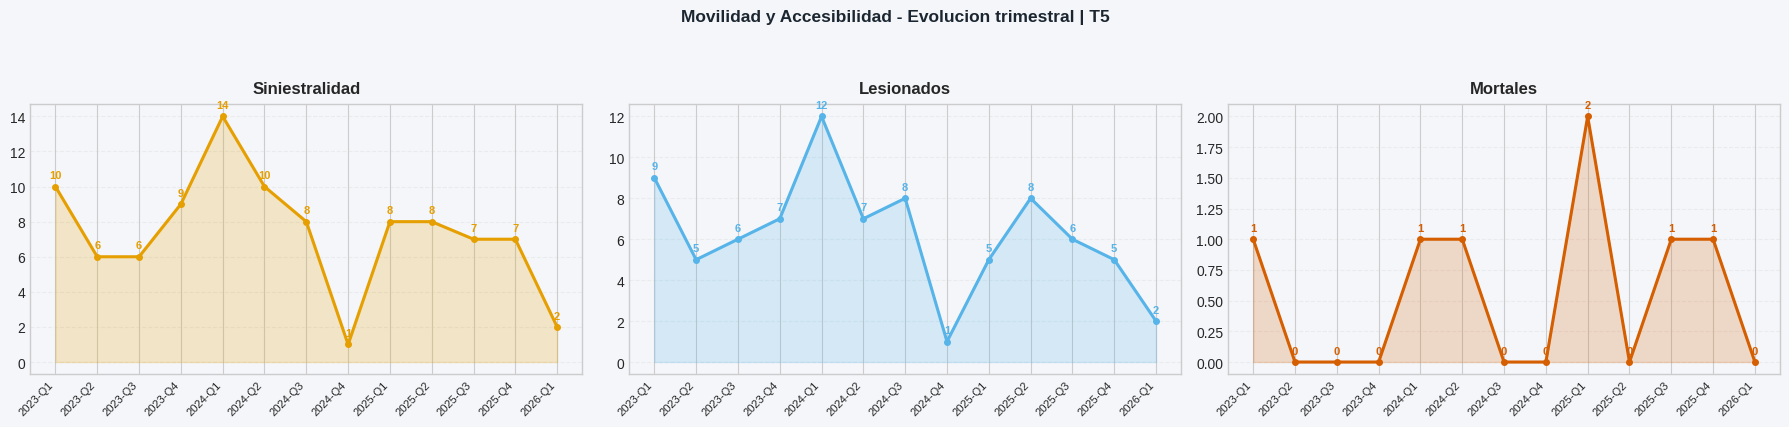

/tmp/ipykernel_33488/1599129436.py:88: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '10' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  annot.loc[label] = heat.loc[label].apply(lambda v: fmt_compacto(v, modes.get(label, 'int')))
/tmp/ipykernel_33488/1599129436.py:88: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '6' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  annot.loc[label] = heat.loc[label].apply(lambda v: fmt_compacto(v, modes.get(label, 'int')))
/tmp/ipykernel_33488/1599129436.py:88: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '6' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  annot.loc[label] = heat.loc

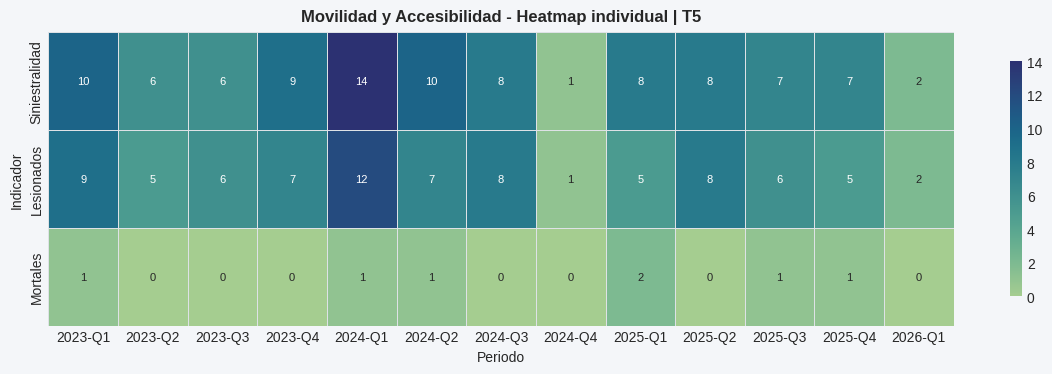

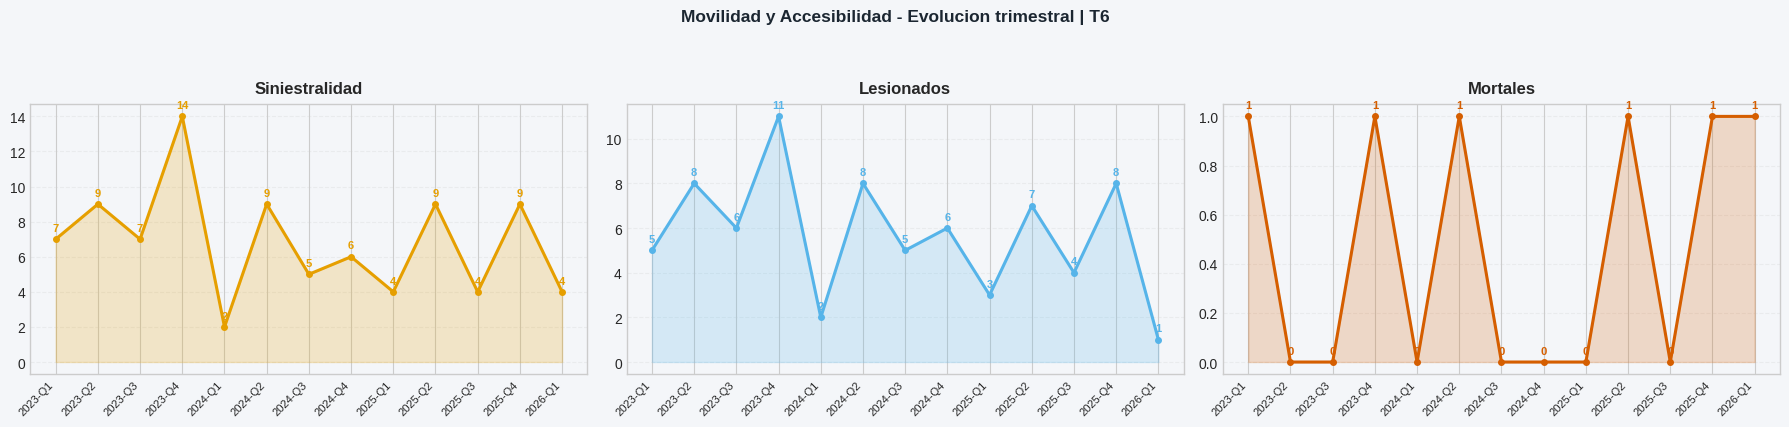

/tmp/ipykernel_33488/1599129436.py:88: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '7' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  annot.loc[label] = heat.loc[label].apply(lambda v: fmt_compacto(v, modes.get(label, 'int')))
/tmp/ipykernel_33488/1599129436.py:88: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '9' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  annot.loc[label] = heat.loc[label].apply(lambda v: fmt_compacto(v, modes.get(label, 'int')))
/tmp/ipykernel_33488/1599129436.py:88: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '7' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  annot.loc[label] = heat.loc[

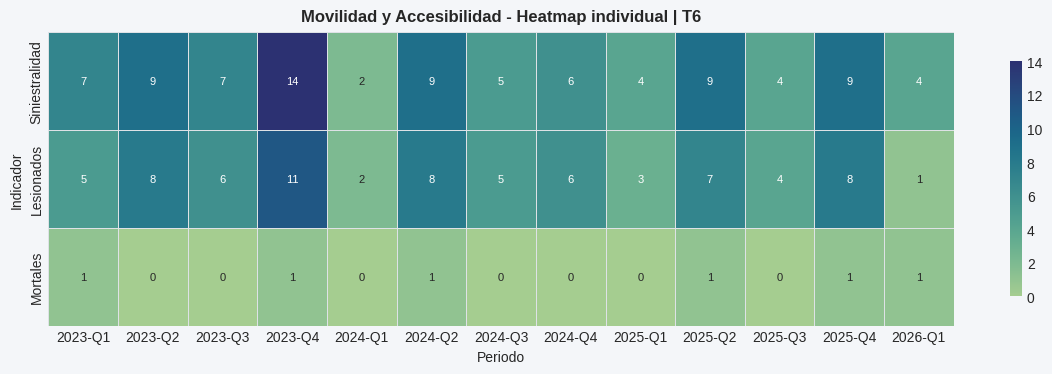

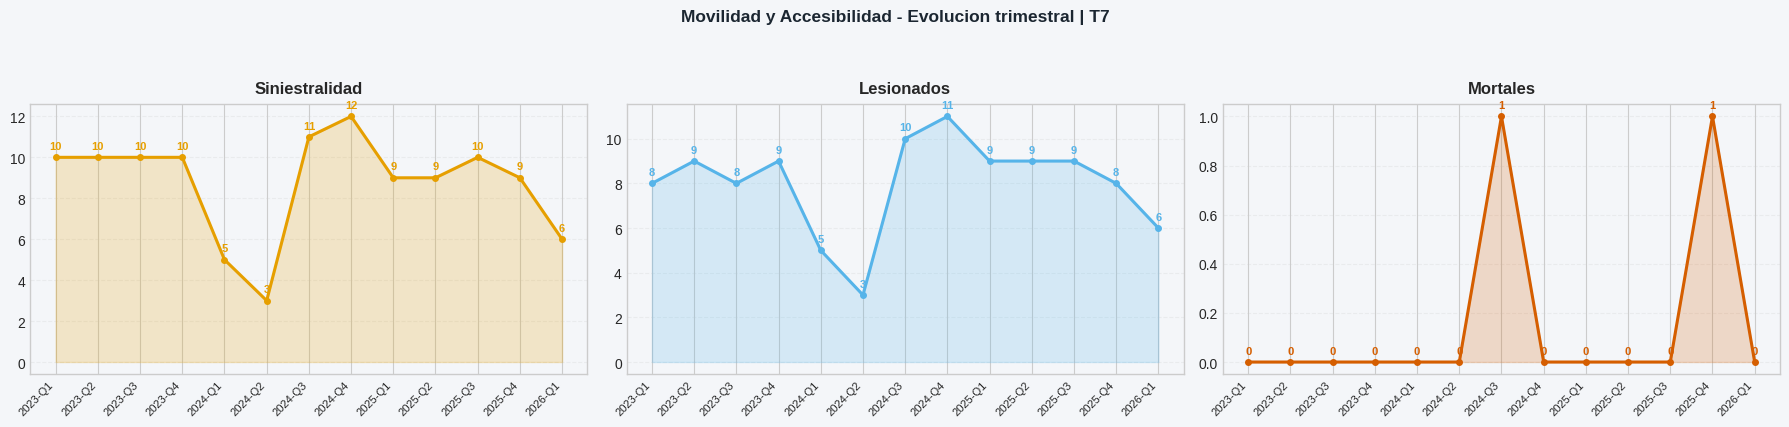

/tmp/ipykernel_33488/1599129436.py:88: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '10' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  annot.loc[label] = heat.loc[label].apply(lambda v: fmt_compacto(v, modes.get(label, 'int')))
/tmp/ipykernel_33488/1599129436.py:88: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '10' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  annot.loc[label] = heat.loc[label].apply(lambda v: fmt_compacto(v, modes.get(label, 'int')))
/tmp/ipykernel_33488/1599129436.py:88: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '10' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  annot.loc[label] = heat.l

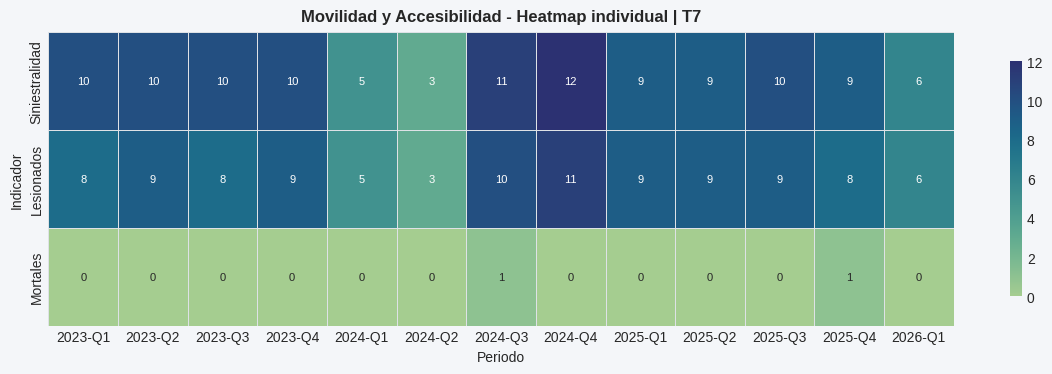

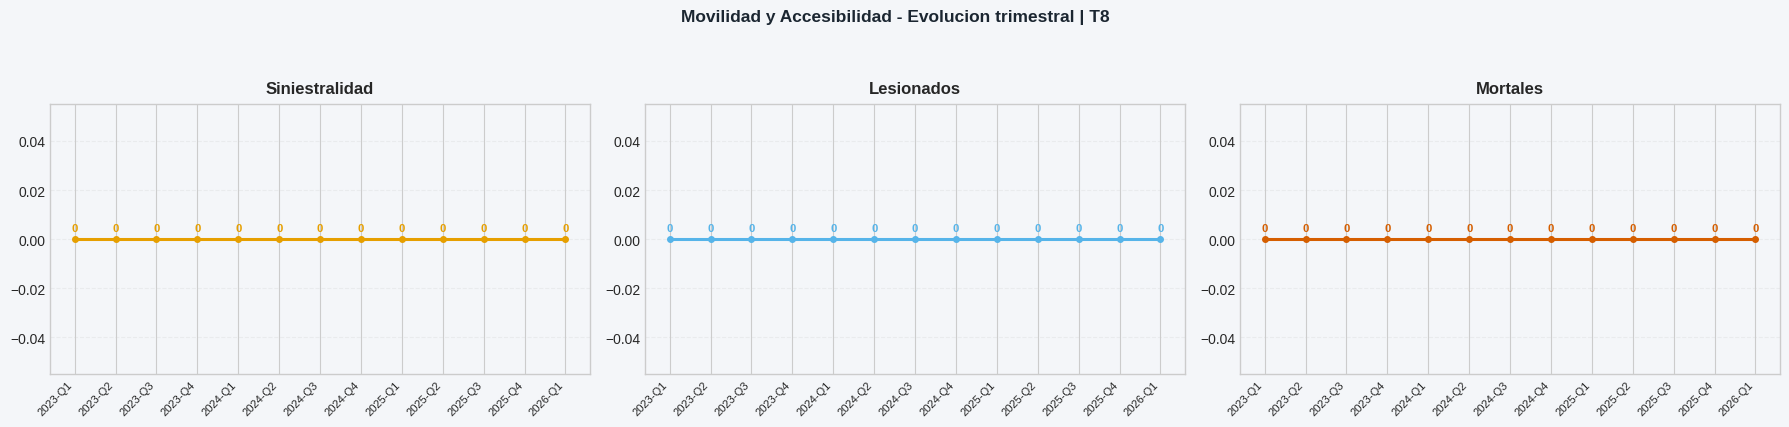

/tmp/ipykernel_33488/1599129436.py:88: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  annot.loc[label] = heat.loc[label].apply(lambda v: fmt_compacto(v, modes.get(label, 'int')))
/tmp/ipykernel_33488/1599129436.py:88: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  annot.loc[label] = heat.loc[label].apply(lambda v: fmt_compacto(v, modes.get(label, 'int')))
/tmp/ipykernel_33488/1599129436.py:88: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  annot.loc[label] = heat.loc[

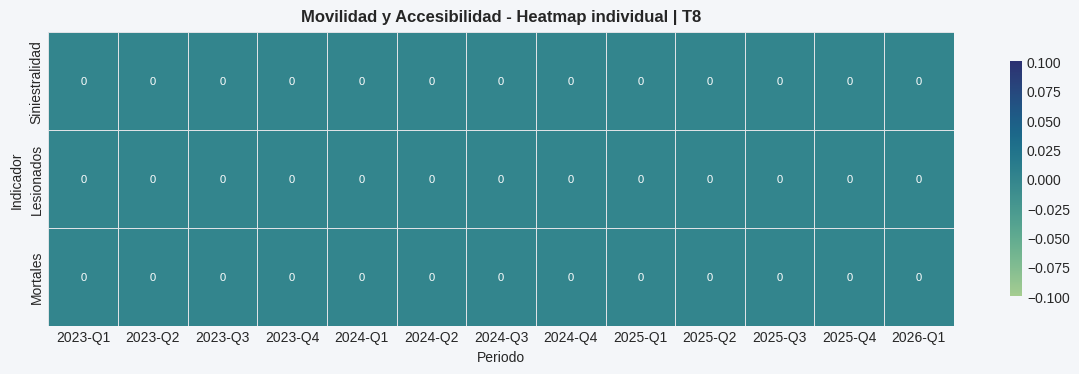

In [10]:
plot_general_trim(
    df_mov_trim,
    [('siniestralidad', 'Siniestralidad', OKI_NARANJA),
     ('lesionados', 'Lesionados', OKI_AZUL_C),
     ('mortales', 'Mortales', OKI_BERMELL)],
    'Movilidad y Accesibilidad - Evolucion trimestral general | Avenida Ciudad de Cali',
    'acc_mov_general_trim.png'
)

plot_heatmaps_tramo_period(
    df_mov_trim,
    [('siniestralidad', 'Siniestralidad', CMAP_NEUTRO, 'int'),
     ('lesionados', 'Lesionados', CMAP_FRIO, 'int'),
     ('mortales', 'Mortales', CMAP_CALIDO, 'int')],
    'Movilidad y Accesibilidad - Heatmap por tramo y trimestre | Avenida Ciudad de Cali',
    'acc_mov_heatmap_tramo_periodo.png'
)

for tramo in TRAMOS:
    plot_per_tramo_trim(
        df_mov_trim, tramo,
        [('siniestralidad', 'Siniestralidad', OKI_NARANJA),
         ('lesionados', 'Lesionados', OKI_AZUL_C),
         ('mortales', 'Mortales', OKI_BERMELL)],
        'Movilidad y Accesibilidad - Evolucion trimestral',
        f'acc_mov_trim_{tramo}.png'
    )
    plot_per_tramo_trim_heatmap(
        df_mov_trim, tramo,
        [('siniestralidad', 'Siniestralidad', 'int'),
         ('lesionados', 'Lesionados', 'int'),
         ('mortales', 'Mortales', 'int')],
        'Movilidad y Accesibilidad - Heatmap individual',
        f'acc_mov_heatmap_{tramo}.png'
    )


## Desarrollo Social

> Esta version usa unicamente los componentes disponibles hoy por tramo: `VIF`, `Rinas` y `SPA`.  
> `Matricula` y `Desercion` quedan pendientes hasta contar con archivos por tramo.


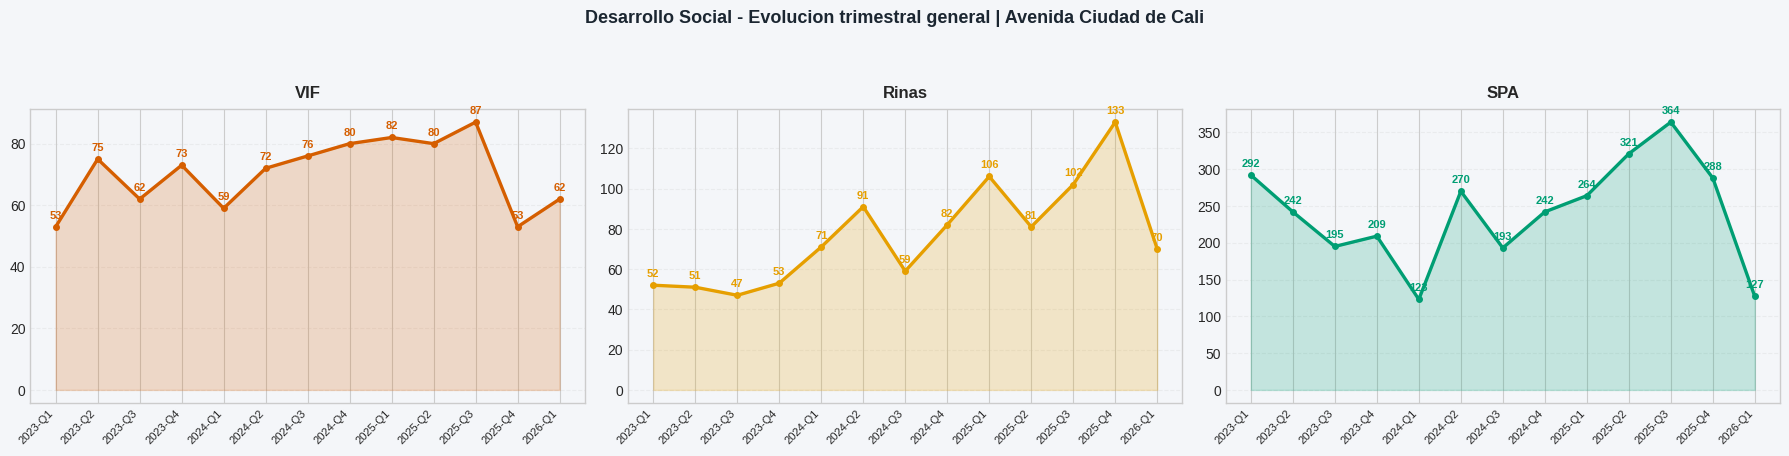

/tmp/ipykernel_33488/1596642247.py:133: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return pivot.applymap(lambda v: fmt_compacto(v, mode))
/tmp/ipykernel_33488/1596642247.py:133: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return pivot.applymap(lambda v: fmt_compacto(v, mode))
/tmp/ipykernel_33488/1596642247.py:133: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return pivot.applymap(lambda v: fmt_compacto(v, mode))


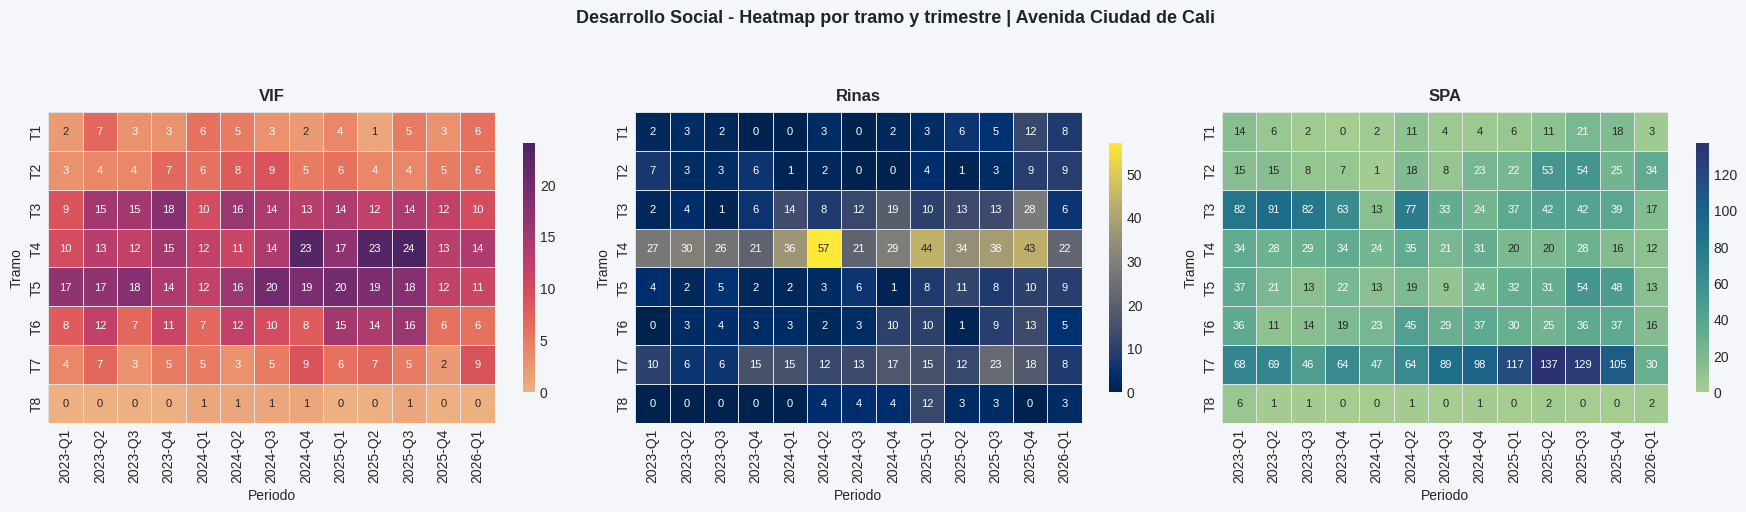

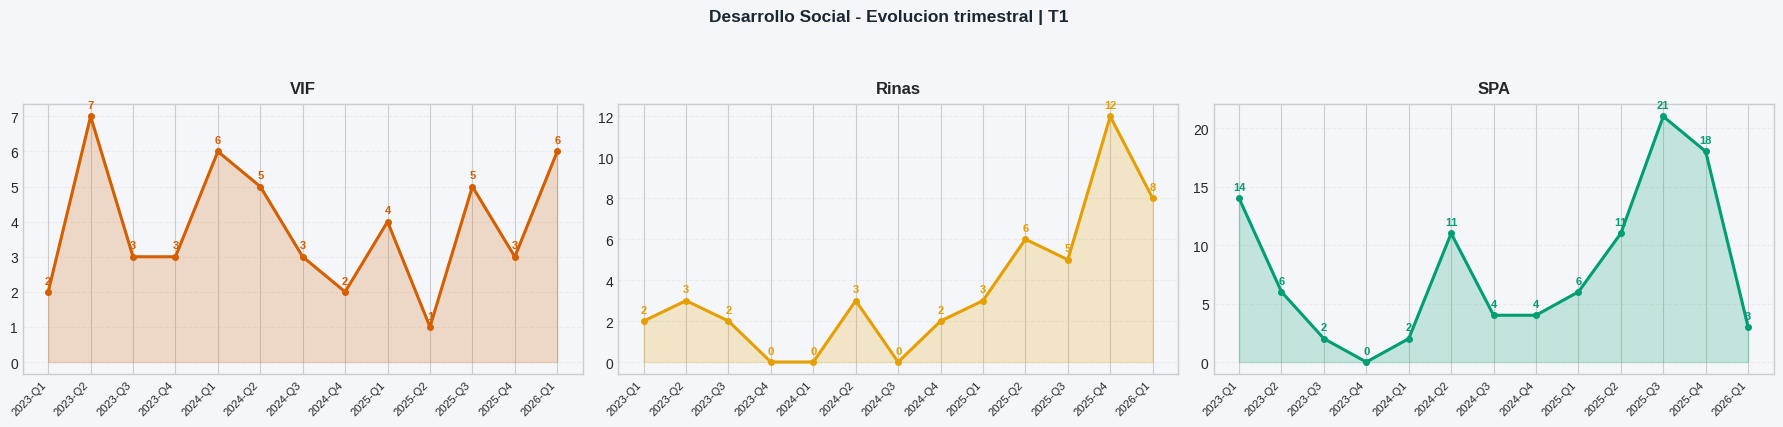

/tmp/ipykernel_33488/1599129436.py:88: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '2' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  annot.loc[label] = heat.loc[label].apply(lambda v: fmt_compacto(v, modes.get(label, 'int')))
/tmp/ipykernel_33488/1599129436.py:88: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '7' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  annot.loc[label] = heat.loc[label].apply(lambda v: fmt_compacto(v, modes.get(label, 'int')))
/tmp/ipykernel_33488/1599129436.py:88: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '3' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  annot.loc[label] = heat.loc[

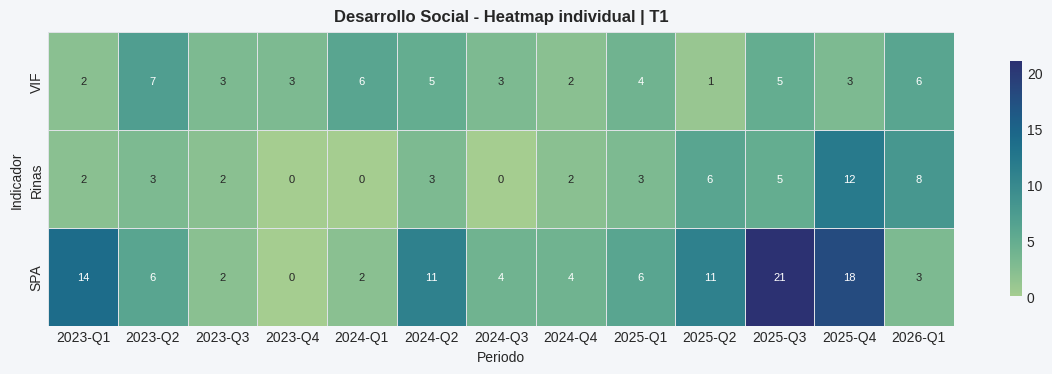

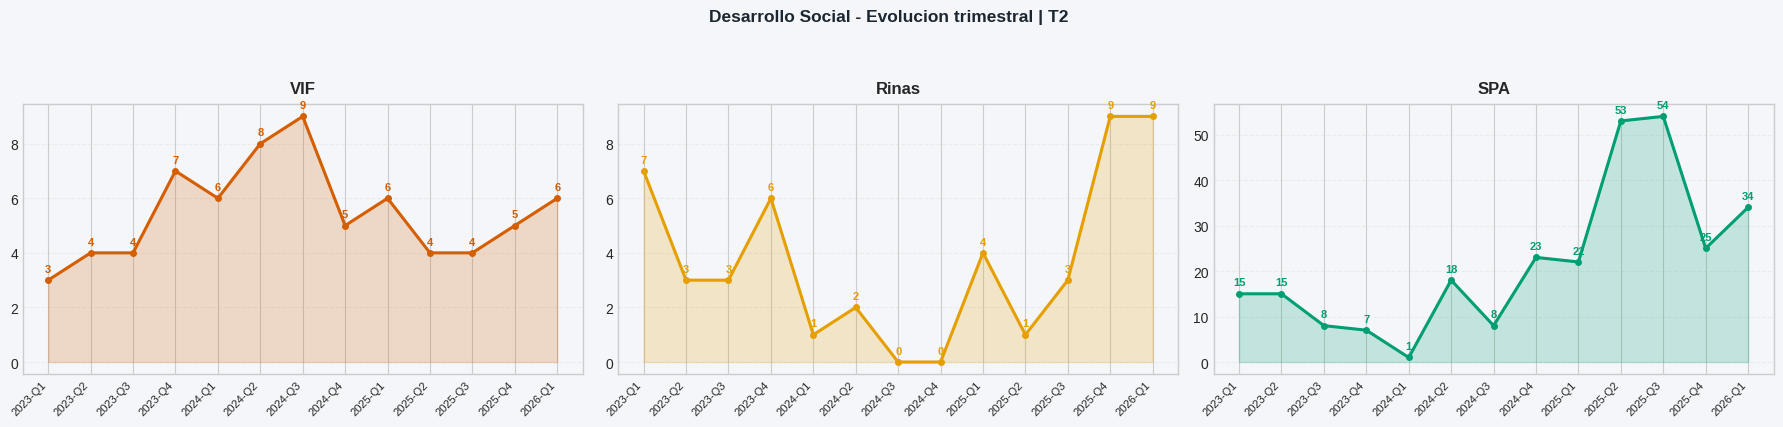

/tmp/ipykernel_33488/1599129436.py:88: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '3' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  annot.loc[label] = heat.loc[label].apply(lambda v: fmt_compacto(v, modes.get(label, 'int')))
/tmp/ipykernel_33488/1599129436.py:88: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '4' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  annot.loc[label] = heat.loc[label].apply(lambda v: fmt_compacto(v, modes.get(label, 'int')))
/tmp/ipykernel_33488/1599129436.py:88: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '4' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  annot.loc[label] = heat.loc[

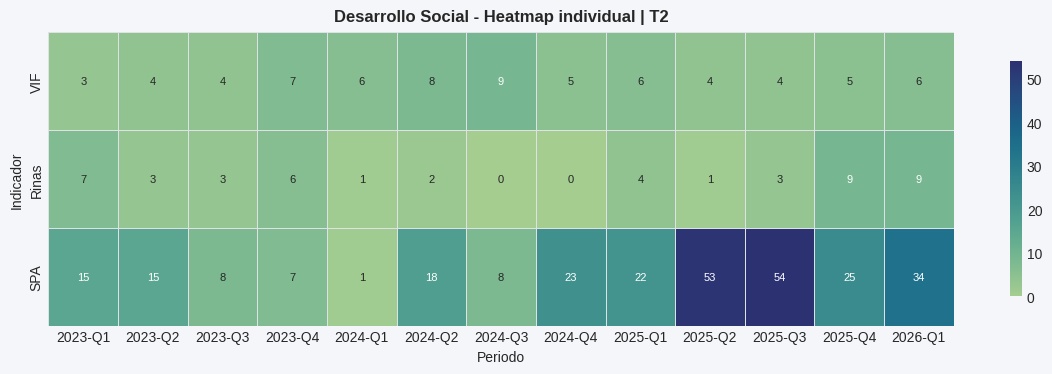

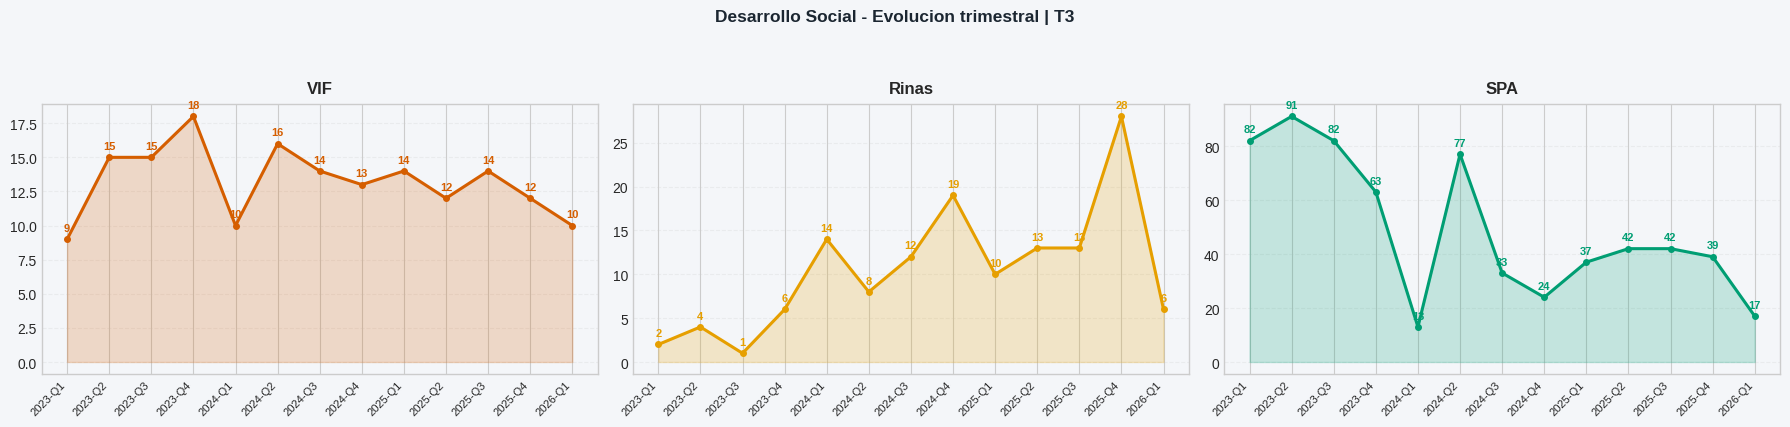

/tmp/ipykernel_33488/1599129436.py:88: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '9' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  annot.loc[label] = heat.loc[label].apply(lambda v: fmt_compacto(v, modes.get(label, 'int')))
/tmp/ipykernel_33488/1599129436.py:88: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '15' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  annot.loc[label] = heat.loc[label].apply(lambda v: fmt_compacto(v, modes.get(label, 'int')))
/tmp/ipykernel_33488/1599129436.py:88: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '15' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  annot.loc[label] = heat.lo

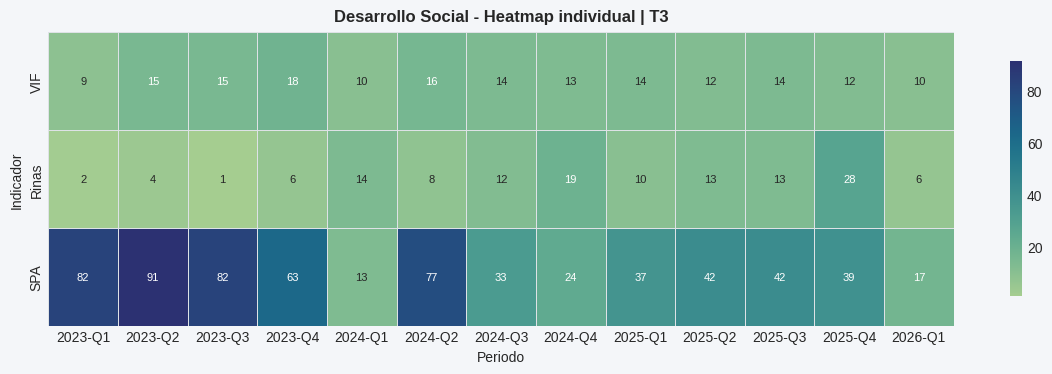

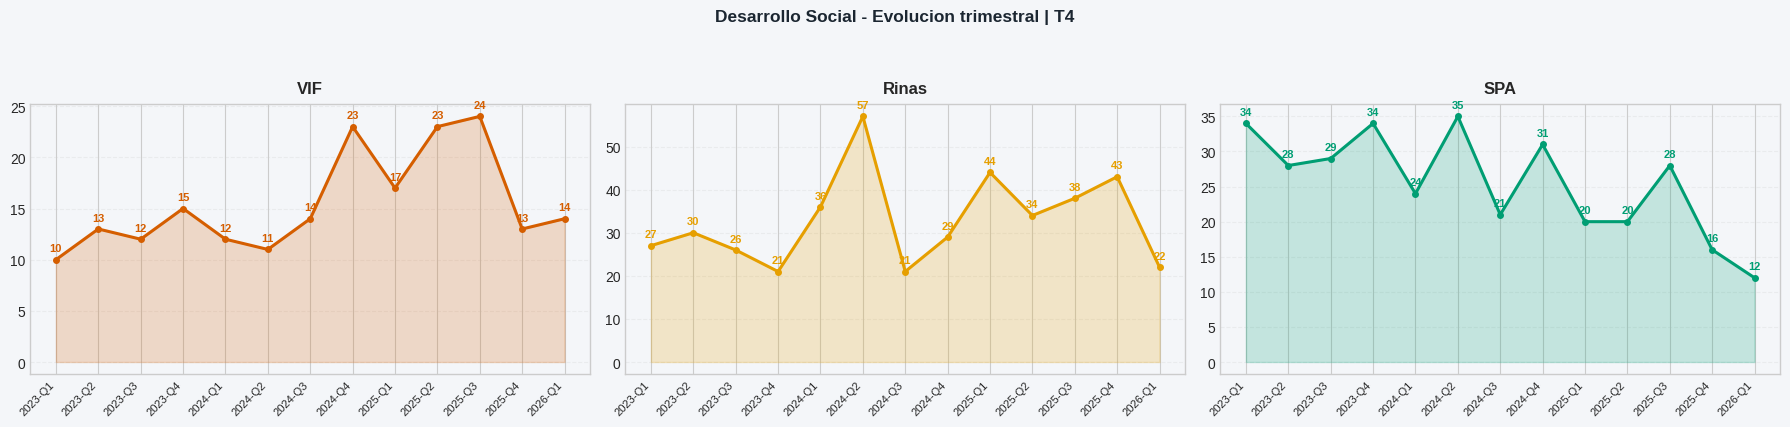

/tmp/ipykernel_33488/1599129436.py:88: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '10' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  annot.loc[label] = heat.loc[label].apply(lambda v: fmt_compacto(v, modes.get(label, 'int')))
/tmp/ipykernel_33488/1599129436.py:88: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '13' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  annot.loc[label] = heat.loc[label].apply(lambda v: fmt_compacto(v, modes.get(label, 'int')))
/tmp/ipykernel_33488/1599129436.py:88: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '12' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  annot.loc[label] = heat.l

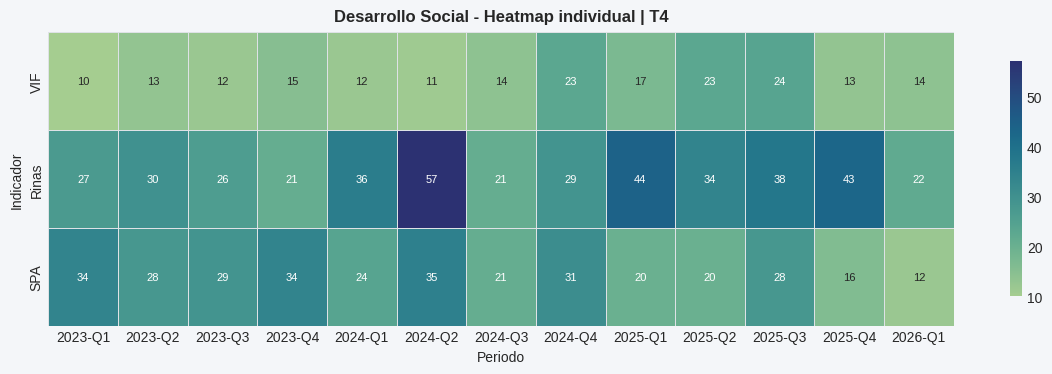

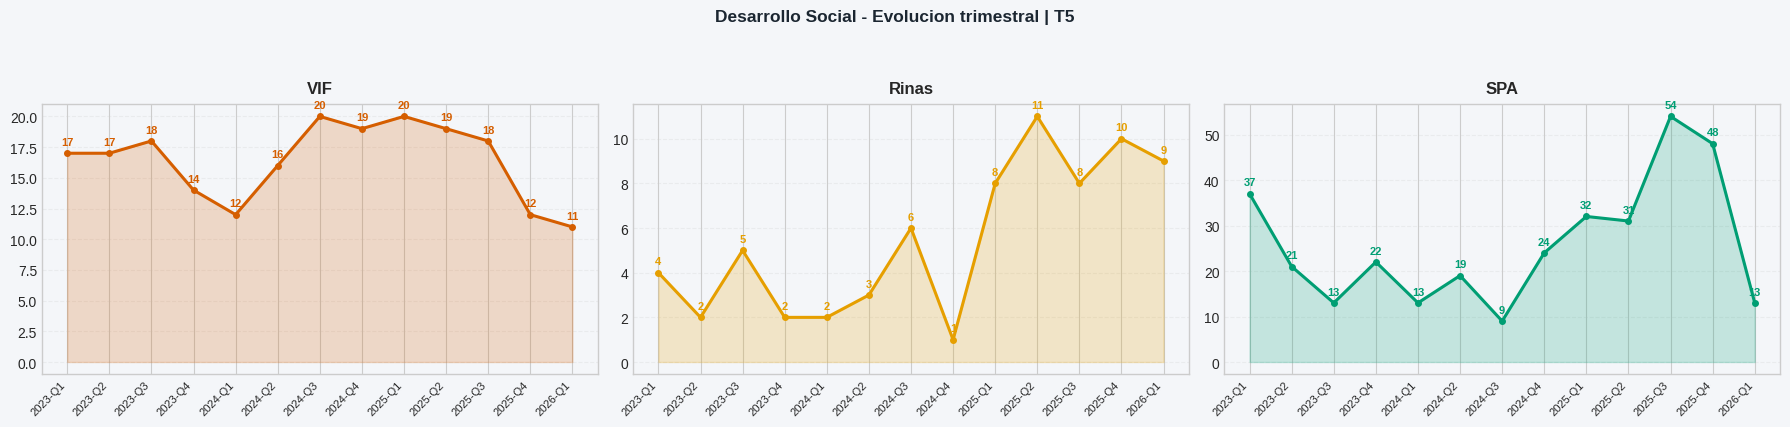

/tmp/ipykernel_33488/1599129436.py:88: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '17' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  annot.loc[label] = heat.loc[label].apply(lambda v: fmt_compacto(v, modes.get(label, 'int')))
/tmp/ipykernel_33488/1599129436.py:88: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '17' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  annot.loc[label] = heat.loc[label].apply(lambda v: fmt_compacto(v, modes.get(label, 'int')))
/tmp/ipykernel_33488/1599129436.py:88: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '18' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  annot.loc[label] = heat.l

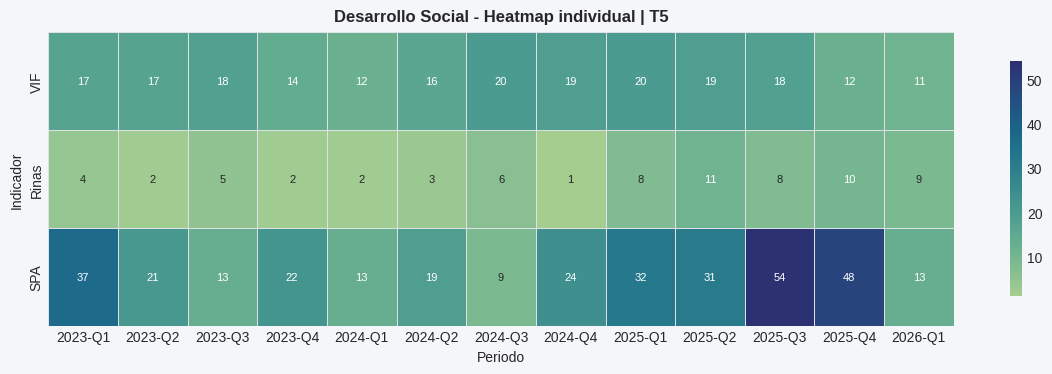

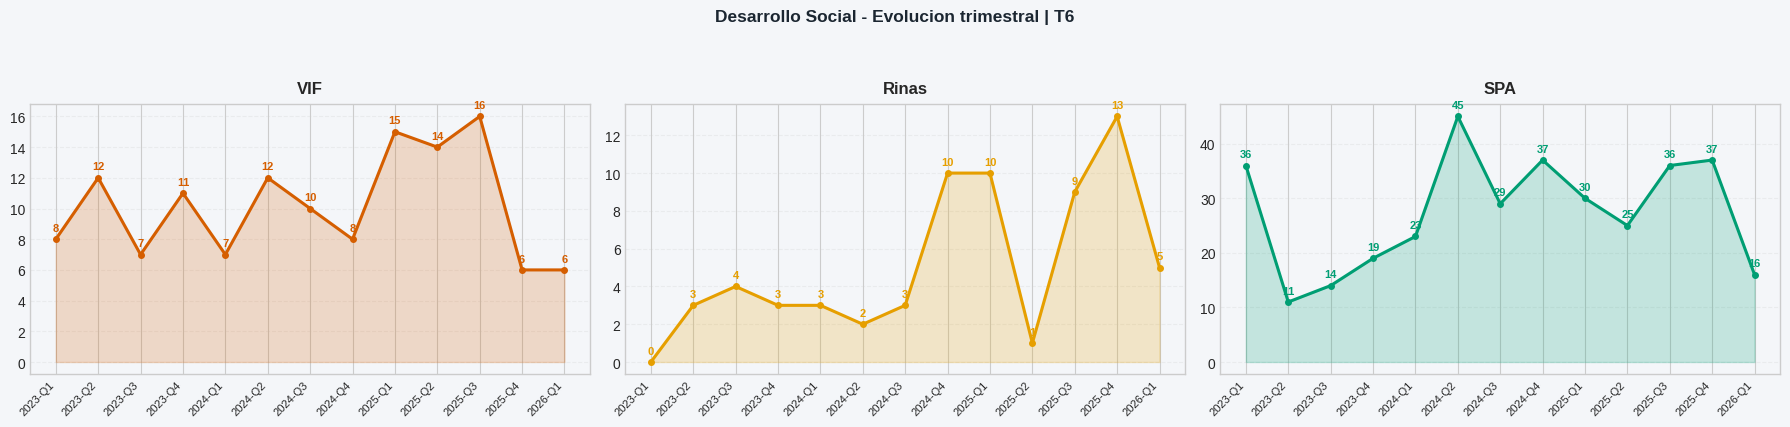

/tmp/ipykernel_33488/1599129436.py:88: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '8' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  annot.loc[label] = heat.loc[label].apply(lambda v: fmt_compacto(v, modes.get(label, 'int')))
/tmp/ipykernel_33488/1599129436.py:88: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '12' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  annot.loc[label] = heat.loc[label].apply(lambda v: fmt_compacto(v, modes.get(label, 'int')))
/tmp/ipykernel_33488/1599129436.py:88: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '7' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  annot.loc[label] = heat.loc

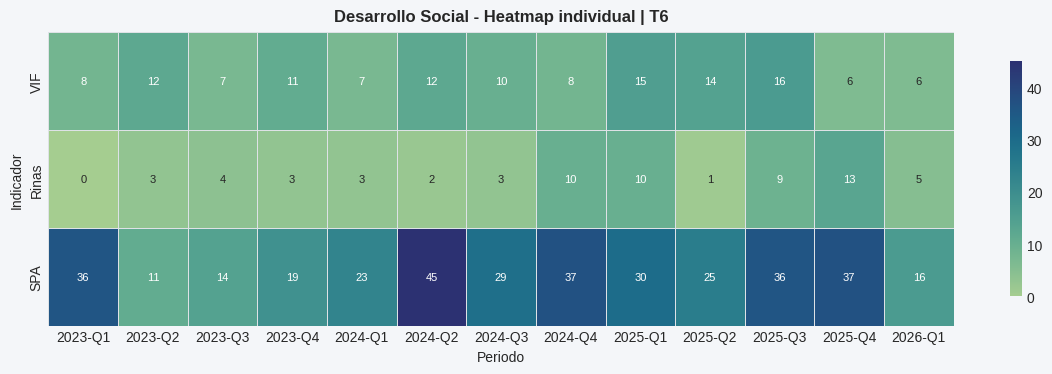

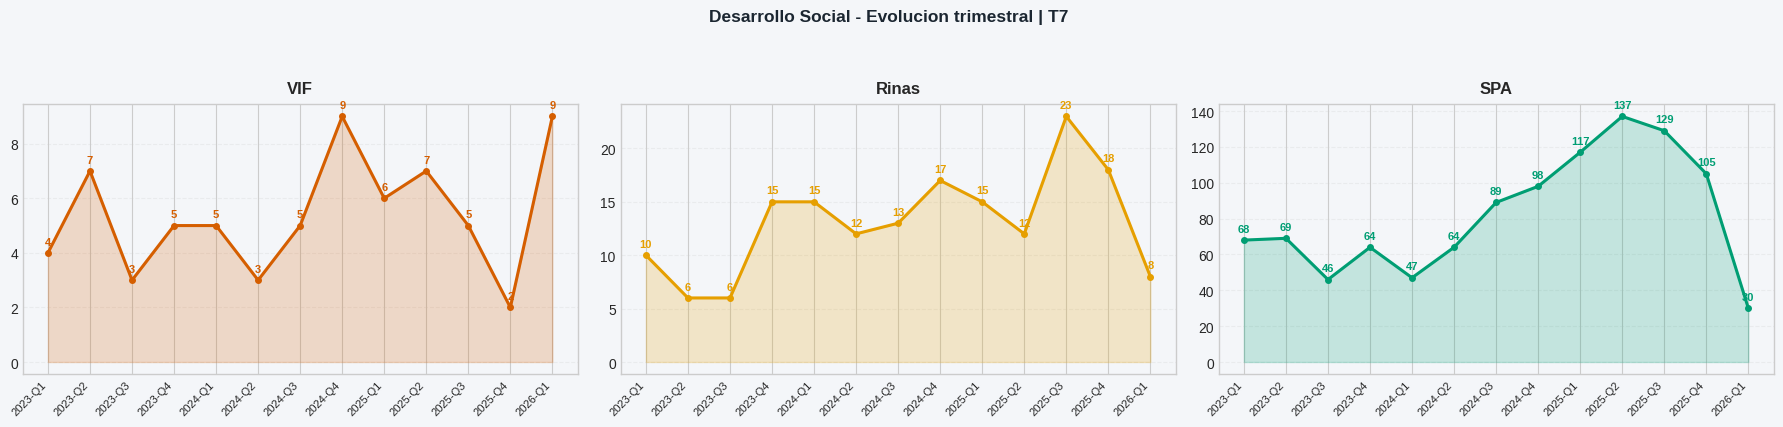

/tmp/ipykernel_33488/1599129436.py:88: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '4' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  annot.loc[label] = heat.loc[label].apply(lambda v: fmt_compacto(v, modes.get(label, 'int')))
/tmp/ipykernel_33488/1599129436.py:88: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '7' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  annot.loc[label] = heat.loc[label].apply(lambda v: fmt_compacto(v, modes.get(label, 'int')))
/tmp/ipykernel_33488/1599129436.py:88: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '3' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  annot.loc[label] = heat.loc[

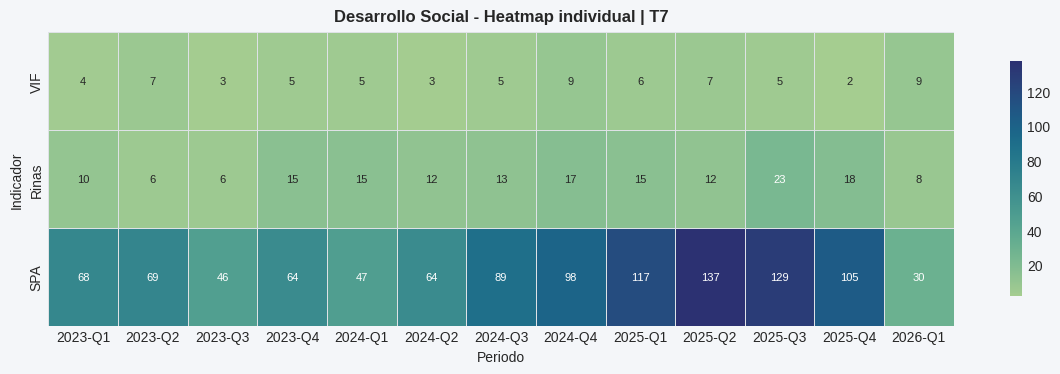

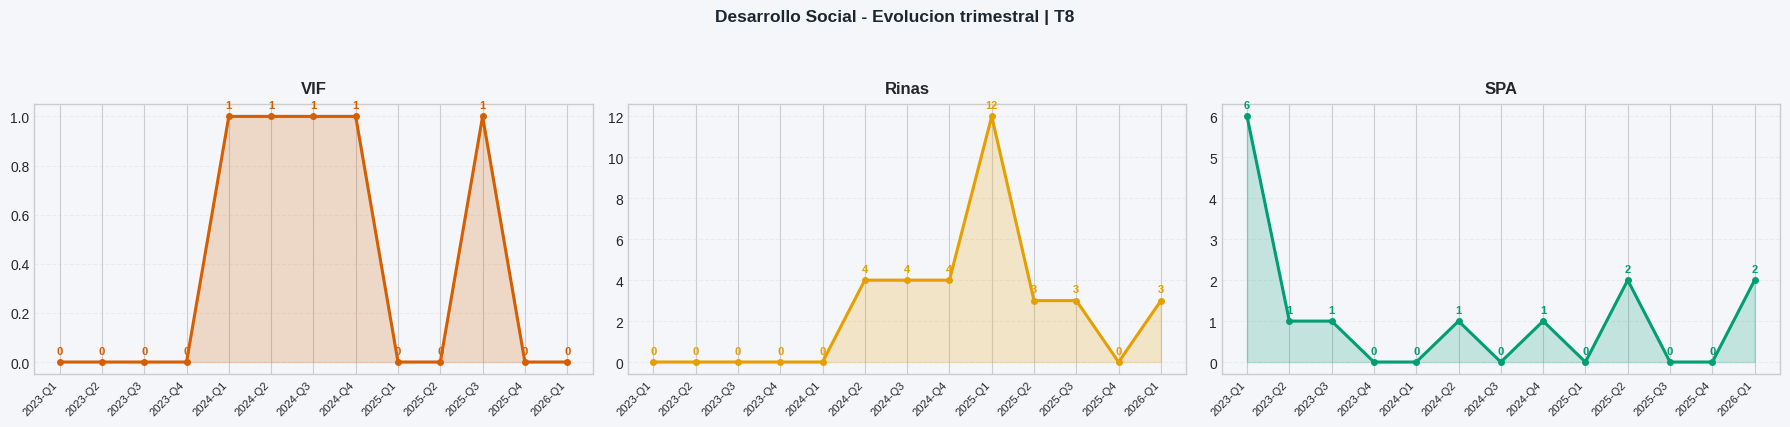

/tmp/ipykernel_33488/1599129436.py:88: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  annot.loc[label] = heat.loc[label].apply(lambda v: fmt_compacto(v, modes.get(label, 'int')))
/tmp/ipykernel_33488/1599129436.py:88: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  annot.loc[label] = heat.loc[label].apply(lambda v: fmt_compacto(v, modes.get(label, 'int')))
/tmp/ipykernel_33488/1599129436.py:88: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  annot.loc[label] = heat.loc[

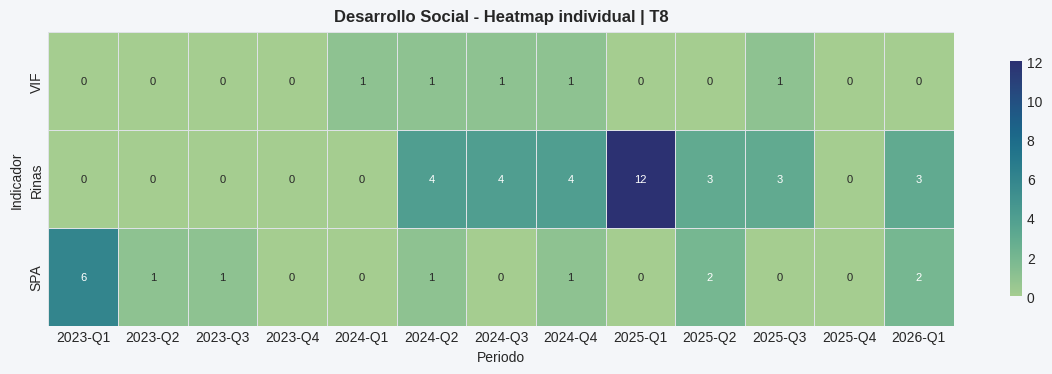

In [11]:
plot_general_trim(
    df_social_trim,
    [('vif', 'VIF', OKI_BERMELL),
     ('rinas', 'Rinas', OKI_NARANJA),
     ('spa', 'SPA', OKI_VERDE)],
    'Desarrollo Social - Evolucion trimestral general | Avenida Ciudad de Cali',
    'acc_social_general_trim.png'
)

plot_heatmaps_tramo_period(
    df_social_trim,
    [('vif', 'VIF', CMAP_CALIDO, 'int'),
     ('rinas', 'Rinas', CMAP_NEUTRO, 'int'),
     ('spa', 'SPA', CMAP_FRIO, 'int')],
    'Desarrollo Social - Heatmap por tramo y trimestre | Avenida Ciudad de Cali',
    'acc_social_heatmap_tramo_periodo.png'
)

for tramo in TRAMOS:
    plot_per_tramo_trim(
        df_social_trim, tramo,
        [('vif', 'VIF', OKI_BERMELL),
         ('rinas', 'Rinas', OKI_NARANJA),
         ('spa', 'SPA', OKI_VERDE)],
        'Desarrollo Social - Evolucion trimestral',
        f'acc_social_trim_{tramo}.png'
    )
    plot_per_tramo_trim_heatmap(
        df_social_trim, tramo,
        [('vif', 'VIF', 'int'),
         ('rinas', 'Rinas', 'int'),
         ('spa', 'SPA', 'int')],
        'Desarrollo Social - Heatmap individual',
        f'acc_social_heatmap_{tramo}.png'
    )


## Entorno Urbano


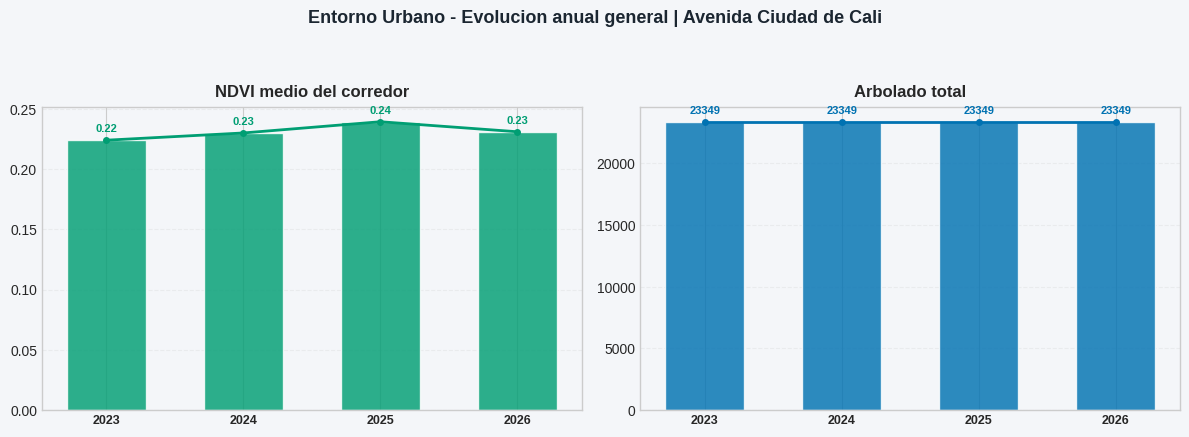

/tmp/ipykernel_33488/1596642247.py:133: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return pivot.applymap(lambda v: fmt_compacto(v, mode))
/tmp/ipykernel_33488/1596642247.py:133: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return pivot.applymap(lambda v: fmt_compacto(v, mode))


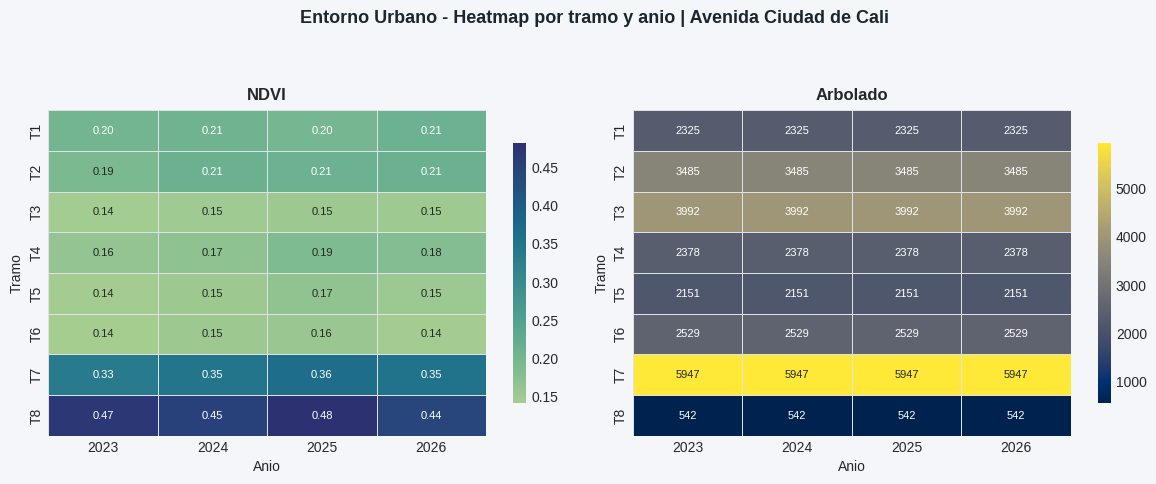

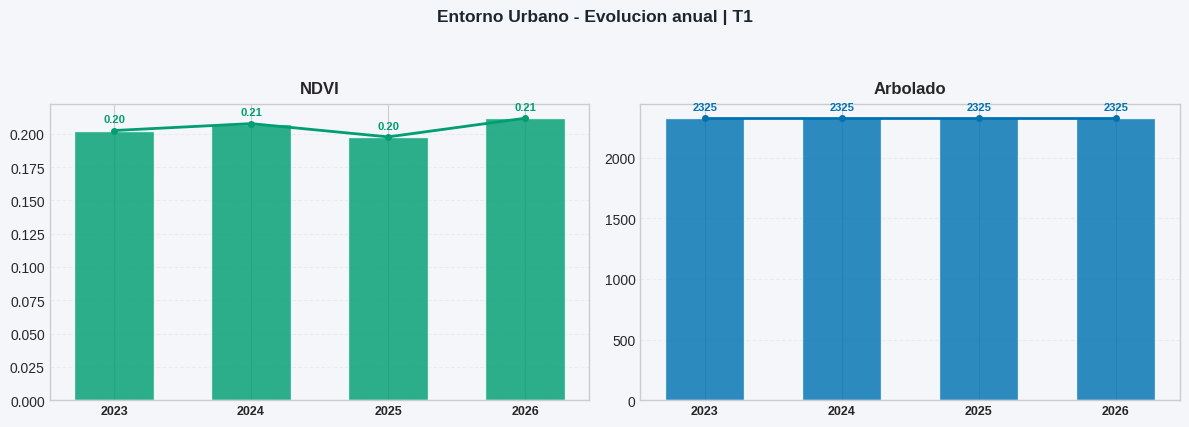

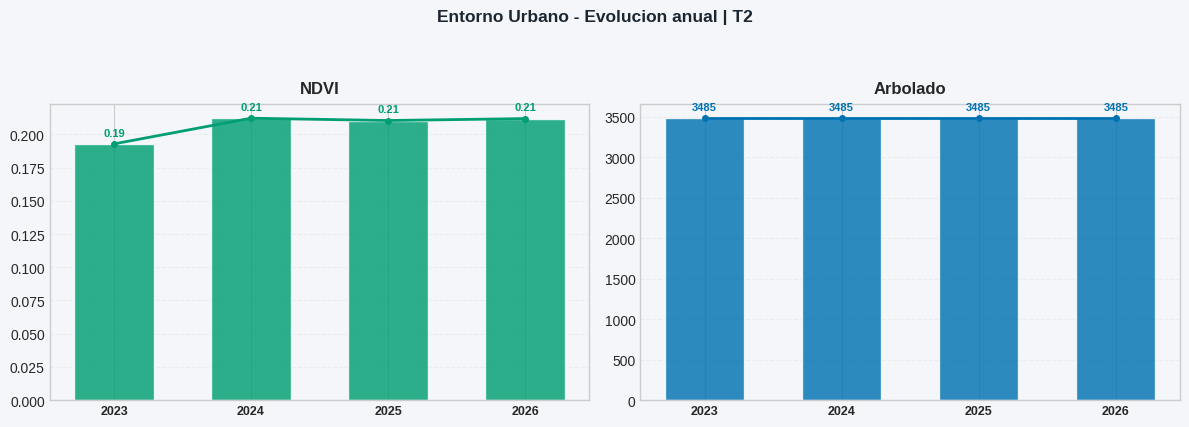

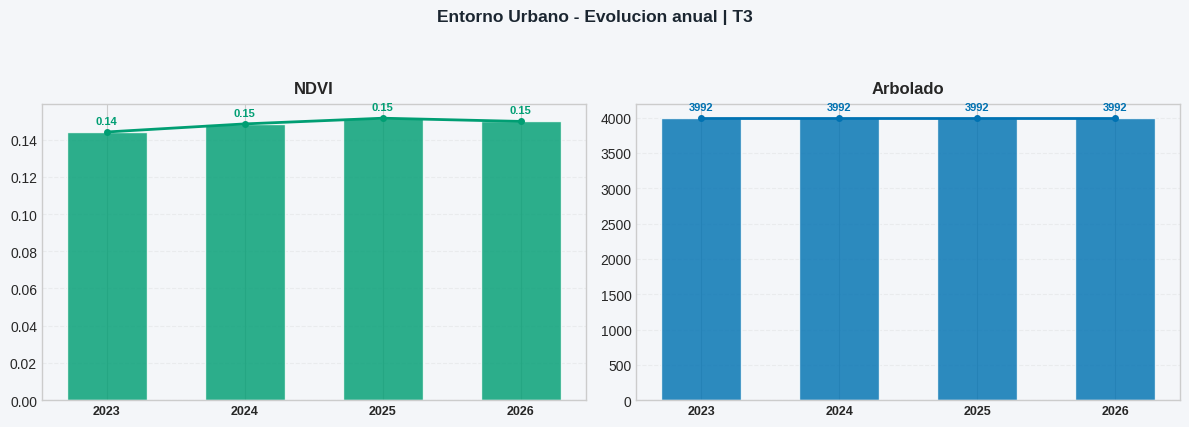

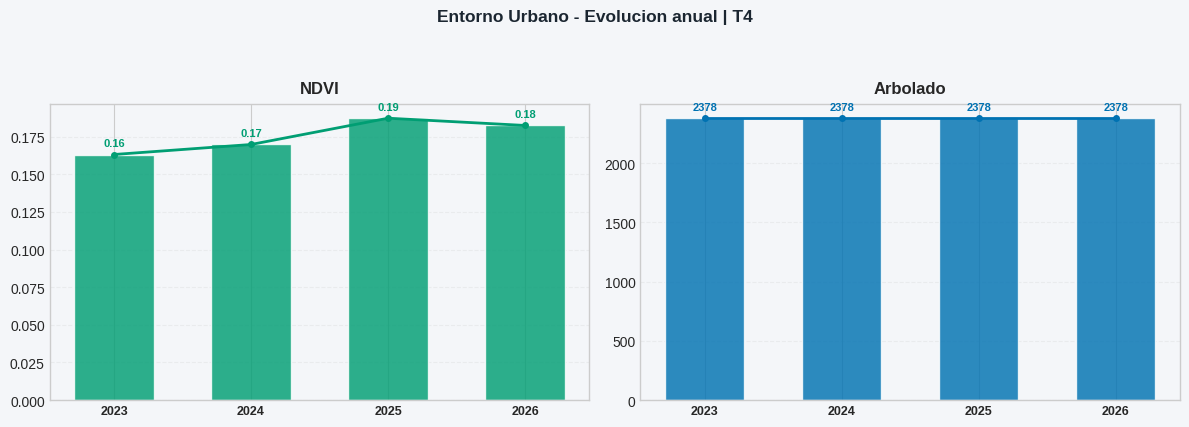

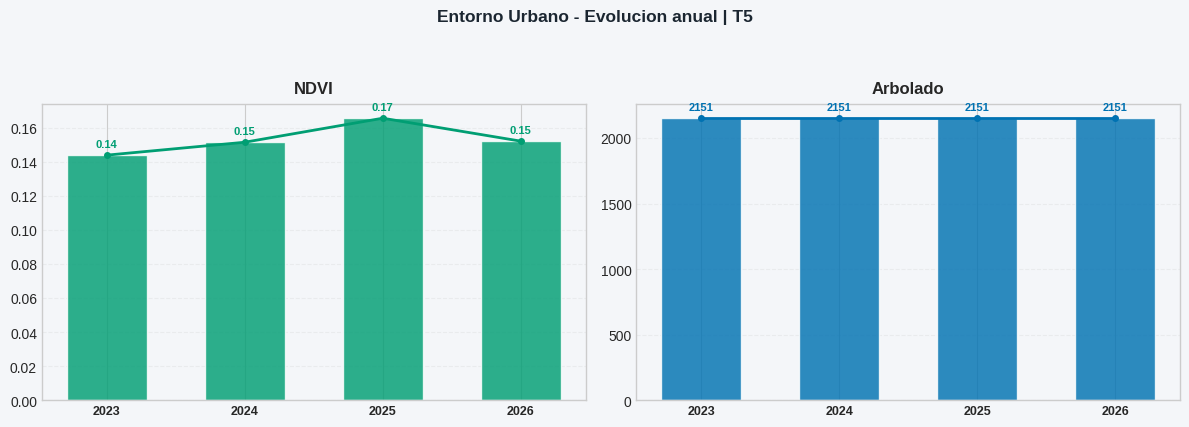

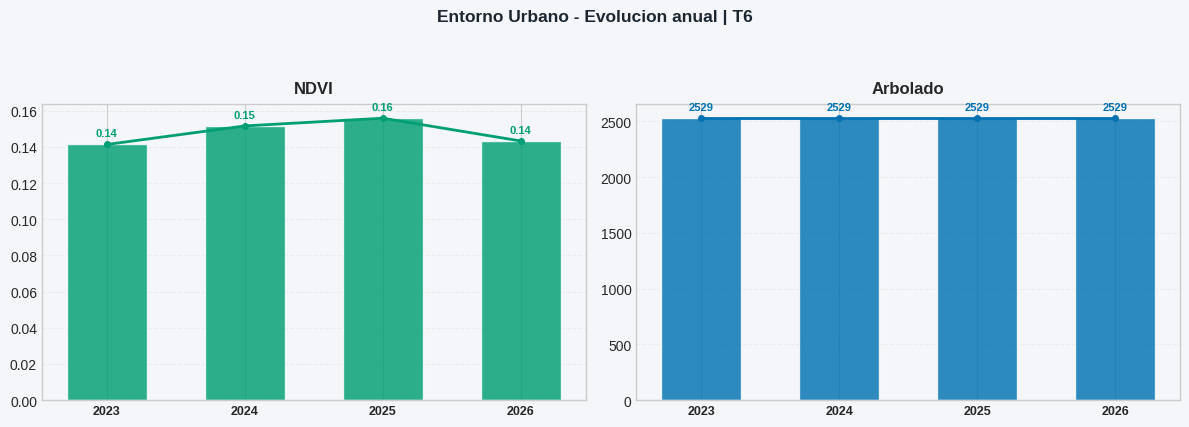

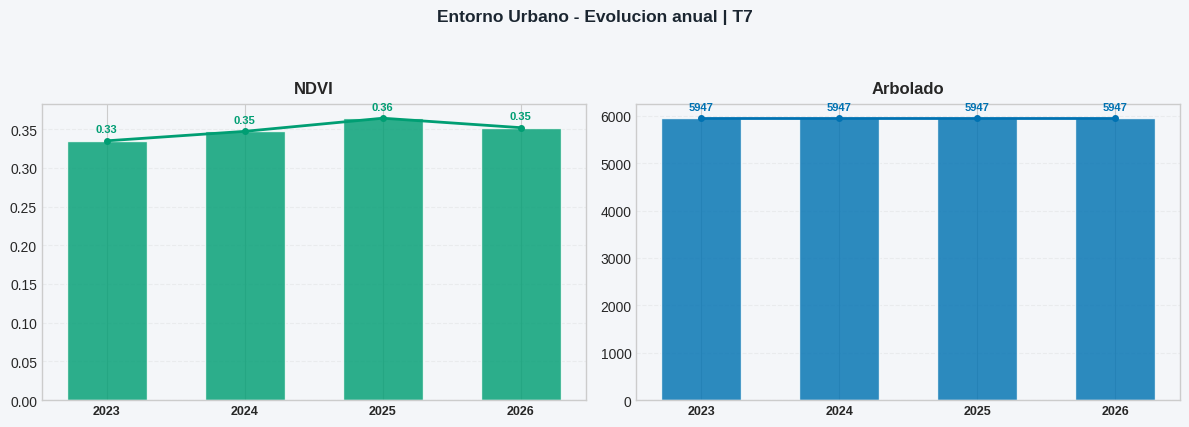

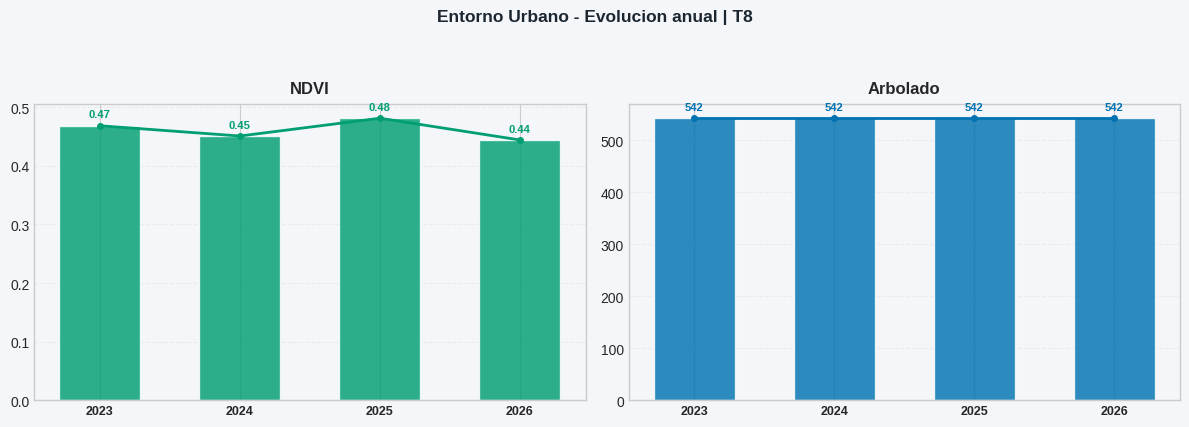

In [12]:
plot_general_annual(
    df_entorno_ann.groupby('anio', dropna=False).agg({'ndvi':'mean', 'arbolado_total':'sum'}).reset_index(),
    [('ndvi', 'NDVI medio del corredor', OKI_VERDE, None),
     ('arbolado_total', 'Arbolado total', OKI_AZUL, None)],
    'Entorno Urbano - Evolucion anual general | Avenida Ciudad de Cali',
    'acc_entorno_general_anual.png'
)

plot_heatmaps_tramo_year(
    df_entorno_ann,
    [('ndvi', 'NDVI', CMAP_FRIO, 'float2'),
     ('arbolado_total', 'Arbolado', CMAP_NEUTRO, 'int')],
    'Entorno Urbano - Heatmap por tramo y anio | Avenida Ciudad de Cali',
    'acc_entorno_heatmap_tramo_anio.png'
)

for tramo in TRAMOS:
    plot_per_tramo_annual(
        df_entorno_ann, tramo,
        [('ndvi', 'NDVI', OKI_VERDE, None),
         ('arbolado_total', 'Arbolado', OKI_AZUL, None)],
        'Entorno Urbano - Evolucion anual',
        f'acc_entorno_anual_{tramo}.png'
    )


## Actividad Economica

Se muestran dos lecturas:

1. **Oficial para ITT:** stock/proxy de `establecimientos activos`, `empleabilidad total` e `ingresos operacionales`.
2. **Complementaria:** `creacion de negocios nuevos` por fecha de matricula.


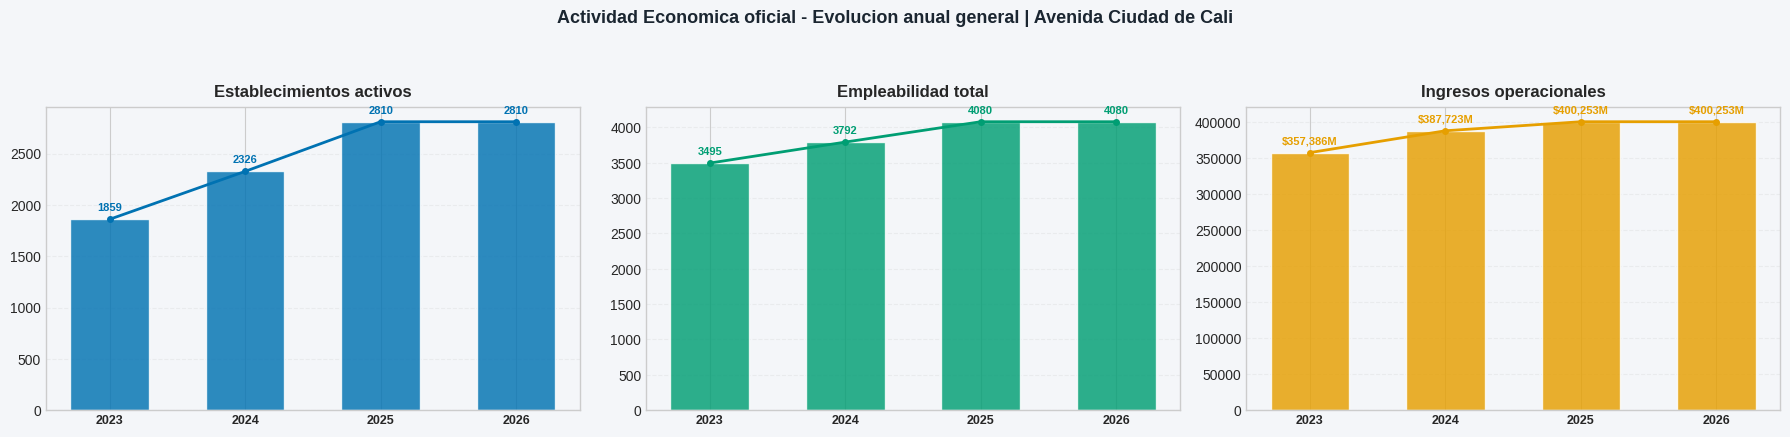

/tmp/ipykernel_33488/1596642247.py:133: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return pivot.applymap(lambda v: fmt_compacto(v, mode))
/tmp/ipykernel_33488/1596642247.py:133: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return pivot.applymap(lambda v: fmt_compacto(v, mode))
/tmp/ipykernel_33488/1596642247.py:133: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return pivot.applymap(lambda v: fmt_compacto(v, mode))


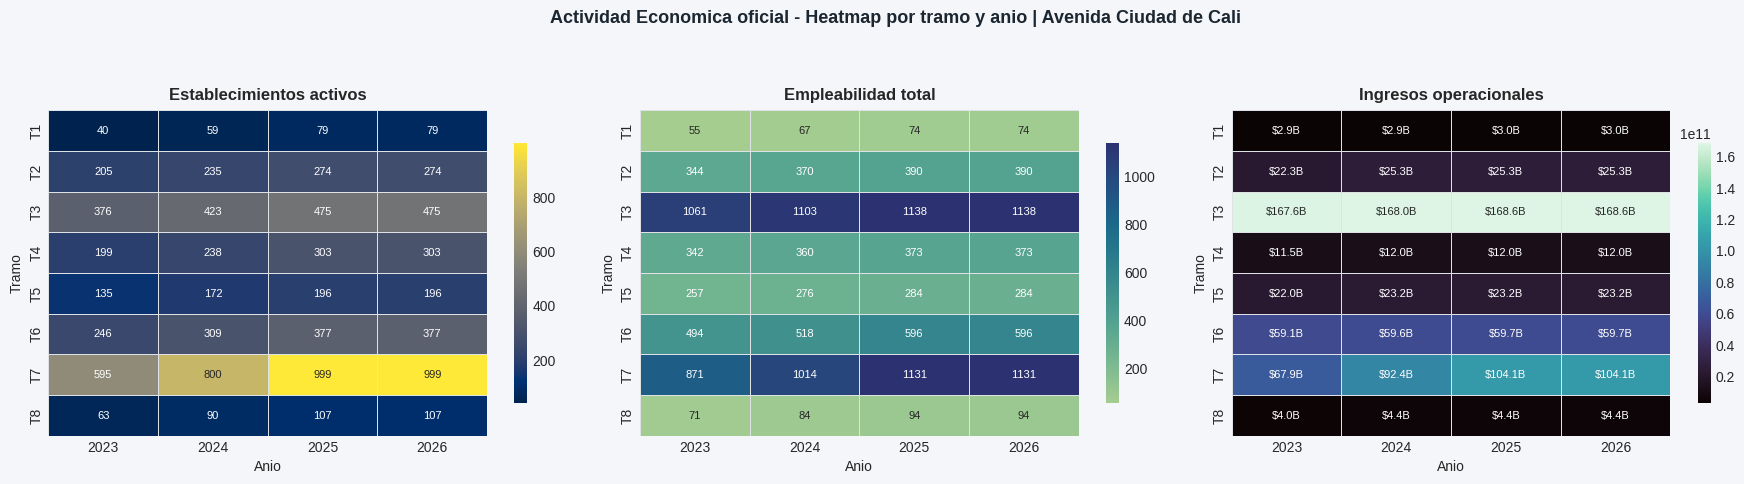

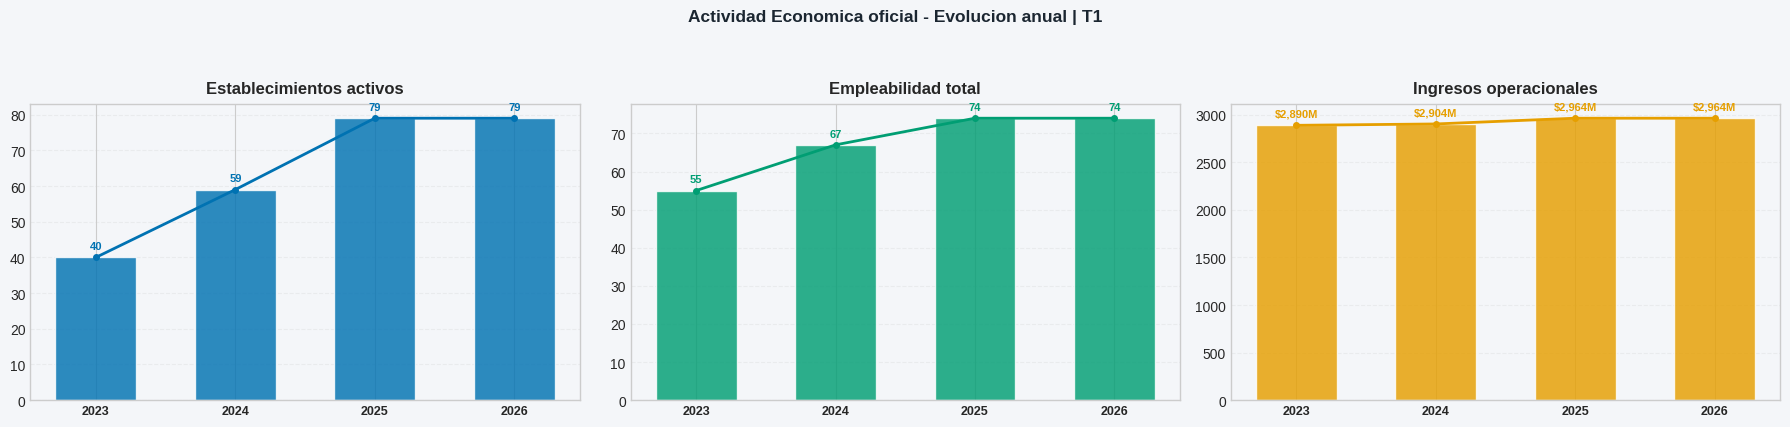

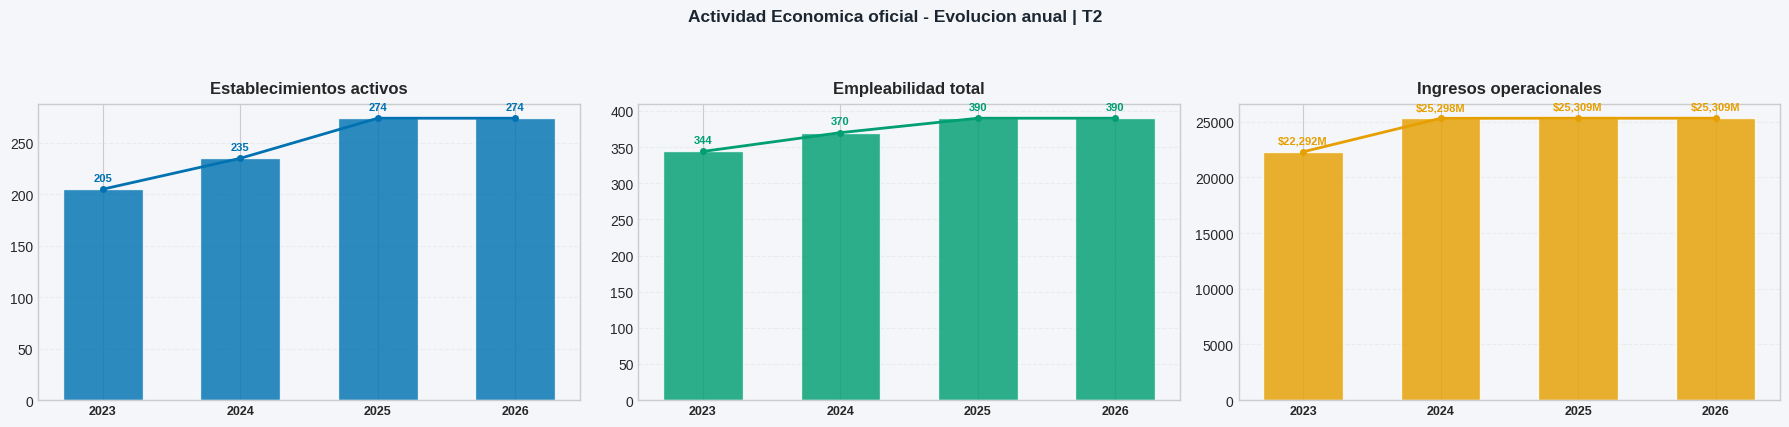

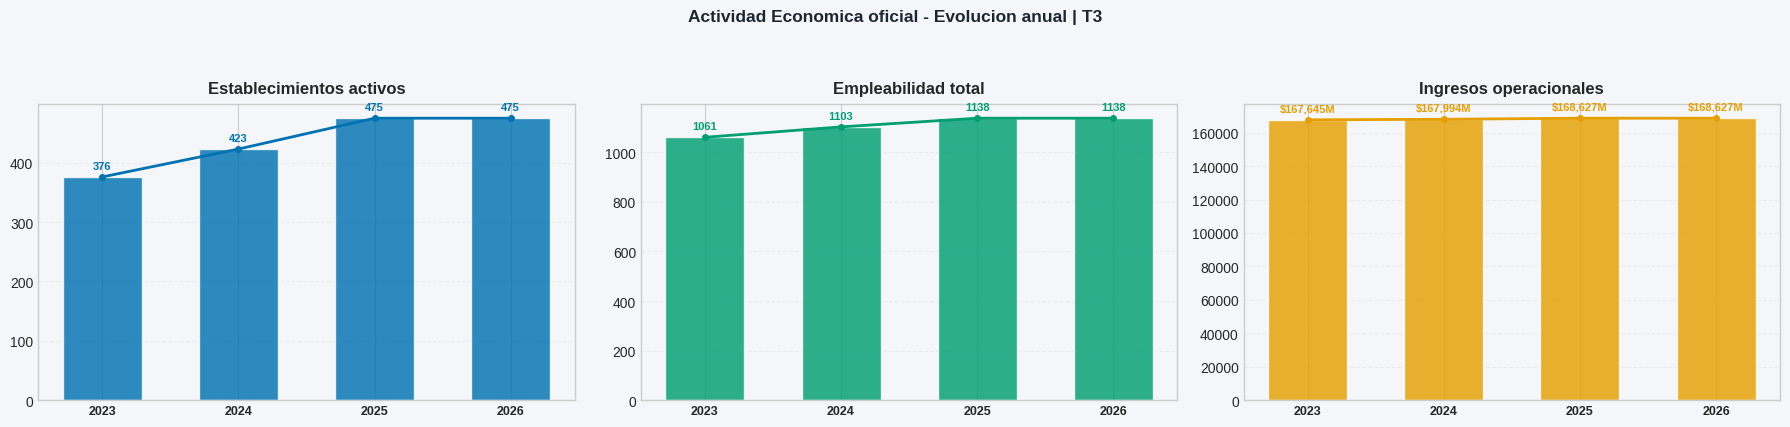

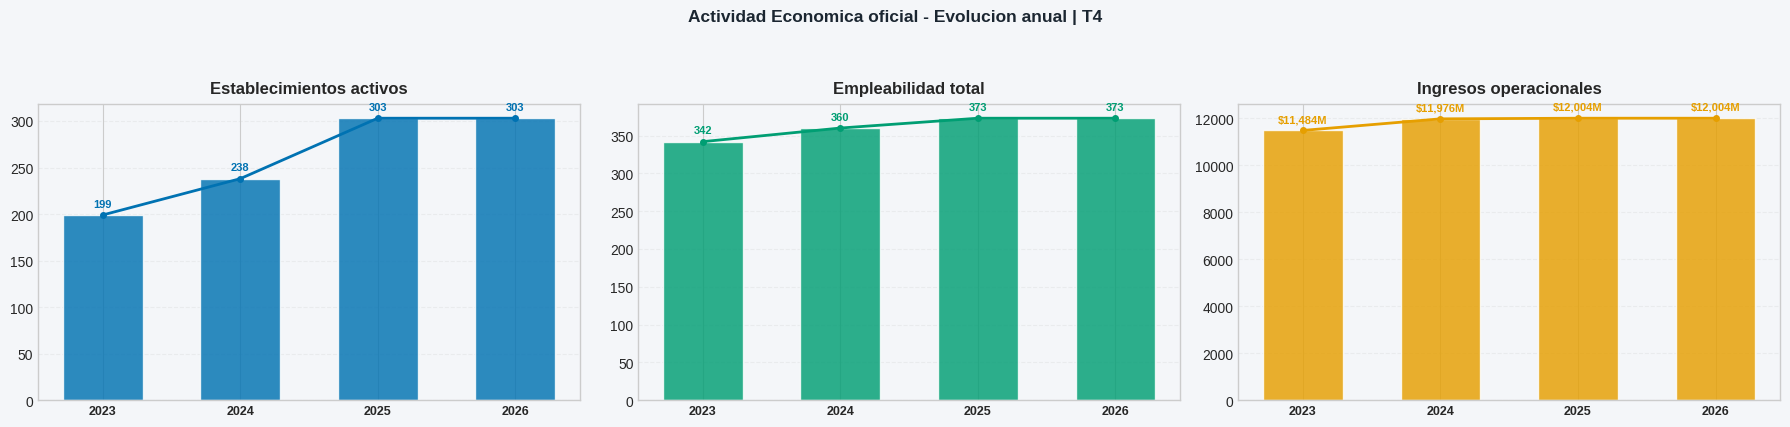

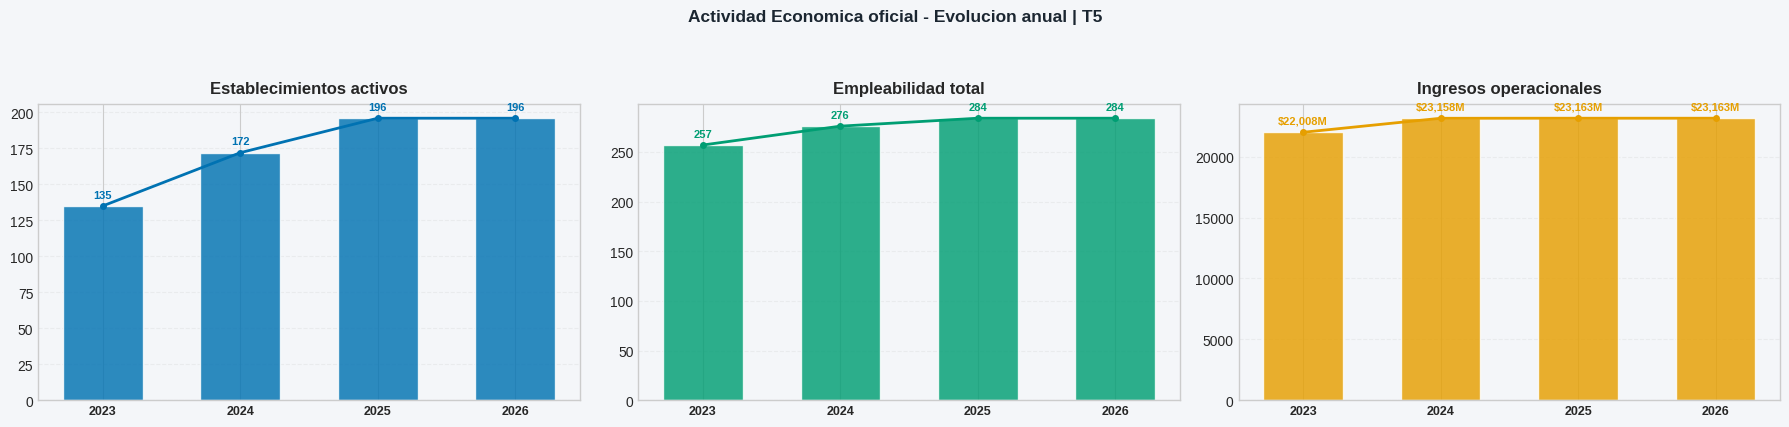

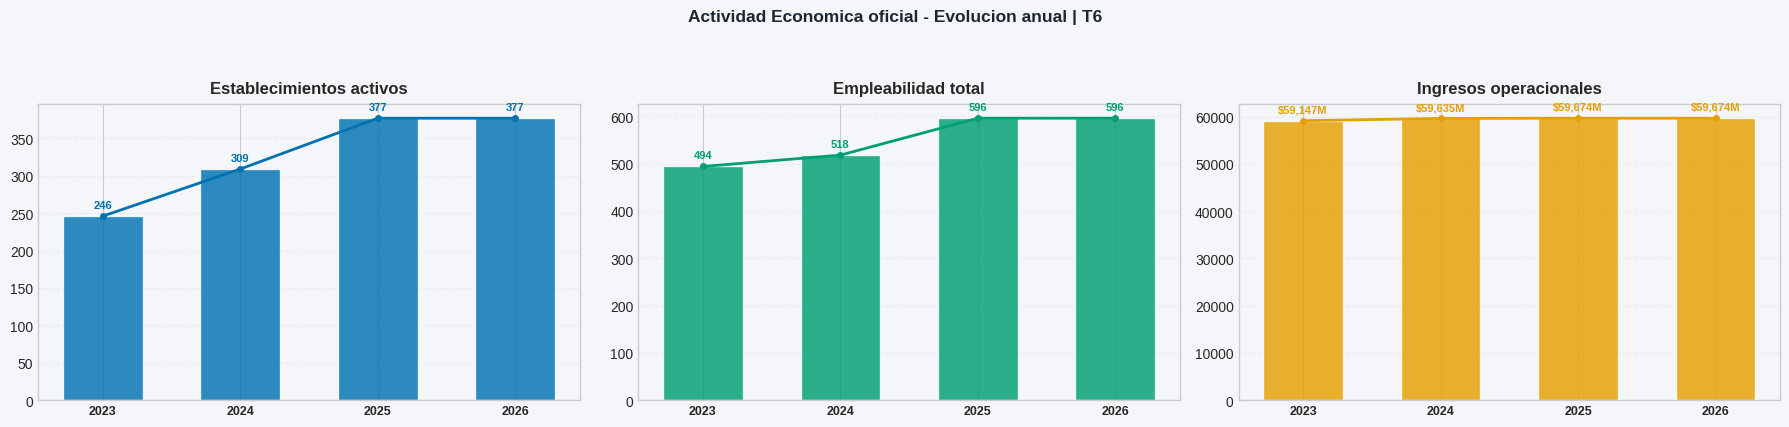

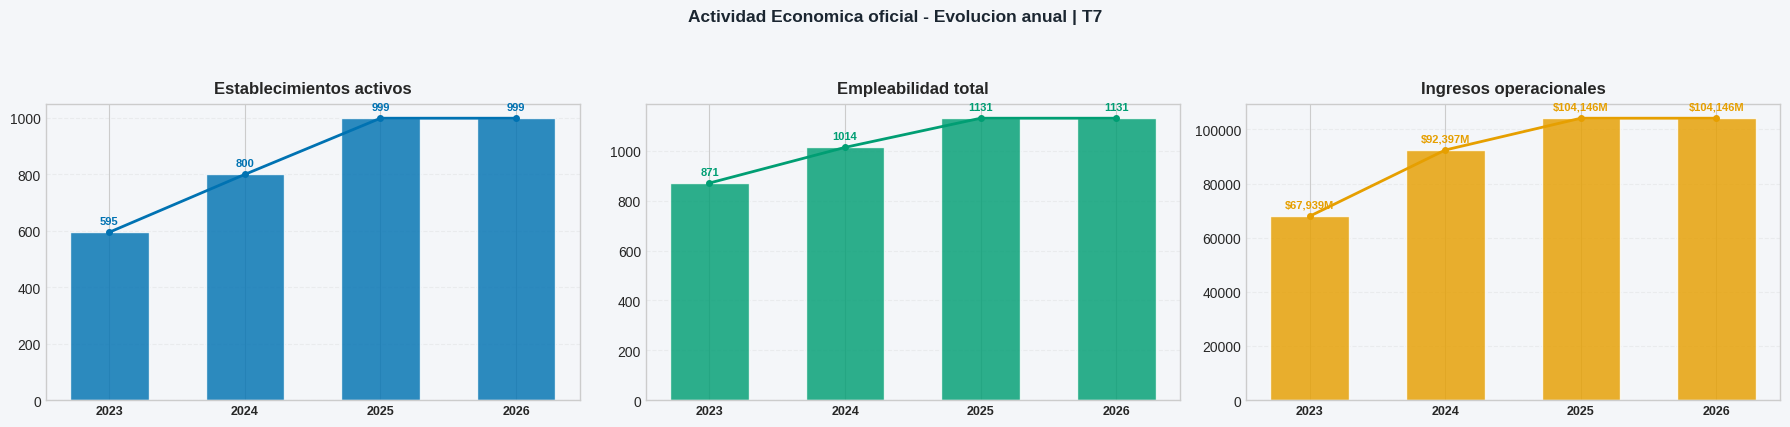

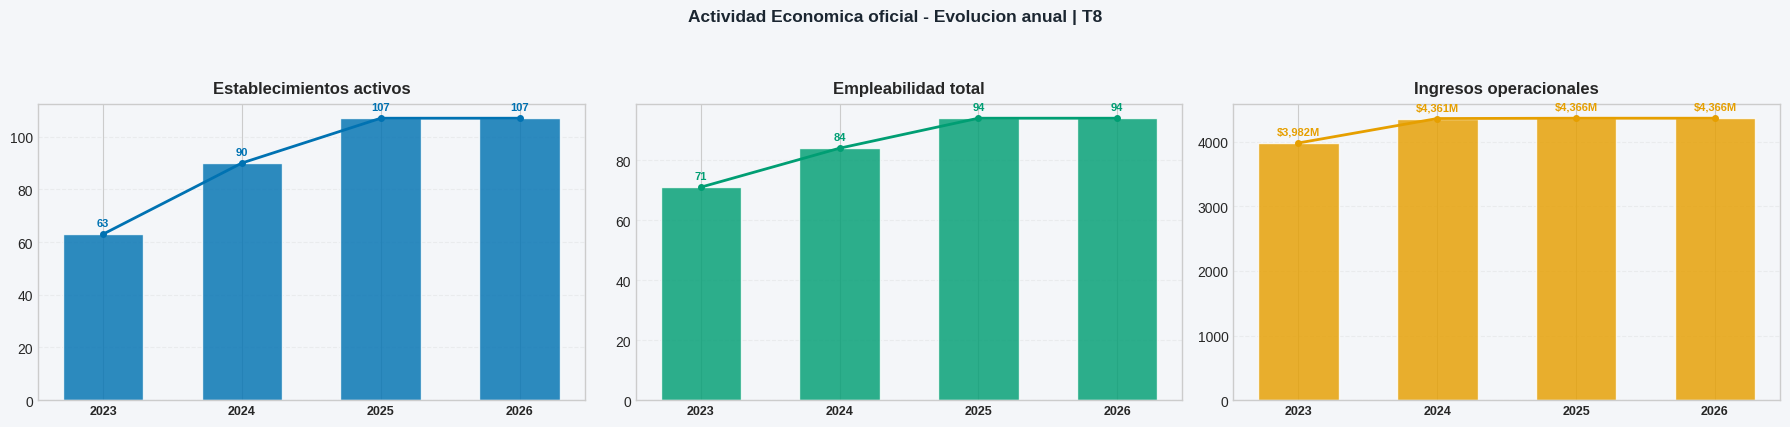

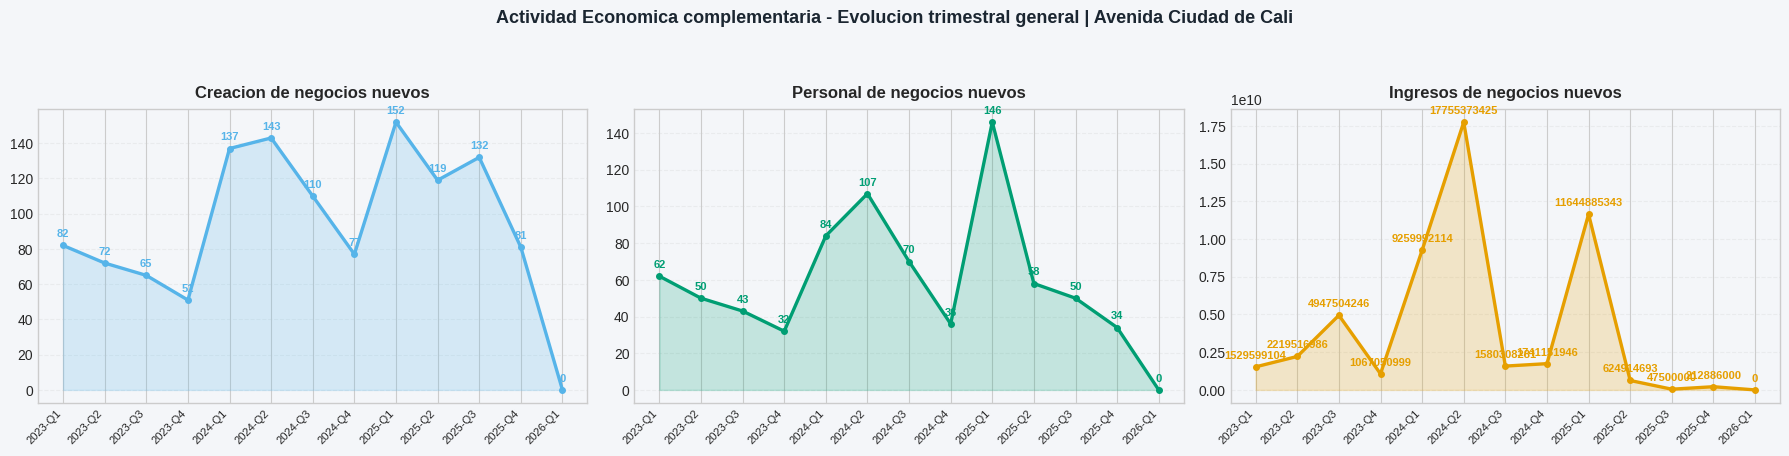

/tmp/ipykernel_33488/1596642247.py:133: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return pivot.applymap(lambda v: fmt_compacto(v, mode))
/tmp/ipykernel_33488/1596642247.py:133: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return pivot.applymap(lambda v: fmt_compacto(v, mode))
/tmp/ipykernel_33488/1596642247.py:133: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return pivot.applymap(lambda v: fmt_compacto(v, mode))


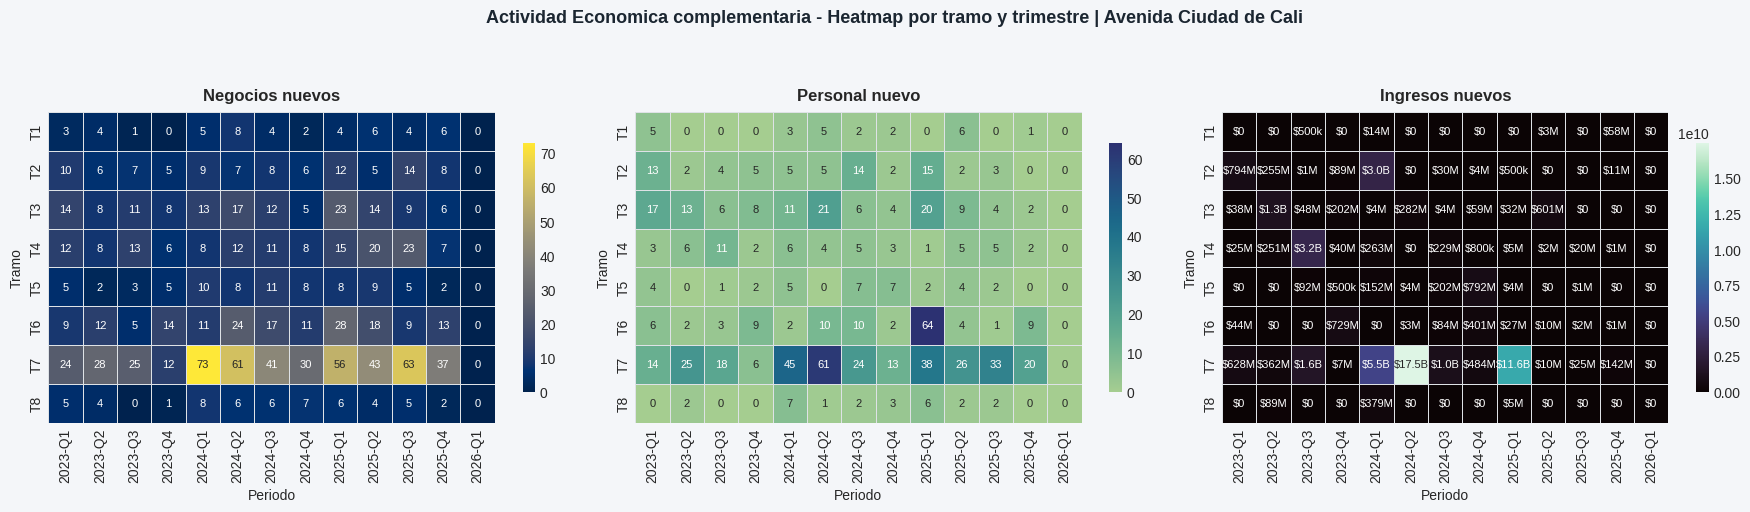

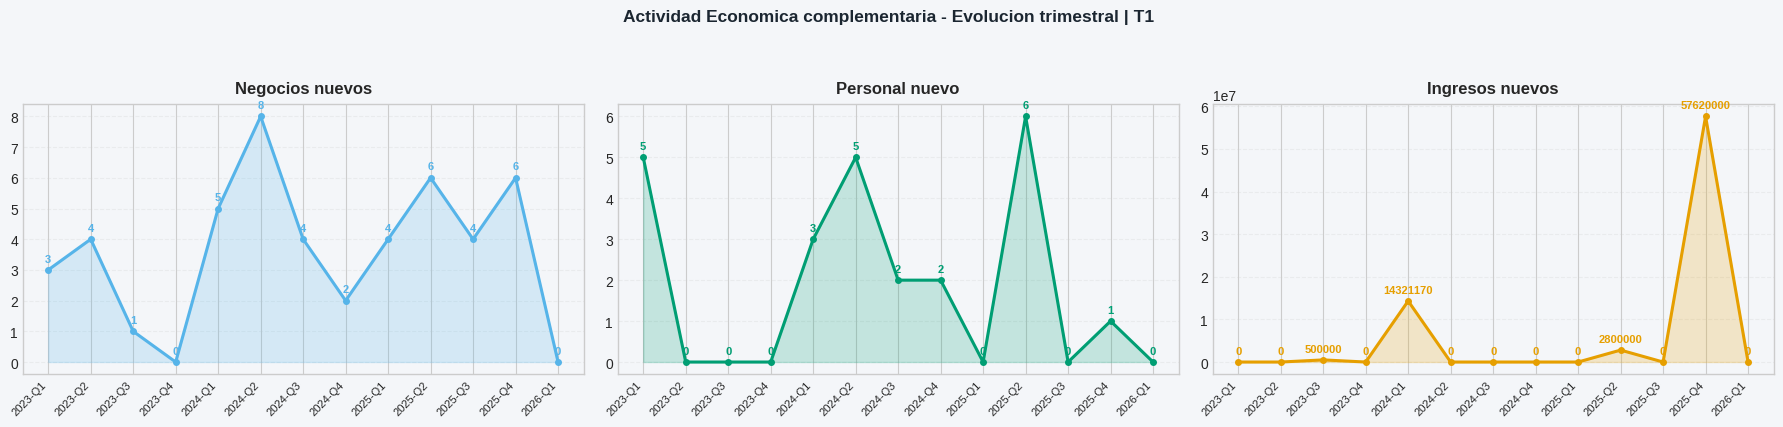

/tmp/ipykernel_33488/1599129436.py:88: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '3' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  annot.loc[label] = heat.loc[label].apply(lambda v: fmt_compacto(v, modes.get(label, 'int')))
/tmp/ipykernel_33488/1599129436.py:88: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '4' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  annot.loc[label] = heat.loc[label].apply(lambda v: fmt_compacto(v, modes.get(label, 'int')))
/tmp/ipykernel_33488/1599129436.py:88: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  annot.loc[label] = heat.loc[

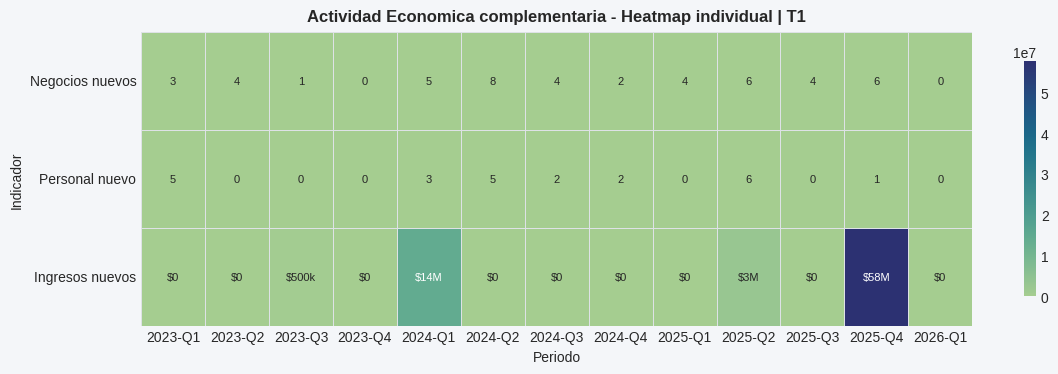

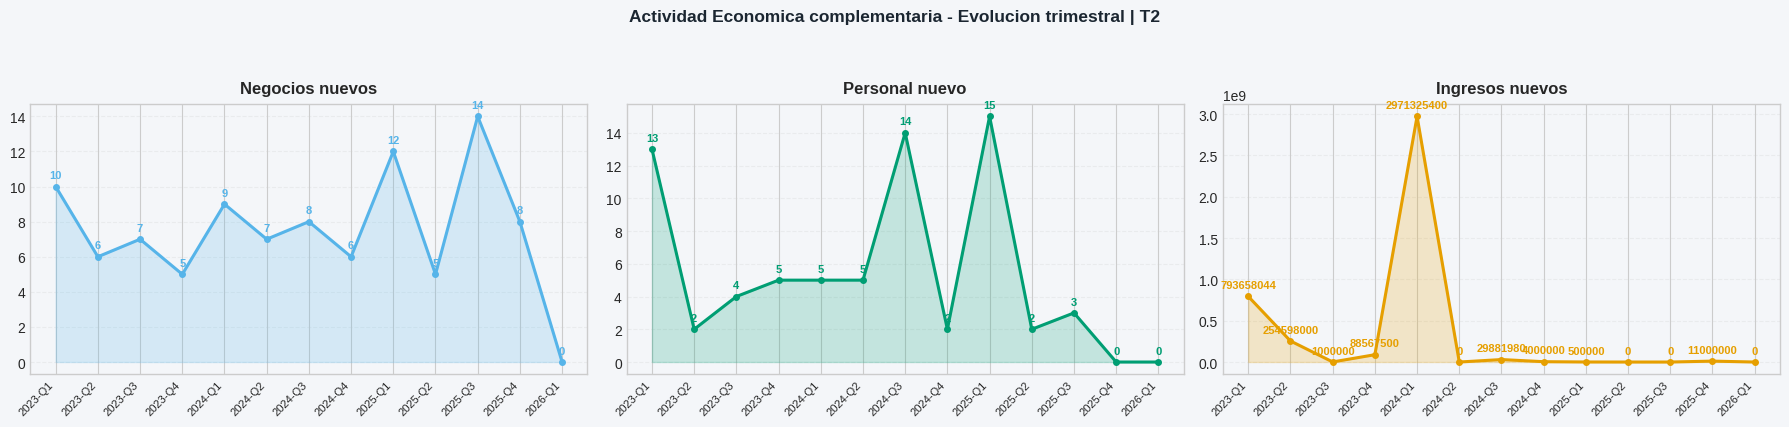

/tmp/ipykernel_33488/1599129436.py:88: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '10' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  annot.loc[label] = heat.loc[label].apply(lambda v: fmt_compacto(v, modes.get(label, 'int')))
/tmp/ipykernel_33488/1599129436.py:88: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '6' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  annot.loc[label] = heat.loc[label].apply(lambda v: fmt_compacto(v, modes.get(label, 'int')))
/tmp/ipykernel_33488/1599129436.py:88: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '7' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  annot.loc[label] = heat.loc

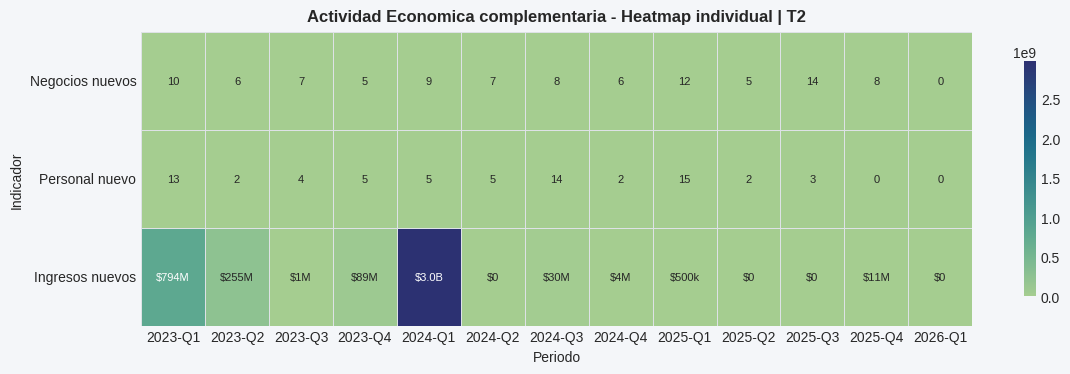

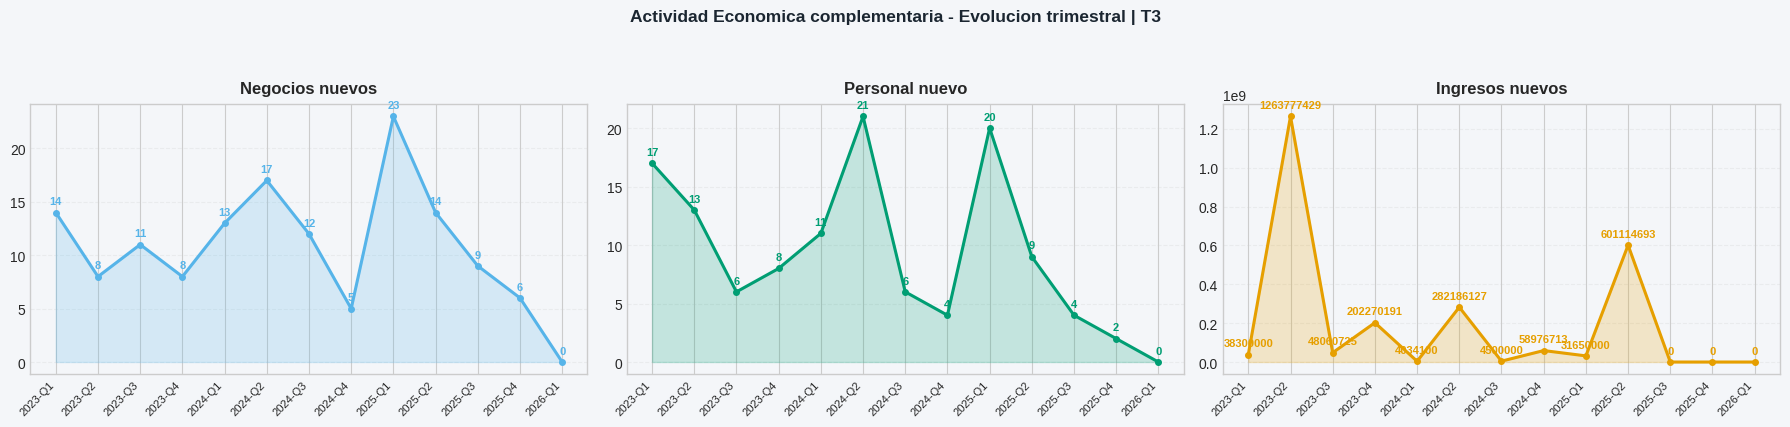

/tmp/ipykernel_33488/1599129436.py:88: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '14' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  annot.loc[label] = heat.loc[label].apply(lambda v: fmt_compacto(v, modes.get(label, 'int')))
/tmp/ipykernel_33488/1599129436.py:88: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '8' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  annot.loc[label] = heat.loc[label].apply(lambda v: fmt_compacto(v, modes.get(label, 'int')))
/tmp/ipykernel_33488/1599129436.py:88: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '11' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  annot.loc[label] = heat.lo

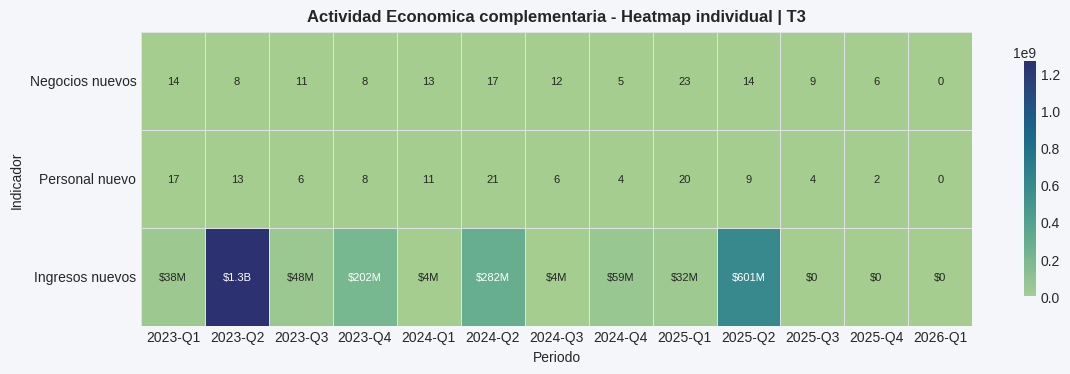

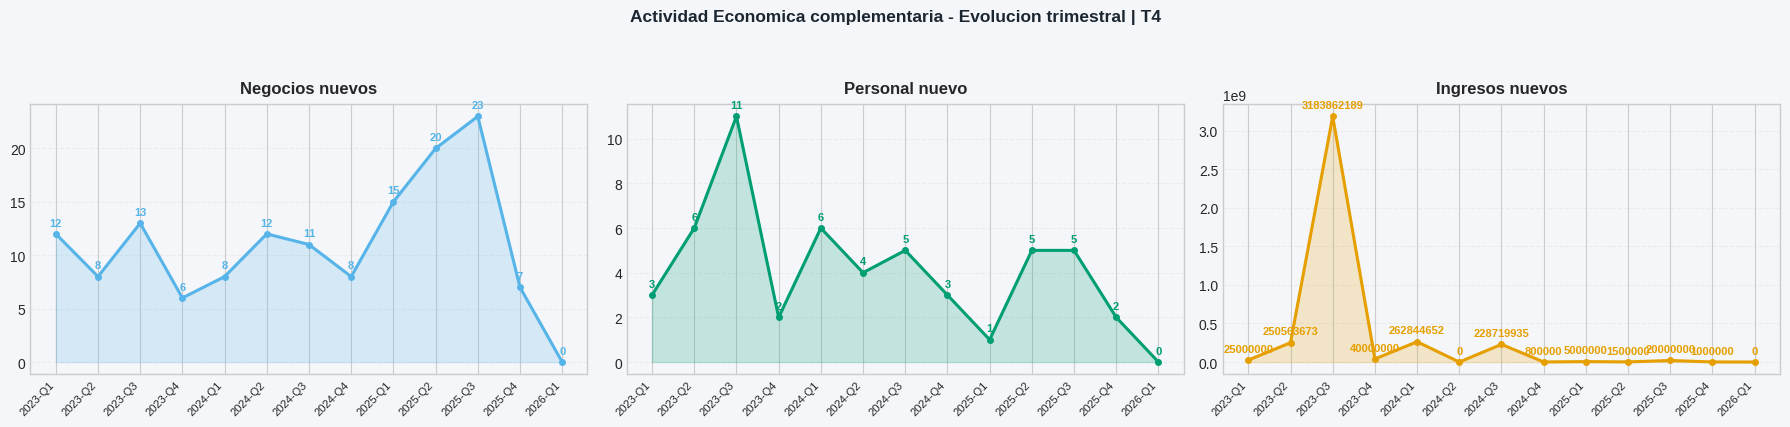

/tmp/ipykernel_33488/1599129436.py:88: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '12' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  annot.loc[label] = heat.loc[label].apply(lambda v: fmt_compacto(v, modes.get(label, 'int')))
/tmp/ipykernel_33488/1599129436.py:88: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '8' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  annot.loc[label] = heat.loc[label].apply(lambda v: fmt_compacto(v, modes.get(label, 'int')))
/tmp/ipykernel_33488/1599129436.py:88: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '13' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  annot.loc[label] = heat.lo

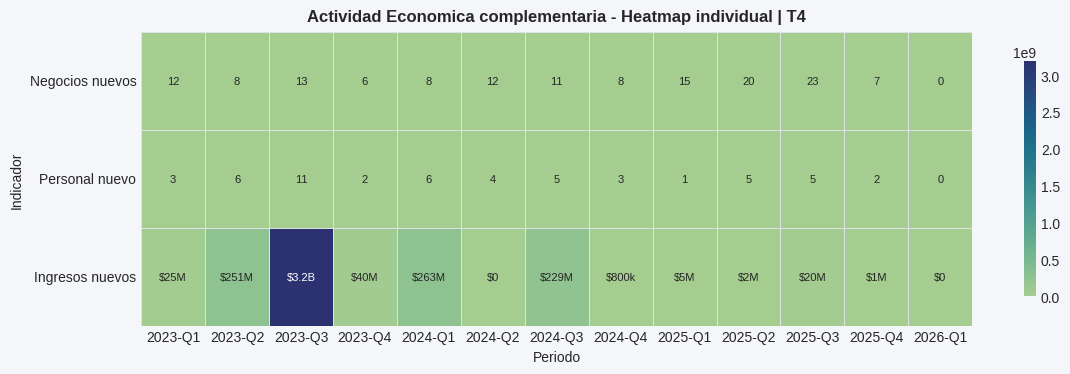

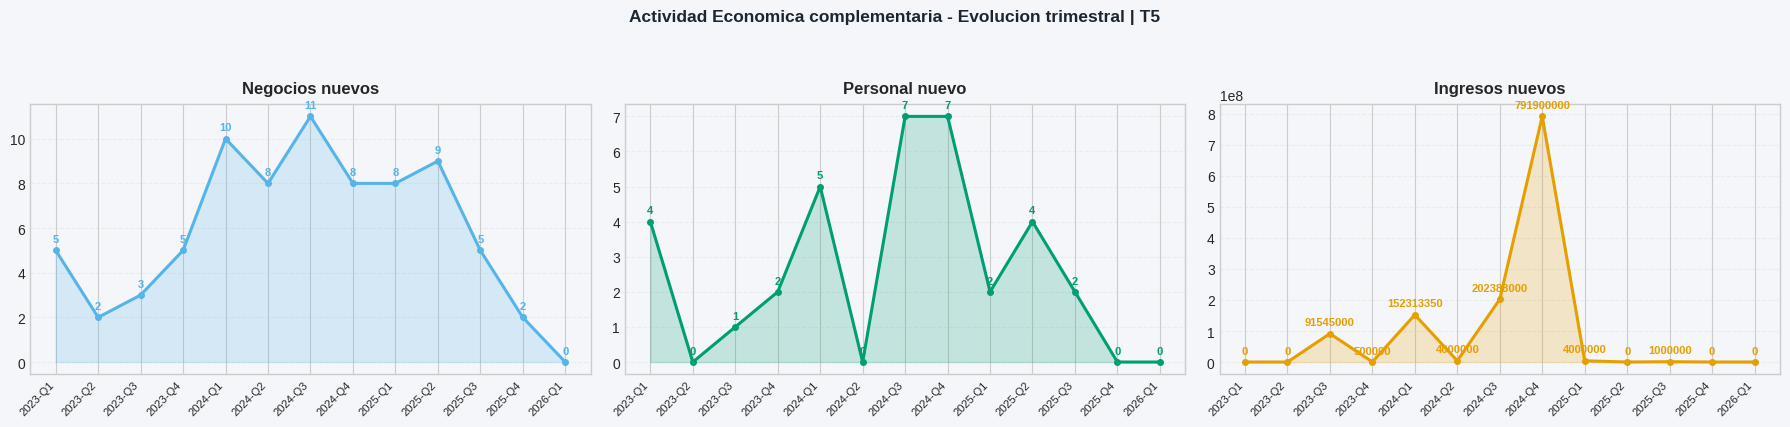

/tmp/ipykernel_33488/1599129436.py:88: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '5' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  annot.loc[label] = heat.loc[label].apply(lambda v: fmt_compacto(v, modes.get(label, 'int')))
/tmp/ipykernel_33488/1599129436.py:88: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '2' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  annot.loc[label] = heat.loc[label].apply(lambda v: fmt_compacto(v, modes.get(label, 'int')))
/tmp/ipykernel_33488/1599129436.py:88: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '3' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  annot.loc[label] = heat.loc[

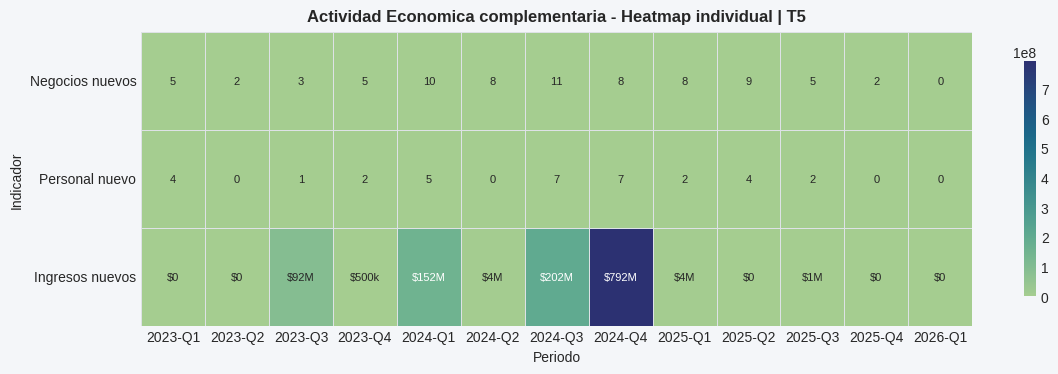

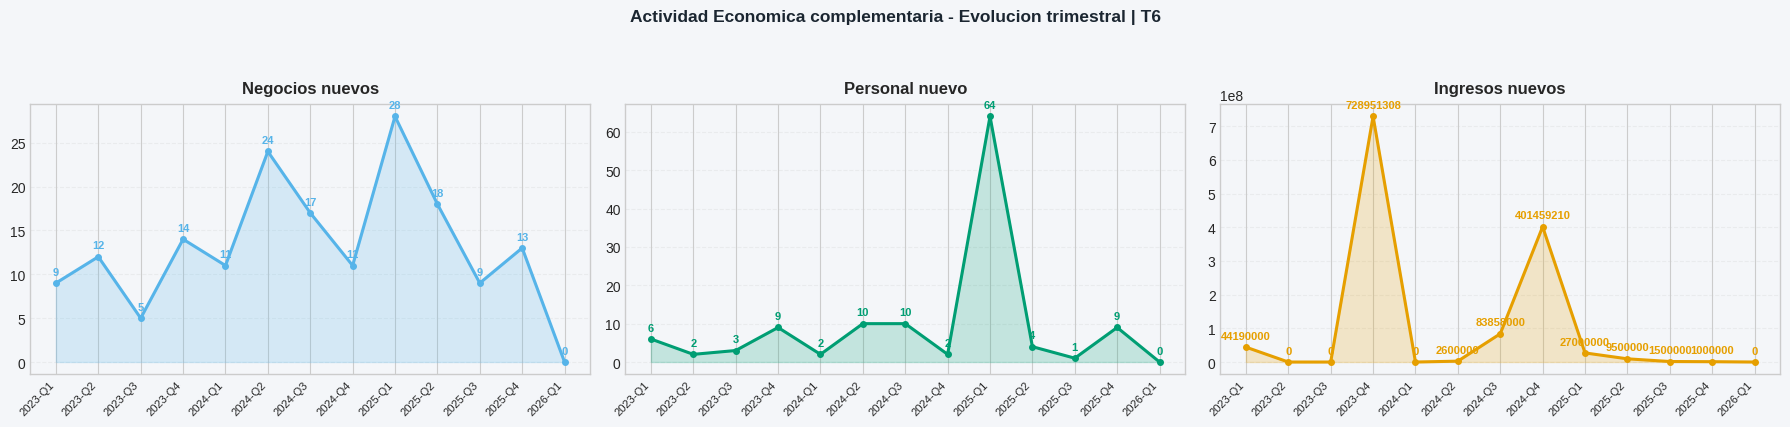

/tmp/ipykernel_33488/1599129436.py:88: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '9' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  annot.loc[label] = heat.loc[label].apply(lambda v: fmt_compacto(v, modes.get(label, 'int')))
/tmp/ipykernel_33488/1599129436.py:88: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '12' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  annot.loc[label] = heat.loc[label].apply(lambda v: fmt_compacto(v, modes.get(label, 'int')))
/tmp/ipykernel_33488/1599129436.py:88: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '5' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  annot.loc[label] = heat.loc

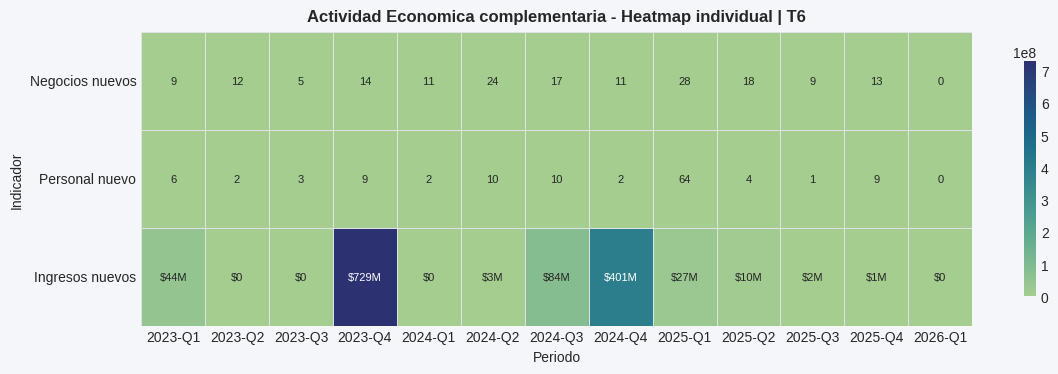

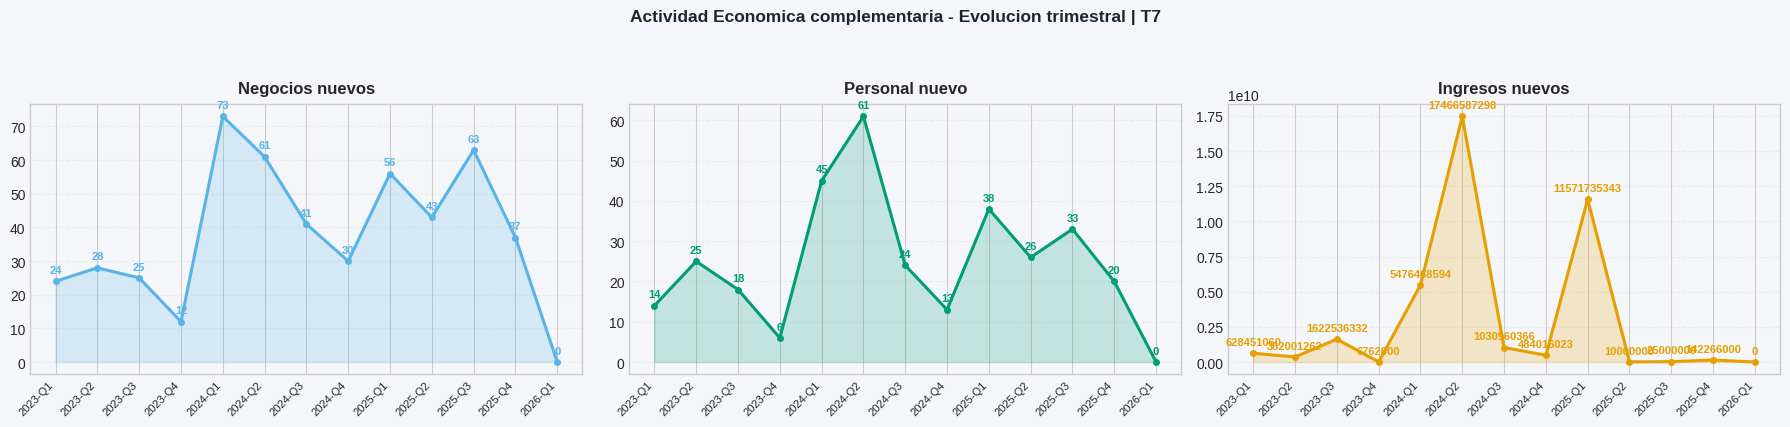

/tmp/ipykernel_33488/1599129436.py:88: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '24' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  annot.loc[label] = heat.loc[label].apply(lambda v: fmt_compacto(v, modes.get(label, 'int')))
/tmp/ipykernel_33488/1599129436.py:88: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '28' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  annot.loc[label] = heat.loc[label].apply(lambda v: fmt_compacto(v, modes.get(label, 'int')))
/tmp/ipykernel_33488/1599129436.py:88: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '25' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  annot.loc[label] = heat.l

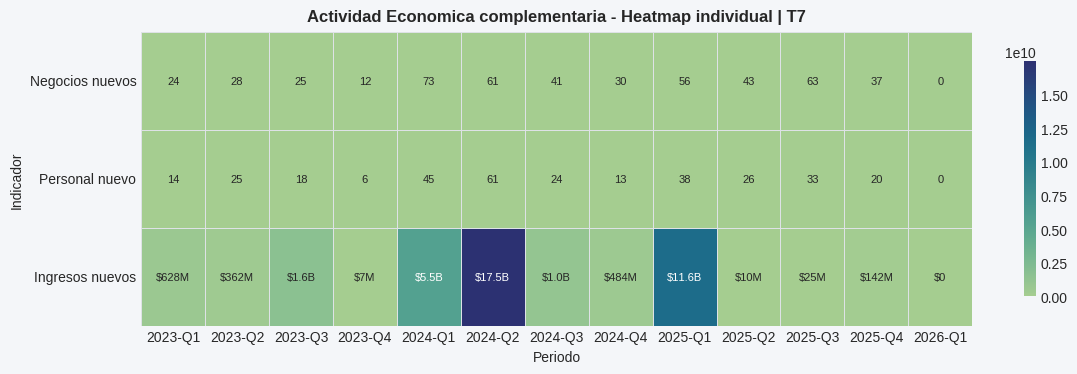

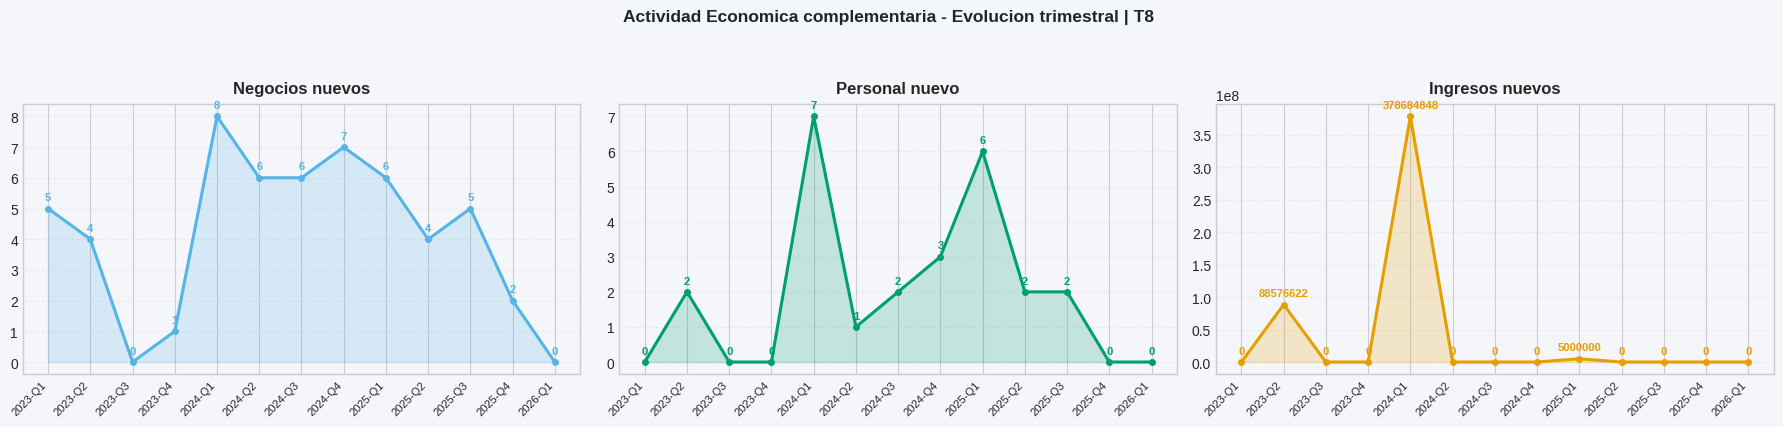

/tmp/ipykernel_33488/1599129436.py:88: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '5' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  annot.loc[label] = heat.loc[label].apply(lambda v: fmt_compacto(v, modes.get(label, 'int')))
/tmp/ipykernel_33488/1599129436.py:88: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '4' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  annot.loc[label] = heat.loc[label].apply(lambda v: fmt_compacto(v, modes.get(label, 'int')))
/tmp/ipykernel_33488/1599129436.py:88: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  annot.loc[label] = heat.loc[

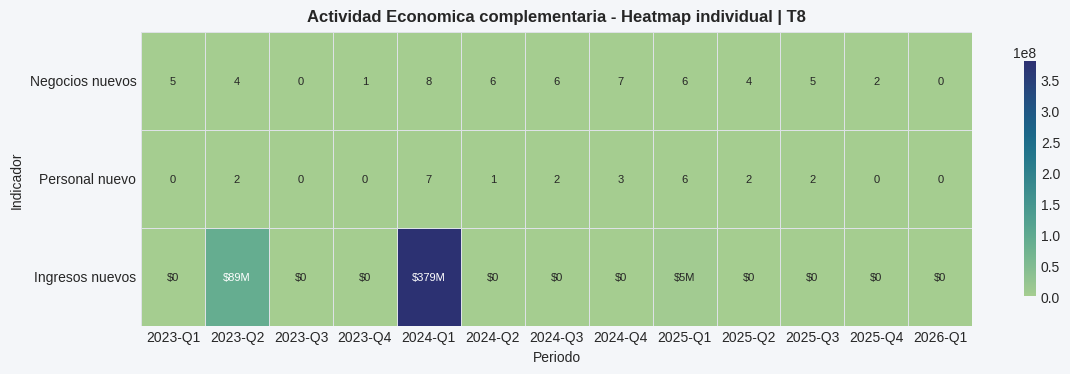

In [13]:
plot_general_annual(
    df_de_stock_ann.groupby('anio', dropna=False).agg({
        'establecimientos_activos':'sum',
        'empleabilidad_total':'sum',
        'ingresos_operacionales':'sum'
    }).reset_index(),
    [('establecimientos_activos', 'Establecimientos activos', OKI_AZUL, None),
     ('empleabilidad_total', 'Empleabilidad total', OKI_VERDE, None),
     ('ingresos_operacionales', 'Ingresos operacionales', OKI_NARANJA, 1e6)],
    'Actividad Economica oficial - Evolucion anual general | Avenida Ciudad de Cali',
    'acc_de_oficial_general_anual.png'
)

plot_heatmaps_tramo_year(
    df_de_stock_ann,
    [('establecimientos_activos', 'Establecimientos activos', CMAP_NEUTRO, 'int'),
     ('empleabilidad_total', 'Empleabilidad total', CMAP_FRIO, 'int'),
     ('ingresos_operacionales', 'Ingresos operacionales', CMAP_INTENSO, 'money')],
    'Actividad Economica oficial - Heatmap por tramo y anio | Avenida Ciudad de Cali',
    'acc_de_oficial_heatmap_tramo_anio.png'
)

for tramo in TRAMOS:
    plot_per_tramo_annual(
        df_de_stock_ann, tramo,
        [('establecimientos_activos', 'Establecimientos activos', OKI_AZUL, None),
         ('empleabilidad_total', 'Empleabilidad total', OKI_VERDE, None),
         ('ingresos_operacionales', 'Ingresos operacionales', OKI_NARANJA, 1e6)],
        'Actividad Economica oficial - Evolucion anual',
        f'acc_de_oficial_anual_{tramo}.png'
    )

plot_general_trim(
    df_de_flow_trim,
    [('negocios_nuevos', 'Creacion de negocios nuevos', OKI_AZUL_C),
     ('personal_nuevos', 'Personal de negocios nuevos', OKI_VERDE),
     ('ingresos_nuevos', 'Ingresos de negocios nuevos', OKI_NARANJA)],
    'Actividad Economica complementaria - Evolucion trimestral general | Avenida Ciudad de Cali',
    'acc_de_flujo_general_trim.png'
)

plot_heatmaps_tramo_period(
    df_de_flow_trim,
    [('negocios_nuevos', 'Negocios nuevos', CMAP_NEUTRO, 'int'),
     ('personal_nuevos', 'Personal nuevo', CMAP_FRIO, 'int'),
     ('ingresos_nuevos', 'Ingresos nuevos', CMAP_INTENSO, 'money')],
    'Actividad Economica complementaria - Heatmap por tramo y trimestre | Avenida Ciudad de Cali',
    'acc_de_flujo_heatmap_tramo_periodo.png'
)

for tramo in TRAMOS:
    plot_per_tramo_trim(
        df_de_flow_trim, tramo,
        [('negocios_nuevos', 'Negocios nuevos', OKI_AZUL_C),
         ('personal_nuevos', 'Personal nuevo', OKI_VERDE),
         ('ingresos_nuevos', 'Ingresos nuevos', OKI_NARANJA)],
        'Actividad Economica complementaria - Evolucion trimestral',
        f'acc_de_flujo_trim_{tramo}.png'
    )
    plot_per_tramo_trim_heatmap(
        df_de_flow_trim, tramo,
        [('negocios_nuevos', 'Negocios nuevos', 'int'),
         ('personal_nuevos', 'Personal nuevo', 'int'),
         ('ingresos_nuevos', 'Ingresos nuevos', 'money')],
        'Actividad Economica complementaria - Heatmap individual',
        f'acc_de_flujo_heatmap_{tramo}.png'
    )


## ITT provisional por tramo y corredor


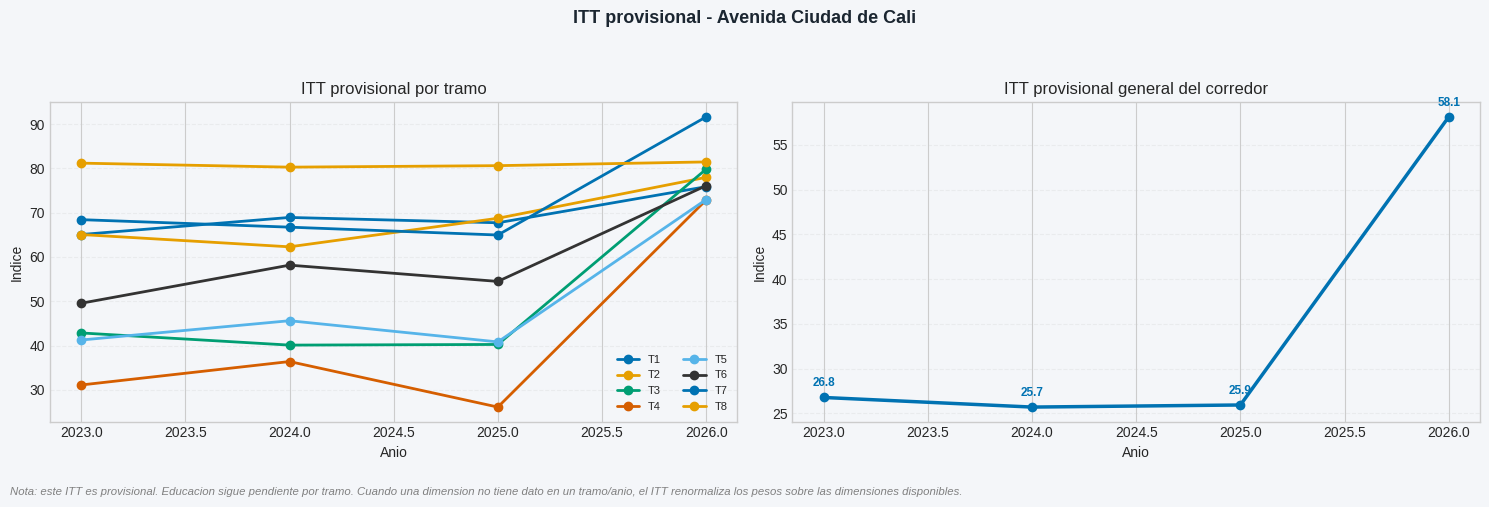

,tramo,anio,homicidios,hurtos,siniestralidad,lesionados,mortales,vif,rinas,spa,ndvi,arbolado_total,tipo_arbolado,tipo_dato,establecimientos_activos,empleabilidad_total,ingresos_operacionales,negocios_con_ingreso,ingresos_log1p,score_homicidios,score_hurtos,score_siniestralidad,score_lesionados,score_mortales,score_vif,score_rinas,score_spa,score_ndvi,score_arbolado_total,score_establecimientos_activos,score_empleabilidad_total,score_ingresos_log1p,score_seguridad,score_movilidad,score_des_social,score_entorno_u,score_des_eco,ITT,nivel,nota
0,T1,2023,1.0,82.0,23.0,18.0,1.0,15.0,7.0,22.0,0.202401,2325.0,Inventario disponible / proxy estructural,Proxy retrospectivo,40.0,55.0,2.889532e+09,8,21.784360,95.454545,67.843137,67.605634,71.428571,83.333333,80.519481,95.597484,95.491803,17.960910,39.095342,4.004004,4.833040,84.269074,81.648841,74.122513,90.536256,28.528126,31.035373,65.059116,Avance,Educacion pendiente; ITT provisional por tramo
1,T1,2024,0.0,55.0,15.0,12.0,1.0,16.0,5.0,21.0,0.207596,2325.0,Inventario disponible / proxy estructural,Proxy retrospectivo,59.0,67.0,2.903853e+09,9,21.789304,100.000000,78.431373,78.873239,80.952381,83.333333,79.220779,96.855346,95.696721,19.487888,39.095342,5.905906,5.887522,84.288199,89.215686,81.052985,90.590949,29.291615,32.027209,68.915828,Avance,Educacion pendiente; ITT provisional por tramo
2,T1,2025,2.0,49.0,10.0,9.0,1.0,13.0,26.0,56.0,0.197621,2325.0,Inventario disponible / proxy estructural,Real,79.0,74.0,2.964273e+09,11,21.809898,90.909091,80.784314,85.915493,85.714286,83.333333,83.116883,83.647799,88.524590,16.555987,39.095342,7.907908,6.502636,84.367860,85.846702,84.987704,85.096424,27.825664,32.926135,67.713508,Avance,Educacion pendiente; ITT provisional por tramo
3,T1,2026,1.0,9.0,1.0,1.0,0.0,6.0,8.0,3.0,0.211647,2325.0,Inventario disponible / proxy estructural,Proxy referencial = 2025,79.0,74.0,2.964273e+09,11,21.809898,95.454545,96.470588,98.591549,98.412698,100.000000,92.207792,94.968553,99.385246,20.678820,39.095342,7.907908,6.502636,84.367860,95.962567,99.001416,95.520531,29.887081,32.926135,75.858829,Avance,T1 parcial; Educacion pendiente; renormaliza d...
4,T2,2023,2.0,117.0,31.0,25.0,0.0,18.0,19.0,45.0,0.192815,3485.0,Inventario disponible / proxy estructural,Proxy retrospectivo,205.0,344.0,2.229239e+10,66,23.827511,90.909091,54.117647,56.338028,60.317460,100.000000,76.623377,88.050314,90.778689,15.143069,58.600975,20.520521,30.228471,92.172653,72.513369,72.218496,85.150793,36.872022,47.640548,65.059656,Avance,Educacion pendiente; ITT provisional por tramo
5,T2,2024,3.0,94.0,31.0,27.0,3.0,28.0,3.0,50.0,0.212138,3485.0,Inventario disponible / proxy estructural,Proxy retrospectivo,235.0,370.0,2.529760e+10,70,23.953975,86.363636,63.137255,56.338028,57.142857,50.000000,63.636364,98.113208,89.754098,20.823136,58.600975,23.523524,32.513181,92.661858,74.750446,54.493628,83.834557,39.712056,49.566187,62.285762,Avance,Educacion pendiente; ITT provisional por tramo
6,T2,2025,1.0,78.0,22.0,21.0,0.0,19.0,17.0,154.0,0.210396,3485.0,Inventario disponible / proxy estructural,Real,274.0,390.0,2.530910e+10,72,23.954430,95.454545,69.411765,69.014085,66.666667,100.000000,75.324675,89.308176,68.442623,20.311072,58.600975,27.427427,34.270650,92.663616,82.433155,78.560250,77.691825,39.456024,51.453898,68.727262,Avance,Educacion pendiente; ITT provisional por tramo
7,T2,2026,4.0,10.0,1.0,1.0,0.0,6.0,9.0,34.0,0.211851,3485.0,Inventario disponible / proxy estructural,Proxy referencial = 2025,274.0,390.0,2.530910e+10,72,23.954430,81.818182,96.078431,98.591549,98.412698,100.000000,92.207792,94.339623,93.032787,20.738602,58.600975,27.427427,34.270650,92.663616,88.948307,99.001416,93.193401,39.669788,51.453898,77.965049,Avance,T1 parcial; Educacion pendiente; renormaliza d...
8,T3,2023,8.0,233.0,71.0,63.0,1.0,57.0,13.0,318.0,0.144117,3992.0,Inventario disponible / proxy estructural,Proxy retrospectivo,376.0,1061.0,1.676446e+11,122,25.845112,63.636364,8.627451,0.000000,0.000000,83.333333,25.974026,91.8

,anio,homicidios,hurtos,siniestralidad,lesionados,mortales,vif,rinas,spa,ndvi,arbolado_total,establecimientos_activos,empleabilidad_total,ingresos_operacionales,ingresos_log1p,score_homicidios,score_hurtos,score_siniestralidad,score_lesionados,score_mortales,score_vif,score_rinas,score_spa,score_ndvi,score_arbolado_total,score_establecimientos_activos,score_empleabilidad_total,score_ingresos_log1p,score_seguridad,score_movilidad,score_des_social,score_entorno_u,score_des_eco,ITT,nivel
0,2023,61.0,1246.0,294.0,250.0,5.0,263.0,203.0,938.0,0.223886,23349.0,1859.0,3495.0,3.573863e+11,190.286140,0.000000,0.000000,0.000000,0.000000,16.666667,0.000000,0.000000,0.00000,24.276120,100.0,100.0,100.0,100.0,0.000000,5.555556,0.000000,62.138060,100.0,26.785692,Emergencia
1,2024,47.0,1123.0,242.0,215.0,14.0,287.0,303.0,828.0,0.229893,23349.0,2326.0,3792.0,3.877231e+11,190.919113,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,26.041904,100.0,100.0,100.0,100.0,0.000000,0.000000,0.000000,63.020952,100.0,25.713562,Emergencia
2,2025,58.0,1111.0,247.0,215.0,16.0,302.0,422.0,1237.0,0.239211,23349.0,2810.0,4080.0,4.002533e+11,191.067928,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,28.780846,100.0,100.0,100.0,100.0,0.000000,0.000000,0.000000,64.390423,100.0,25.946372,Emergencia
3,2026,15.0,155.0,31.0,26.0,2.0,62.0,70.0,127.0,0.230900,23349.0,2810.0,4080.0,4.002533e+11,191.067928,31.818182,39.215686,56.338028,58.730159,66.666667,19.480519,55.974843,73.97541,26.338037,100.0,100.0,100.0,100.0,35.516934,60.578285,49.810257,63.169019,100.0,58.119477,Consolidacion


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5), facecolor=BG)
fig.suptitle('ITT provisional - Avenida Ciudad de Cali', fontsize=13, fontweight='bold', color='#1B2631')

ax = axes[0]
for tramo in TRAMOS:
    sub = base_tramos[base_tramos['tramo'] == tramo].sort_values('anio')
    ax.plot(sub['anio'], sub['ITT'], marker='o', linewidth=2, label=tramo)
ax.set_title('ITT provisional por tramo')
ax.set_xlabel('Anio')
ax.set_ylabel('Indice')
ax.legend(ncol=2, fontsize=8, frameon=False)
ax.set_facecolor(BG)
ax.grid(axis='y', linestyle='--', alpha=0.25)

ax2 = axes[1]
ax2.plot(base_corr['anio'], base_corr['ITT'], marker='o', linewidth=2.5, color=OKI_AZUL)
for _, row in base_corr.iterrows():
    if pd.notna(row['ITT']):
        ax2.annotate(f'{row["ITT"]:.1f}', (row['anio'], row['ITT']),
                     textcoords='offset points', xytext=(0, 8), ha='center',
                     fontsize=8.5, fontweight='bold', color=OKI_AZUL)
ax2.set_title('ITT provisional general del corredor')
ax2.set_xlabel('Anio')
ax2.set_ylabel('Indice')
ax2.set_facecolor(BG)
ax2.grid(axis='y', linestyle='--', alpha=0.25)

fig.text(
    0.01, 0.01,
    'Nota: este ITT es provisional. Educacion sigue pendiente por tramo. Cuando una dimension no tiene dato en un tramo/anio, el ITT renormaliza los pesos sobre las dimensiones disponibles.',
    fontsize=8.2, color='gray', style='italic'
)

plt.tight_layout(rect=[0, 0.05, 1, 0.93])
savefig('acc_itt_provisional.png')
plt.show()

display(base_tramos.sort_values(['tramo','anio']))
display(base_corr)


In [15]:
df_inventory.to_csv(OUTPUT_DIR / 'acc_inventory_fuentes.csv', index=False)
df_seg_trim.to_csv(OUTPUT_DIR / 'acc_seg_trim_tramos.csv', index=False)
df_social_trim.to_csv(OUTPUT_DIR / 'acc_social_trim_tramos.csv', index=False)
df_mov_trim.to_csv(OUTPUT_DIR / 'acc_mov_trim_tramos.csv', index=False)
df_de_flow_trim.to_csv(OUTPUT_DIR / 'acc_de_flujo_trim_tramos.csv', index=False)
df_de_stock_ann.to_csv(OUTPUT_DIR / 'acc_de_stock_anual_tramos.csv', index=False)
df_entorno_ann.to_csv(OUTPUT_DIR / 'acc_entorno_anual_tramos.csv', index=False)
base_tramos.to_csv(OUTPUT_DIR / 'acc_itt_provisional_tramos.csv', index=False)
base_corr.to_csv(OUTPUT_DIR / 'acc_itt_provisional_corredor.csv', index=False)

print('Archivos exportados en:', OUTPUT_DIR)


Archivos exportados en: /content/itt_repos_cali/outputs/itt_avenida_ciudad_de_cali_5dim
